# Многокритериальные методы поддержки принятия решений

## Практикум: путешественник, который выбирает, как поступить

**Курс:** 4. Математические и инструментальные методы поддержки принятия решений
**Модуль:** «Агент, принимающий решения» · **Версия ноутбука:** 4.0 (основная задача; примеры вынесены в ноутбук-спутник)

---

### Для кого этот ноутбук

Для тех, кто **впервые** знакомится с методами многокритериального выбора. Заранее
ничего знать не нужно, кроме школьной математики: дробей, степеней, квадратного корня.
Всё остальное — матрица решений, нормализация, веса, собственный вектор, функция
полезности — вводится здесь по шагам.

### Как устроен ноутбук

Материалы модуля разделены на два ноутбука.

| Ноутбук | Что в нём |
|---|---|
| **Основной** — этот ноутбук | **одна задача** от начала до конца: путешественник выбирает, как дойти до горного приюта. Теория методов, формулы, код, политика для Unity, мини-симулятор |
| **Спутник** — `MCDA_Methods_Examples.ipynb` | небольшие житейские задачи (квартира, смартфон, база практики, поставщик, зарплата, кофейня, зал для конференции), решённые вручную шаг за шагом и проверенные кодом |

**Линия теории — текстовые ячейки.** Каждый метод разобран по одной схеме:

1. **Идея** — зачем метод нужен и на какой вопрос отвечает, без формул.
2. **Формулы** — строгая запись с объяснением каждого символа.
3. **Достоинства, недостатки, типичные ошибки.**
4. **Ссылка на разобранный пример** в ноутбуке-спутнике. Нумерация примеров и формул
   в обоих ноутбуках общая: пример 3.1 относится к §3, формула (5.4) — одна и та же.

Удобный порядок работы: прочитать теорию метода здесь → разобрать пример в спутнике →
вернуться сюда и посмотреть, как метод решает задачу путешественника.

**Линия практики — ячейки с кодом.** Весь код решает **одну основную задачу**:
путешественник (NPC) выбирает один из шести вариантов действий. Перед каждым блоком кода
стоит таблица «формула → код», показывающая, какая строка реализует какую часть формулы,
а после блока — объяснение, что получилось и почему.

### Оглавление

| § | Тема | Что узнаете |
|---|---|---|
| 0 | Введение в теорию принятия решений | основные понятия, матрица решений, классификация методов, постановка основной задачи |
| 1 | Предметная модель агента | состояние, альтернативы, критерии, адаптивные веса |
| 2 | Нормализация и множество Парето | как сделать критерии сравнимыми; какие альтернативы можно отбросить сразу |
| 3 | SAW и WPM | взвешенная сумма и взвешенное произведение |
| 4 | AHP — метод анализа иерархий | как получить веса из парных сравнений; согласованность суждений |
| 5 | TOPSIS | близость к идеальному решению |
| 6 | MAUT — теория многокритериальной полезности | отношение к риску, лотереи, функции полезности |
| 7 | VIKOR | компромиссное решение, «групповая полезность» и «сожаление» |
| 8 | ELECTRE I | отношение превосходства, согласие и несогласие |
| 9 | Сравнение методов | коэффициент Спирмена; почему методы расходятся |
| 10 | Анализ чувствительности | насколько решение устойчиво к изменению весов |
| 11 | От одного решения к политике | таблица «состояние → стратегия» |
| 12 | Экспорт в Unity | файл `policy_unity.json` и код на C# |
| 13 | Мини-симулятор | проверка политики до переноса в игру |
| 14 | Мост к обучению с подкреплением | ML-Agents, функция награды как свёртка критериев |
| 15 | Итоги | сводная таблица формул, глоссарий, задания, вопросы для самопроверки |

### Как запускать

Локально в **VS Code**:

1. Установите Python 3.10+ и расширения VS Code **Python** и **Jupyter**.
2. Один раз создайте окружение и поставьте библиотеки (в терминале, в папке с ноутбуком):
   ```
   python -m venv .venv
   .venv\Scripts\activate          # Windows;  на macOS/Linux: source .venv/bin/activate
   pip install -r requirements.txt
   ```
3. Откройте ноутбук, справа вверху **Select Kernel → Python Environments → .venv**.
4. Нажмите **Run All**. Ячейки выполняются сверху вниз, общее время — 1–2 минуты.

Если окружение не создавали, первая ячейка с кодом сама доустановит недостающие
библиотеки в выбранное ядро (нужен интернет). Файлы для Unity сохраняются в папку
`unity_export/` рядом с ноутбуком. Если перезапускаете ячейку из середины, сначала выполните все
ячейки выше неё: каждая следующая пользуется тем, что определено в предыдущих.

> **О записи чисел.** В тексте дробная часть отделяется запятой, как принято в русском
> языке: $0{,}25$. В коде и в выводе — точкой, как требует Python: `0.25`. Это одно и то же
> число.

---
# §0. Введение в теорию принятия решений

## 0.1. Что такое задача принятия решений

Решения мы принимаем постоянно: какую квартиру снять, какой смартфон купить, какого
поставщика выбрать, какую стратегию избрать в игре. У всех этих ситуаций общая структура.

> **Определение.** **Задача принятия решений** — это ситуация, в которой нужно выбрать
> один или несколько вариантов из заданного множества, руководствуясь некоторыми
> представлениями о том, какие варианты лучше.

В любой такой задаче есть пять элементов.

| Элемент | Обозначение | Что это | В задаче путешественника |
|---|---|---|---|
| **ЛПР** — лицо, принимающее решение | — | тот, чьи предпочтения учитываются и кто отвечает за выбор | геймдизайнер, задающий характер персонажа |
| **Альтернативы** | $A=\{a_1,\dots,a_n\}$ | варианты, из которых выбираем | шесть вариантов действий: DIRECT, SHELTERED, SURVEY, GATHER, WAIT, RETURN |
| **Критерии** | $g_1,\dots,g_m$ | признаки, по которым сравниваем варианты | продвижение, риск, время, восстановление, знание местности |
| **Оценки** | $x_{ij}=g_j(a_i)$ | значение $j$-го критерия у $i$-й альтернативы | риск пути напрямик в ненастье — 0,905 |
| **Предпочтения ЛПР** | веса $w_j$, функции полезности, пороги | что для ЛПР важнее и насколько | риск важнее времени |

Иногда выделяют ещё **эксперта** — того, кто даёт оценки $x_{ij}$, но сам не решает, —
и **аналитика**, который строит модель и применяет методы. В этом курсе вы играете роль
аналитика, а ЛПР — геймдизайнер, задающий «характер» игрового персонажа.

### Классификация задач

Задачи принятия решений различают по двум признакам.

**По информированности о последствиях:**

* **в условиях определённости** — каждой альтернативе соответствует один известный исход
  (цена квартиры известна точно);
* **в условиях риска** — исход случаен, но вероятности исходов известны
  (лотерея: с вероятностью $0{,}5$ выиграть 150 тыс., с вероятностью $0{,}5$ — 60 тыс.);
* **в условиях неопределённости** — вероятности исходов неизвестны
  (как поведёт себя конкурент).

**По числу критериев:**

* **однокритериальные** — есть одна целевая функция, и задача сводится к оптимизации
  (найти минимум затрат) — это линейное программирование из раздела 2 курса;
* **многокритериальные** — критериев несколько, и они **противоречат друг другу**.

Этот ноутбук посвящён второму случаю. По-английски такие методы называют
**MCDA** (Multi-Criteria Decision Analysis) или **MCDM** (Multi-Criteria Decision Making).
Если альтернатив конечное число и их можно перечислить — говорят о задаче
**многоатрибутного выбора** (MADM); именно ею мы и занимаемся.

### Главная трудность многокритериального выбора

Если бы одна квартира была одновременно самой дешёвой, самой большой и самой близкой
к работе, выбирать было бы нечего. Трудность возникает, потому что **критерии конфликтуют**:
дешёвая квартира обычно маленькая или далеко. Математика не может сказать, что важнее —
10 минут дороги или 5 квадратных метров. Это знает только ЛПР.

Поэтому любой метод многокритериального выбора делает две вещи:

1. **Отсеивает заведомо плохие варианты** — те, для которых есть вариант лучше во всём
   (об этом — §2, множество Парето). Здесь предпочтения ЛПР не нужны.
2. **Выбирает среди оставшихся**, используя дополнительную информацию о предпочтениях:
   веса, функции полезности, пороги. Методы различаются именно тем, **какую** информацию
   они просят у ЛПР и **как** её используют.

## 0.2. Матрица решений

Все исходные данные многокритериальной задачи удобно записать одной таблицей.

> **Определение.** **Матрица решений** $X=[x_{ij}]$ размера $n\times m$ — таблица, в которой
> строки соответствуют альтернативам $a_1,\dots,a_n$, столбцы — критериям $g_1,\dots,g_m$,
> а на пересечении стоит оценка $x_{ij}=g_j(a_i)$.

$$
X=\begin{pmatrix}
x_{11} & x_{12} & \cdots & x_{1m}\\
x_{21} & x_{22} & \cdots & x_{2m}\\
\vdots & \vdots & \ddots & \vdots\\
x_{n1} & x_{n2} & \cdots & x_{nm}
\end{pmatrix}
\qquad
\begin{aligned}
&i=1,\dots,n \;\text{— номер альтернативы (строки)}\\
&j=1,\dots,m \;\text{— номер критерия (столбца)}
\end{aligned}
$$

В основной задаче матрица решений имеет размер $6\times 5$: шесть вариантов действий
путешественника (строки) и пять критериев (столбцы). Она строится в §1.3 и, в отличие от
учебных примеров, **меняется вместе с ситуацией**.

> Учебная матрица с пятью квартирами, на которой разобраны нормализация и множество Парето,
> вынесена в ноутбук-спутник `MCDA_Methods_Examples.ipynb`, §0.

### Направление критерия

Обратите внимание: у критериев разное **направление**.

* **Критерий-выгода** (benefit, «max») — чем больше, тем лучше: продвижение к приюту,
  восстановление, знание местности.
* **Критерий-издержка** (cost, «min») — чем меньше, тем лучше: риск неприятностей, затраты времени.

Смешивать их напрямую нельзя: если просто сложить продвижение и риск, путь напрямик
в ненастье получит высокий балл сразу по двум причинам, хотя высокий риск — недостаток.
Поэтому первый шаг почти любого метода — привести все критерии к одному направлению
(обычно «больше — лучше»). Это делает **нормализация** (§2.1).

### Шкалы измерения

Критерии измеряются в разных **шкалах**, и от шкалы зависит, какие действия с числами
допустимы.

| Шкала | Что можно утверждать | Пример | Можно ли складывать и умножать? |
|---|---|---|---|
| Номинальная | только «равно / не равно» | район города | нет |
| Порядковая | «больше / меньше» | рейтинг «плохо — средне — хорошо» | нет, только сравнивать |
| Интервальная | разности имеют смысл | температура в °C, баллы 0–10 | разности — да, отношения — нет |
| Отношений | отношения имеют смысл, есть абсолютный ноль | цена, площадь, время | да |

Методы, которые мы изучим, требуют **количественных** оценок (интервальная шкала или
шкала отношений). Если критерий качественный («хорошо — плохо»), его сначала переводят
в баллы — и тем самым вносят в модель дополнительное допущение.

> **Типичная ошибка.** Складывать рубли с квадратными метрами. Сумма «45 тыс. руб. + 38 м²»
> бессмысленна: результат зависит от выбора единиц (перейдите на рубли — и цена задавит всё).
> Нормализация переводит каждый критерий в безразмерную шкалу $[0,1]$, и только после
> неё оценки становятся сравнимыми.

## 0.3. Общая схема многокритериального выбора

Какой бы метод мы ни применяли, решение проходит одни и те же этапы.

1. **Сформулировать цель** и определить ЛПР.
2. **Составить множество альтернатив** $A$.
3. **Выбрать критерии** $g_1,\dots,g_m$ и их направления. Хороший набор критериев
   *полон* (учитывает всё важное), *неизбыточен* (критерии не дублируют друг друга)
   и *измерим*.
4. **Заполнить матрицу решений** $X$.
5. **Отсеять доминируемые альтернативы** (множество Парето, §2.2).
6. **Выяснить предпочтения ЛПР**: веса (§4), функции полезности (§6), пороги (§8).
7. **Применить метод агрегирования** и получить ранжирование или выбор.
8. **Проверить устойчивость** результата (§9–10) и при необходимости вернуться к шагу 6.

### Карта методов этого ноутбука

Методы различаются тем, **как** они объединяют оценки по разным критериям в итоговое суждение.

| Метод | Основная идея | Что выдаёт | Компенсация* | § |
|---|---|---|---|---|
| **Парето** | отбросить то, что хуже во всём | множество недоминируемых | не требуется | 2.2 |
| **SAW** | взвешенная сумма оценок | балл и ранжирование | полная | 3.1 |
| **WPM** | взвешенное произведение оценок | балл и ранжирование | частичная | 3.2 |
| **AHP** | веса из попарных сравнений «во сколько раз важнее» | веса и приоритеты | полная | 4 |
| **TOPSIS** | ближе к идеалу, дальше от антиидеала | балл в $[0,1]$ | полная | 5 |
| **MAUT** | сумма полезностей, учёт отношения к риску | полезность | полная | 6 |
| **VIKOR** | компромисс между «суммарной потерей» и «худшим провалом» | ранжирование и компромиссное множество | ограниченная | 7 |
| **ELECTRE I** | «a не хуже b», если большинство за и нет сильного вето | граф превосходства, ядро | ограниченная | 8 |

\* **Компенсация** — может ли высокая оценка по одному критерию возместить низкую
по другому. При **полной** компенсации очень дешёвая, но крошечная квартира может
победить благодаря цене. При **ограниченной** — сильный провал хотя бы по одному
критерию блокирует альтернативу, как бы хороша она ни была по остальным.

Методы делятся на три большие семьи:

* **методы скалярной свёртки и полезности** (SAW, WPM, AHP, MAUT) — сводят всё к одному числу;
* **методы расстояния до идеала** (TOPSIS, VIKOR) — оценивают, насколько альтернатива
  далека от воображаемого «идеального» варианта;
* **методы превосходства** (ELECTRE, PROMETHEE) — сравнивают альтернативы попарно и строят
  отношение «не хуже», которое может оставить часть вариантов **несравнимыми**.

## 0.4. Основная задача ноутбука: путешественник выбирает, как поступить

Теперь — задача, которую решает весь код ноутбука.

**Сюжет.** В двумерной игре о пеших походах есть персонаж-путешественник (NPC,
non-player character — персонаж, которым управляет программа, а не игрок). Его цель —
**дойти до горного приюта до наступления темноты**, по пути пополняя запасы воды и еды,
изучая местность и не выбиваясь из сил. Погода в горах переменчива: то ясно, то дождь
с ветром. На пути встречаются укрытия — навесы, лесные участки, скальные ниши.

**Почему это задача многокритериального выбора.** В каждый момент у путешественника есть
шесть вариантов действий — это **альтернативы**. Каждый вариант хорош в одном и плох
в другом: идти напрямик быстро, но в непогоду тяжело; переждать под навесом спокойно,
но к приюту это не приближает. Значит, варианты нужно сравнивать по нескольким
**критериям**, которые противоречат друг другу.

**Чем она отличается от учебных примеров.** В учебных задачах ноутбука-спутника (квартира,
смартфон, поставщик) матрица решений одна.
У путешественника обстановка меняется: силы убывают, погода портится, вода заканчивается.
Поэтому матрица решений **зависит от ситуации** $s$, и её нужно пересчитывать заново
в каждый момент. В одной ситуации лучше идти напрямик, в другой — переждать. Набор ответов
«в такой ситуации — такое действие» называется **политикой** персонажа.

**Формализация:**

| Элемент | Обозначение | Содержание |
|---|---|---|
| Ситуация | $s=(e,d,q,u,h)$ | силы, расстояние до приюта, сила непогоды, запас воды и еды, доступность укрытий; каждое число в $[0,1]$ |
| Альтернативы | $A$, $\lvert A\rvert=6$ | DIRECT, SHELTERED, SURVEY, GATHER, WAIT, RETURN |
| Критерии | $g_1,\dots,g_5$ | progress (max), risk (min), time (min), supply (max), info (max) |
| Матрица решений | $X(s)=[x_{ij}]$ | $x_{ij}=g_j(a_i,s)$, размер $6\times 5$ |
| Веса | $w(s)$ | базовые веса ЛПР, скорректированные ситуацией |
| Политика | $\pi(s)=\arg\max_i F(x_i,w)$ | $F$ — агрегирующая функция выбранного метода |

Запись $\arg\max_i F$ читается «тот номер $i$, при котором $F$ максимальна», то есть
**какая** альтернатива лучшая (а не **насколько** хорош лучший балл).

**Что получится в конце.** Перебрав все 243 различимые ситуации, мы получим таблицу
политики. Она сохраняется в файл `policy_unity.json`, который загружается в игровой движок
Unity, и персонаж начинает вести себя по нашей модели. На последнем шаге ту же задачу
решит нейросеть, обученная методом обучения с подкреплением, и мы сравним два подхода.

> **Методический смысл.** «Разумность» персонажа — это не магия нейросети, а явная модель
> предпочтений: набор критериев и весов. Меняя веса, вы меняете характер путешественника —
> осторожный, торопливый, хозяйственный — и можете точно объяснить, почему он поступил
> так, а не иначе.

### От формулы к коду: словарь обозначений

Прежде чем читать код, сверьтесь с этой таблицей: в ней каждый символ из формул
и его имя в Python. Нумерация в формулах начинается с единицы ($a_1,\dots,a_n$),
в Python — с нуля; но почти везде мы обращаемся к элементам по **именам**
(`"DIRECT"`, `"risk"`), поэтому сдвиг индексов не мешает.

| Символ | Смысл | В коде | Тип и форма |
|---|---|---|---|
| $s$ | ситуация (состояние среды) | `s`, `s_demo` | словарь из 5 чисел |
| $a_i$ | альтернатива (вариант действий) | элемент `STRATEGIES` | строка, например `"WAIT"` |
| $g_j$ | критерий | элемент `CRITERIA` | строка, например `"risk"` |
| $g_j(a_i,s)$ | функция оценивания | `EVALUATORS[a](s)[c]` | число в $[0,1]$ |
| $X(s)$ | матрица решений | `X`, `X_demo` | `DataFrame` формы (6, 5) |
| $r_{ij}$ | нормализованная оценка | `R`, `R_demo` | `DataFrame` формы (6, 5) |
| $w_j$ | вес критерия | `w`, `w_demo`, `W_BASE` | `Series` из 5 чисел, сумма 1 |
| $F(a_i)$ | итоговый балл альтернативы | результат `saw`, `topsis`, … | `Series` длины 6 |
| $\pi(s)$ | политика: ситуация → вариант действий | `policy["strategy"]` | 243 строки |
| $\nu$ | вес стратегии большинства в VIKOR | `nu` | число |
| $c_j$ | коэффициент отношения к риску в MAUT | `RISK_ATTITUDE[c]` | число |
| $\hat c,\;\hat d$ | пороги согласия и несогласия ELECTRE | `c_thr`, `d_thr` | числа |

`DataFrame` — таблица библиотеки pandas с подписанными строками и столбцами: к элементу
можно обратиться как `X.loc["WAIT", "risk"]`. `Series` — один подписанный столбец.

**Если вы впервые видите Python.** В коде встретятся несколько базовых конструкций; все они
объяснены в комментариях при первом появлении, а здесь — краткая памятка:

| Запись | Что означает |
|---|---|
| `x = 5` | присвоить переменной `x` значение 5 |
| `# текст` | комментарий: Python его пропускает |
| `[1, 2, 3]` | список — упорядоченный набор значений |
| `{"a": 1, "b": 2}` | словарь — пары «ключ: значение»; `d["a"]` даёт 1 |
| `(1, 2)` | кортеж — неизменяемый набор значений |
| `def f(x): ... return y` | объявить функцию `f`, которая по `x` возвращает `y` |
| `for x in список:` | цикл: выполнить блок для каждого элемента |
| `if условие: ... else: ...` | ветвление: выполнить один из двух блоков |
| `f"итог: {x}"` | f-строка: значение `x` подставится в текст |
| `[f(x) for x in список]` | генератор списка: применить `f` к каждому элементу |
| отступ в 4 пробела | показывает, какие строки входят в функцию, цикл или условие |

In [1]:
# =============================================================================
# §0. НАСТРОЙКА ОКРУЖЕНИЯ
# -----------------------------------------------------------------------------
# Эта ячейка подключает библиотеки и задаёт внешний вид таблиц и графиков.
# Её нужно выполнить ПЕРВОЙ: все остальные ячейки пользуются тем, что здесь
# подключено. Если каких-то библиотек нет, ячейка установит их сама.
#
# Как читать код новичку:
#   * всё, что стоит после знака #, — это КОММЕНТАРИЙ. Python его не выполняет,
#     он написан только для человека;
#   * команда import подключает БИБЛИОТЕКУ — готовый набор функций, написанный
#     другими программистами, чтобы нам не пришлось писать всё с нуля.
# =============================================================================

# --- Стандартная библиотека Python (устанавливать ничего не нужно) ------------
import json          # чтение и запись файлов JSON — текстового формата, в котором
                     # мы передадим готовую политику в игровой движок Unity
import math          # элементарные математические функции (корни, логарифмы)
import itertools     # инструменты перебора; понадобится, чтобы перебрать
                     # все 3^5 = 243 возможные ситуации
import datetime      # работа с датой и временем: запишем в файл, когда он создан

# «from X import Y» означает: из библиотеки X взять только инструмент Y.
from dataclasses import dataclass, field   # компактное описание «записей»
                                           # (набора полей с именами)
from typing import Callable, Dict, List, Tuple
# typing — это «подсказки типов». Они не влияют на работу программы, а только
# сообщают читателю, что ожидается: Dict — словарь, List — список,
# Tuple — кортеж (неизменяемый список), Callable — функция.

# --- Проверка, что нужные библиотеки установлены ------------------------------
# importlib.util.find_spec ищет библиотеку, не подключая её. Если чего-то нет,
# ставим через pip ИМЕННО в тот Python, на котором работает ядро ноутбука
# (sys.executable), — иначе пакет может попасть в другое окружение.
import sys
import importlib.util
import subprocess

_REQUIRED = {"numpy": "numpy", "pandas": "pandas", "matplotlib": "matplotlib"}
_missing = [pkg for mod, pkg in _REQUIRED.items() if importlib.util.find_spec(mod) is None]
if _missing:
    print("Устанавливаю:", ", ".join(_missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *_missing])

# display(...) показывает таблицу красиво из середины ячейки. В Jupyter она
# доступна и так, но явный импорт не даёт ошибки в других средах.
from IPython.display import display

# --- Научные библиотеки -------------------------------------------------------
# «import X as Y» подключает библиотеку X и даёт ей короткое имя Y.
# Сокращения np, pd, plt — общепринятые, их используют во всём мире.
import numpy as np          # NumPy: быстрые вычисления с массивами чисел
                            # и линейная алгебра (собственные векторы для AHP)
import pandas as pd         # pandas: таблицы с подписанными строками и
                            # столбцами — матрица решений удобнее всего так
import matplotlib           # matplotlib: построение графиков
import matplotlib.pyplot as plt   # pyplot — самая используемая часть matplotlib
# Показывать графики прямо в ноутбуке, под ячейкой (в VS Code и Jupyter).
%matplotlib inline

# --- Как печатать числа -------------------------------------------------------
# np.set_printoptions — функция, которая меняет формат печати массивов NumPy.
# Аргументы передаются «по имени»: имя=значение.
#   precision=4       — четыре знака после точки;
#   suppress=True     — не переходить на запись вида 1.2e-05;
#   floatmode="fixed" — всегда ровно 4 знака: 9.0000, а не «9.».
np.set_printoptions(precision=4, suppress=True, floatmode="fixed")
pd.set_option("display.precision", 4)      # то же для таблиц pandas
pd.set_option("display.width", 140)        # широкие таблицы не переносятся

# --- Единый стиль графиков ----------------------------------------------------
# plt.rcParams — это СЛОВАРЬ настроек (пары «ключ: значение» в фигурных
# скобках). Метод .update({...}) меняет сразу несколько настроек.
plt.rcParams.update({
    "figure.figsize": (9, 5),   # размер рисунка в дюймах: ширина, высота
    "figure.dpi": 110,          # чёткость (точек на дюйм)
    "axes.grid": True,          # сетка помогает считывать значения
    "grid.alpha": 0.25,         # прозрачность сетки: 0 — невидима, 1 — сплошная
    "font.size": 11,            # размер шрифта подписей
})

# --- Генератор случайных чисел ------------------------------------------------
# Случайность понадобится в анализе чувствительности (§10). Число 42 —
# «зерно» генератора: при одном и том же зерне получаются одни и те же
# «случайные» числа. Поэтому результаты у всей группы совпадут.
# Знак = означает ПРИСВАИВАНИЕ: переменная RNG теперь хранит генератор.
RNG = np.random.default_rng(42)

# ВАЖНО про запись чисел: в тексте ноутбука дробная часть отделяется запятой
# (0,25), как принято в русском языке, а в коде и в его выводе — точкой (0.25),
# как требует Python. Это одно и то же число.

# print(...) выводит текст на экран. Несколько значений через запятую
# печатаются через пробел. __version__ — номер версии библиотеки.
print("numpy", np.__version__, "| pandas", pd.__version__,
      "| matplotlib", matplotlib.__version__)

numpy 2.4.4 | pandas 3.0.2 | matplotlib 3.10.9


Если ячейка напечатала версии библиотек — окружение готово. Версии могут отличаться
от тех, что у преподавателя: код совместим с NumPy 1.x и 2.x, pandas 2.x и 3.x.

---
# §1. Предметная модель агента

Прежде чем применять методы, нужно построить **модель**: перевести игровую ситуацию на язык
альтернатив, критериев и оценок. Это самый ответственный этап: никакой метод не исправит
модель, в которой забыт важный критерий или неверно оценены альтернативы.

## 1.1. Переменные состояния

Ситуацию, в которой находится путешественник, описывают пять чисел, каждое нормировано на отрезок $[0,1]$:

| Переменная | Смысл | 0 означает | 1 означает |
|---|---|---|---|
| `energy` ($e$) | силы путешественника | совсем устал | полон сил |
| `dist` ($d$) | расстояние до приюта | приют рядом | приют максимально далеко |
| `weather` ($q$) | сила непогоды | ясно и тихо | сильный дождь с ветром |
| `supplies` ($u$) | запас воды и еды | фляга и рюкзак пусты | полный запас |
| `shelter` ($h$) | доступность укрытий вокруг | открытый склон | много навесов, лес, скальные ниши |

**Зачем дискретизация.** Непрерывных состояний бесконечно много, а таблица политики должна
быть конечной. Поэтому каждое число огрубляем до одного из трёх уровней: «низкий»,
«средний», «высокий». Каждый уровень представлен одним числом, например для сил —
$0{,}25$, $0{,}60$ и $0{,}95$. Всего получается

$$
3\times 3\times 3\times 3\times 3 = 3^5 = 243 \;\text{различимых состояния}.
$$

Каждое состояние получает строковый **ключ** из пяти индексов уровней через вертикальную
черту. Например, `0|2|2|0|1` означает: сил мало (0), приют далеко (2), непогода
сильная (2), запасов мало (0), укрытий средне (1). По этому ключу Unity будет искать
нужную строку таблицы.

> **Почему три уровня, а не десять.** При десяти уровнях состояний было бы $10^5=100\,000$ —
> такую таблицу невозможно проверить глазами, а большая часть её строк никогда не
> встретится в игре. Три уровня — компромисс между точностью и обозримостью.

In [2]:
# =============================================================================
# §1.1. ПЕРЕМЕННЫЕ СОСТОЯНИЯ И ИХ ДИСКРЕТИЗАЦИЯ
# -----------------------------------------------------------------------------
# Ситуация, в которой находится путешественник, описывается пятью числами
# из отрезка [0, 1]. Чтобы из бесконечного множества ситуаций получить
# конечную таблицу, каждое число «огрубляется» до одного из трёх уровней:
# низкий, средний, высокий. Получаем 3 · 3 · 3 · 3 · 3 = 3^5 = 243 ситуации.
# =============================================================================

# СПИСОК (list) — упорядоченный набор значений в квадратных скобках.
# Порядок важен: именно в этом порядке переменные стоят в ключе ситуации
# "energy|dist|weather|supplies|shelter", и так же их читает Unity.
STATE_VARS = ["energy", "dist", "weather", "supplies", "shelter"]

# СЛОВАРЬ (dict) — набор пар «ключ: значение» в фигурных скобках.
# По ключу можно быстро найти значение: STATE_LABELS["energy"] даст
# строку "Силы путешественника".
STATE_LABELS = {
    "energy":   "Силы путешественника",
    "dist":     "Расстояние до приюта",
    "weather":  "Сила непогоды",
    "supplies": "Запас воды и еды",
    "shelter":  "Доступность укрытий",
}

# Числовые значения уровней: индекс уровня (0, 1, 2) -> число в [0, 1].
# Значение словаря здесь — это список из трёх чисел. Нумерация элементов
# списка в Python начинается с НУЛЯ: STATE_BINS["energy"][0] равно 0.25.
STATE_BINS = {
    "energy":   [0.25, 0.60, 0.95],   # 0 = устал,  1 = средне, 2 = бодр
    "dist":     [0.20, 0.50, 0.85],   # 0 = близко, 1 = средне, 2 = далеко
    "weather":  [0.10, 0.50, 0.90],   # 0 = ясно,   1 = переменно, 2 = ненастье
    "supplies": [0.20, 0.60, 1.00],   # 0 = мало,   1 = средне, 2 = полный запас
    "shelter":  [0.20, 0.50, 0.80],   # 0 = открытая местность, 2 = много навесов
}

# Словесные названия уровней — для подписей на картах политики (§11).
BIN_NAMES = {
    "energy":   ["мало", "средне", "много"],
    "dist":     ["близко", "средне", "далеко"],
    "weather":  ["ясно", "переменно", "ненастье"],
    "supplies": ["мало", "средне", "полный"],
    "shelter":  ["открыто", "средне", "много"],
}


# --- Функции ------------------------------------------------------------------
# «def имя(параметры):» объявляет ФУНКЦИЮ — именованный кусок кода, который
# можно вызывать много раз. Строки внутри функции пишутся с отступом
# в 4 пробела. Слово return возвращает результат тому, кто функцию вызвал.
# Запись «-> Dict[str, float]» — подсказка: функция вернёт словарь,
# где ключи — строки (str), а значения — дробные числа (float).
# Текст в тройных кавычках сразу после def — «докстринг», описание функции.

def make_state(energy, dist, weather, supplies, shelter) -> Dict[str, float]:
    """Ситуация из пяти чисел в [0, 1] — в виде словаря.

    Словарь удобнее списка: s["weather"] читается понятнее, чем s[2].
    """
    # dict(a=1, b=2) — ещё один способ создать словарь {"a": 1, "b": 2}.
    return dict(energy=energy, dist=dist, weather=weather,
                supplies=supplies, shelter=shelter)


def state_from_bins(idx: Tuple[int, ...]) -> Dict[str, float]:
    """Ситуация из кортежа индексов уровней, например (0, 2, 2, 0, 1).

    zip(A, B) «склеивает» два списка попарно: ("energy", 0), ("dist", 2), ...
    Запись {k: v for ... in ...} — «генератор словаря»: короткий способ
    построить словарь в одну строку, пройдя циклом по парам.
    """
    return {v: STATE_BINS[v][i] for v, i in zip(STATE_VARS, idx)}


def state_key(idx: Tuple[int, ...]) -> str:
    """Строковый ключ ситуации '0|2|2|0|1' — по нему Unity найдёт запись.

    str(i) превращает число в текст; "|".join([...]) склеивает список
    строк, вставляя между ними символ |.
    """
    return "|".join(str(i) for i in idx)


def describe_state(idx: Tuple[int, ...]) -> str:
    """Словесное описание ситуации для печати.

    f"..." — «f-строка»: выражения в фигурных скобках внутри неё
    вычисляются и подставляются в текст.
    """
    return ", ".join(f"{STATE_LABELS[v]}: {BIN_NAMES[v][i]}"
                     for v, i in zip(STATE_VARS, idx))


# --- Проверка --------------------------------------------------------------------
# Возьмём одну ситуацию: путешественник устал, до приюта далеко, ненастье,
# запасов мало, укрытий средне. ** — возведение в степень: 3 ** 5 = 243.
# len(список) — длина списка (здесь 5).
print("Всего различимых ситуаций:", 3 ** len(STATE_VARS))
print("Пример:", state_key((0, 2, 2, 0, 1)), "→", describe_state((0, 2, 2, 0, 1)))
print("Числовые значения:", state_from_bins((0, 2, 2, 0, 1)))

Всего различимых ситуаций: 243
Пример: 0|2|2|0|1 → Силы путешественника: мало, Расстояние до приюта: далеко, Сила непогоды: ненастье, Запас воды и еды: мало, Доступность укрытий: средне
Числовые значения: {'energy': 0.25, 'dist': 0.85, 'weather': 0.9, 'supplies': 0.2, 'shelter': 0.5}


Ячейка подтвердила: состояний 243, а ключ `0|2|2|0|1` расшифровывается в числа
$e=0{,}25$, $d=0{,}85$, $q=0{,}9$, $u=0{,}2$, $h=0{,}5$ — это и есть значения, которые
подставляются в функции оценивания.

## 1.2. Альтернативы: варианты действий

Шесть вариантов действий подобраны так, чтобы в большинстве ситуаций **ни одна не была лучше всех
во всём**. Если бы, скажем, защищённая тропа всегда была и безопаснее, и быстрее пути напрямик,
путь напрямик никогда бы не выбирался, и задача выбора выродилась бы.

Каждый вариант — это «сильная сторона» по одному-двум критериям:

* **DIRECT** (идти напрямик) — максимальное продвижение ценой высокого риска в непогоду;
* **SHELTERED** (идти защищённой тропой) — продвижение с меньшим риском, но медленнее;
* **SURVEY** (осмотреться) — максимум знаний о местности: где родник, где короткая тропа;
* **GATHER** (пополнить запасы) — набрать воды у родника, собрать ягоды и орехи;
* **WAIT** (переждать) — отдохнуть под навесом, пока непогода не утихнет;
* **RETURN** (вернуться) — минимальный риск ценой отдаления от приюта.

In [3]:
# =============================================================================
# §1.2. АЛЬТЕРНАТИВЫ: ВАРИАНТЫ ДЕЙСТВИЙ ПУТЕШЕСТВЕННИКА
# -----------------------------------------------------------------------------
# В терминах теории принятия решений это множество альтернатив A.
# Порядок в списке STRATEGIES фиксирован: в этом же порядке баллы вариантов
# записываются в файл для Unity, и игра сопоставляет их по номеру.
# Коды написаны латиницей заглавными буквами — так принято называть
# постоянные значения, которые в программе не меняются.
# =============================================================================

STRATEGIES = ["DIRECT", "SHELTERED", "SURVEY", "GATHER", "WAIT", "RETURN"]

# pd.DataFrame(...) создаёт ТАБЛИЦУ. Здесь мы передаём список КОРТЕЖЕЙ:
# каждый кортеж в круглых скобках — одна строка таблицы из трёх значений.
# columns=[...] задаёт названия столбцов.
# .set_index("Код") делает столбец «Код» подписями строк (индексом).
STRATEGY_INFO = pd.DataFrame([
    ("DIRECT",    "Напрямик",            "Идти к приюту кратчайшей дорогой быстрым шагом"),
    ("SHELTERED", "Защищённой тропой",   "Идти к приюту лесом и под навесами — медленнее, но спокойнее"),
    ("SURVEY",    "Осмотреться",         "Подняться на смотровую точку, свериться с картой"),
    ("GATHER",    "Пополнить запасы",    "Набрать воды у родника, пополнить провизию"),
    ("WAIT",      "Переждать",           "Остановиться в укрытии, отдохнуть, переждать непогоду"),
    ("RETURN",    "Вернуться",           "Вернуться к предыдущей стоянке, где тепло и сухо"),
], columns=["Код", "Название", "Описание"]).set_index("Код")

# Если последняя строка ячейки — просто имя переменной (без print),
# Jupyter сам красиво покажет её значение. Так удобно смотреть таблицы.
STRATEGY_INFO

,Название,Описание
Код,,
DIRECT,Напрямик,Идти к приюту кратчайшей дорогой быстрым шагом
SHELTERED,Защищённой тропой,Идти к приюту лесом и под навесами — медленнее...
SURVEY,Осмотреться,"Подняться на смотровую точку, свериться с картой"
GATHER,Пополнить запасы,"Набрать воды у родника, пополнить провизию"
WAIT,Переждать,"Остановиться в укрытии, отдохнуть, переждать н..."
RETURN,Вернуться,"Вернуться к предыдущей стоянке, где тепло и сухо"


## 1.3. Критерии и функции оценивания

Каждый вариант действий оцениваем по пяти критериям.

| Критерий | Смысл | Направление |
|---|---|---|
| `progress` | насколько вариант приближает к приюту за один шаг | max |
| `risk` | вероятность неприятностей: промокнуть, поскользнуться, выбиться из сил | min |
| `time` | сколько времени займёт выполнение | min |
| `supply` | насколько пополнятся запасы воды и еды и восстановятся силы | max |
| `info` | сколько нового путешественник узнает о местности | max |

**Откуда берутся оценки.** В задаче о квартире оценки просто известны (цену написали
в объявлении). У путешественника оценка **зависит от ситуации**: идти напрямик в ненастье
опаснее, чем в ясную погоду. Поэтому каждая оценка задана формулой — **функцией оценивания**
$g_j(a,s)$ от варианта действий и ситуации. Все функции линейные или почти линейные — их легко
прочитать и изменить.

**Как читать формулы на примере пути напрямик (DIRECT):**

$$
g_{\text{risk}}(\text{DIRECT},s)=0{,}06+0{,}80\,q+0{,}30\,(1-e)-0{,}12\,h+0{,}10\,(1-u).
$$

* $0{,}06$ — минимальный риск, даже когда всё спокойно;
* $0{,}80\,q$ — главный вклад: риск пути напрямик почти пропорционален силе непогоды;
* $0{,}30\,(1-e)$ — уставший путешественник чаще оступается (при $e=1$ слагаемое равно нулю);
* $-0{,}12\,h$ — укрытия по пути немного помогают даже на прямой дороге;
* $0{,}10\,(1-u)$ — без воды и еды идти тяжелее и опаснее.

Результат обрезается до $[0,1]$ функцией `clip01`.

**Множитель запасов.** Продвижение у DIRECT и SHELTERED умножается на

$$
\text{supplies\_factor}(u)=0{,}10+0{,}90\,u^{1{,}4},
$$

который при пустом запасе ($u=0$) равен $0{,}10$, а при полном ($u=1$) — единице. Смысл: голодный и мучимый жаждой путник далеко не уйдёт. Без этого множителя
путешественнику никогда не было бы выгодно пополнять запасы (GATHER): модель была бы **вырожденной**.
Это типичная ситуация: качество многокритериальной модели определяется не столько
методом свёртки, сколько адекватностью функций оценивания.

> **Попробуйте.** Все коэффициенты — «экспертные», их можно менять. Уменьшите $0{,}80$
> в риске пути напрямик до $0{,}40$ и посмотрите в §11, как станет вести себя путешественник.

In [4]:
# =============================================================================
# §1.3. КРИТЕРИИ И ФУНКЦИИ ОЦЕНИВАНИЯ g_j(a, s)
# -----------------------------------------------------------------------------
# Для каждого варианта действий a и ситуации s нужно получить пять чисел —
# оценки по пяти критериям. Вместе они образуют строку матрицы решений X(s).
# Все оценки лежат в [0, 1]; направление (max или min) задано отдельно.
# =============================================================================

CRITERIA = ["progress", "risk", "time", "supply", "info"]

# Направление оптимизации каждого критерия:
#   "max" — критерий-«выгода»: чем больше значение, тем лучше;
#   "min" — критерий-«издержка»: чем меньше значение, тем лучше.
DIRECTIONS = {"progress": "max", "risk": "min", "time": "min",
              "supply": "max", "info": "max"}

CRIT_LABELS = {
    "progress": "Продвижение к приюту",
    "risk":     "Риск неприятностей",
    "time":     "Затраты времени",
    "supply":   "Восстановление",
    "info":     "Знание местности",
}


def clip01(x: float) -> float:
    """Обрезка числа до отрезка [0, 1].

    max(0.0, x) заменит отрицательное число нулём, min(1.0, ...) заменит
    число больше единицы единицей. float(...) превращает результат
    в обычное дробное число Python.
    Формулы ниже — суммы с коэффициентами; при крайних ситуациях они могли бы
    выйти за [0, 1], и обрезка это исправляет.
    """
    return float(min(1.0, max(0.0, x)))


def supplies_factor(supplies: float) -> float:
    """Множитель запасов: 0.10 + 0.90 · supplies^1.4.

    Без воды и еды далеко не уйдёшь: при пустом запасе (supplies = 0)
    множитель равен 0.10, при полном (supplies = 1) — 1.0.
    Степень 1.4 (оператор **) делает зависимость выпуклой: первые
    единицы запаса дают мало, последние — много.
    Без этого множителя вариант GATHER никогда бы не выигрывал.
    """
    return 0.10 + 0.90 * supplies ** 1.4


# --- Функции оценивания: по одной на вариант действий --------------------------
# Каждая функция получает ситуацию s (словарь из пяти чисел) и возвращает
# словарь оценок по пяти критериям. Обращение s["weather"] достаёт из
# словаря значение по ключу "weather". Коэффициенты подобраны «экспертно»:
# их смысл объяснён в текстовой ячейке выше, их можно и нужно менять.
# Подчёркивание в начале имени (_direct) — договорённость программистов:
# «вспомогательная функция, напрямую её не вызывают».

def _direct(s):
    """НАПРЯМИК: быстро приближает к приюту, но в непогоду тяжело."""
    return dict(
        # Продвижение почти максимальное, но зависит от запасов воды и еды.
        progress = clip01(0.95 * supplies_factor(s["supplies"])),
        # Риск неприятностей растёт с непогодой (главный вклад 0.80), с
        # усталостью (1 - energy) и с нехваткой запасов; укрытия по пути
        # немного помогают (минус 0.12 · shelter).
        risk     = clip01(0.06 + 0.80 * s["weather"] + 0.30 * (1 - s["energy"])
                          - 0.12 * s["shelter"] + 0.10 * (1 - s["supplies"])),
        # Время пропорционально оставшемуся расстоянию.
        time     = clip01(0.08 + 0.50 * s["dist"]),
        # На ходу силы и запасы не восстанавливаются.
        supply   = clip01(0.05),
        # По пути кое-что увидим — тем больше, чем длиннее путь.
        info     = clip01(0.12 + 0.10 * s["dist"]),
    )


def _sheltered(s):
    """ЗАЩИЩЁННОЙ ТРОПОЙ: медленнее, но непогода почти не мешает."""
    return dict(
        # Чем больше укрытий на тропе, тем увереннее продвижение.
        progress = clip01((0.45 + 0.30 * s["shelter"]) * supplies_factor(s["supplies"])),
        # Непогода мешает только там, где укрыться негде: множитель (1 - shelter).
        risk     = clip01(0.05 + 0.50 * s["weather"] * (1 - s["shelter"])
                          + 0.12 * (1 - s["energy"])),
        # Медленно: базовые 0.40 плюс зависимость от расстояния.
        time     = clip01(0.40 + 0.50 * s["dist"] + 0.10 * s["shelter"]),
        supply   = clip01(0.15),
        info     = clip01(0.28 + 0.15 * s["shelter"]),
    )


def _survey(s):
    """ОСМОТРЕТЬСЯ: почти не приближает к приюту, зато даёт максимум знаний."""
    return dict(
        progress = clip01(0.12),
        risk     = clip01(0.08 + 0.45 * s["weather"] - 0.18 * s["shelter"]),
        time     = clip01(0.42),
        supply   = clip01(0.25),
        # Главное достоинство: по знанию местности этот вариант лучший.
        info     = clip01(0.85 + 0.10 * s["dist"]),
    )


def _gather(s):
    """ПОПОЛНИТЬ ЗАПАСЫ: лучший вариант по восстановлению."""
    return dict(
        progress = clip01(0.05),
        risk     = clip01(0.10 + 0.50 * s["weather"] - 0.12 * s["shelter"]),
        # Чем меньше запасов, тем дольше придётся их пополнять.
        time     = clip01(0.50 + 0.15 * (1 - s["supplies"])),
        supply   = clip01(0.92),
        info     = clip01(0.32 + 0.10 * s["dist"]),
    )


def _wait(s):
    """ПЕРЕЖДАТЬ: отдыхаем в укрытии, восстанавливаем силы."""
    return dict(
        progress = clip01(0.03),
        # (1 - shelter) ** 1.6: под надёжным навесом риск падает очень быстро.
        # Слагаемое 0.10 · weather^2: в сильное ненастье и под навесом
        # бывает неуютно — ожидание не бывает совсем без неприятностей.
        risk     = clip01(0.05 + 0.45 * s["weather"] * (1 - s["shelter"]) ** 1.6
                          + 0.10 * s["weather"] ** 2),
        time     = clip01(0.55),
        supply   = clip01(0.62),
        info     = clip01(0.20 + 0.12 * s["shelter"]),
    )


def _return(s):
    """ВЕРНУТЬСЯ: самый спокойный вариант, но он отдаляет от приюта."""
    return dict(
        progress = clip01(0.01),
        risk     = clip01(0.03 + 0.16 * s["weather"]),
        time     = clip01(0.28 + 0.20 * s["dist"]),
        supply   = clip01(0.45),
        info     = clip01(0.06),
    )


# Словарь «код варианта -> функция оценивания». В Python функцию можно
# положить в словарь, как любое значение, а потом вызвать:
# EVALUATORS["DIRECT"](s) — то же самое, что _direct(s).
EVALUATORS: Dict[str, Callable] = {
    "DIRECT": _direct, "SHELTERED": _sheltered, "SURVEY": _survey,
    "GATHER": _gather, "WAIT": _wait, "RETURN": _return,
}


def decision_matrix(s: Dict[str, float]) -> pd.DataFrame:
    """Матрица решений X(s): строки — варианты, столбцы — критерии.

    Элемент x_ij = g_j(a_i, s) — оценка i-го варианта по j-му критерию.
    """
    # Генератор словаря: для каждого кода a из STRATEGIES вызываем его
    # функцию оценивания. Получаем словарь словарей.
    rows = {a: EVALUATORS[a](s) for a in STRATEGIES}
    # pd.DataFrame(rows) кладёт варианты в СТОЛБЦЫ, поэтому транспонируем
    # таблицу (.T — поменять строки и столбцы местами), а [CRITERIA]
    # фиксирует порядок столбцов.
    return pd.DataFrame(rows).T[CRITERIA]


# --- Демонстрационная ситуация ----------------------------------------------------
# С ней мы пройдём все методы §2–§9: одна и та же матрица, разные способы
# выбрать из неё лучшую строку.
s_demo = make_state(energy=0.35, dist=0.85, weather=0.80, supplies=0.30, shelter=0.50)
X_demo = decision_matrix(s_demo)
print("Ситуация: путешественник устал, до приюта далеко, ненастье, мало запасов\n")
# .round(3) округляет все числа таблицы до трёх знаков — только для показа.
X_demo.round(3)

Ситуация: путешественник устал, до приюта далеко, ненастье, мало запасов



,progress,risk,time,supply,info
DIRECT,0.253,0.905,0.505,0.05,0.205
SHELTERED,0.160,0.328,0.875,0.15,0.355
SURVEY,0.120,0.350,0.420,0.25,0.935
GATHER,0.050,0.440,0.605,0.92,0.405
WAIT,0.030,0.233,0.550,0.62,0.260
RETURN,0.010,0.158,0.450,0.45,0.060


### Что показывает матрица решений

Перед нами матрица $X(s_{\text{demo}})$ размера $6\times 5$ для ситуации «путешественник устал,
приют далеко, сильная непогода, мало воды и еды». Посмотрите на неё как ЛПР.

* **DIRECT** лучший по продвижению ($0{,}253$), но и самый рискованный ($0{,}905$ — в такую
  непогоду почти наверняка промокнет и выбьется из сил). Продвижение невелико, потому что
  воды и еды мало: сработал множитель запасов.
* **RETURN** самый безопасный ($0{,}158$), но почти не продвигает ($0{,}010$) и ничего
  не даёт по знанию местности.
* **GATHER** лучший по восстановлению ($0{,}92$), **SURVEY** — по информации ($0{,}935$),
  **WAIT** — второй по безопасности и неплох по восстановлению.

**Ни одна строка не лучше всех остальных во всех столбцах.** Это классическая ситуация
многокритериального выбора, и дальше мы увидим, как её разрешают разные методы.

## 1.4. Веса критериев и их адаптация к состоянию

**Вес** $w_j$ показывает относительную важность $j$-го критерия для ЛПР. Веса неотрицательны
и в сумме дают единицу:

$$
w_j\ge 0,\qquad \sum_{j=1}^{m} w_j = 1.
$$

Условие «сумма равна 1» позволяет читать вес как **долю**: вес $0{,}30$ у продвижения
означает, что на этот критерий приходится 30 % «внимания» ЛПР.

Откуда берутся веса? Простейший способ — назначить их прямо («на глаз»). Более строгий —
метод анализа иерархий (§4), где веса вычисляются из попарных сравнений. Базовые веса
$w^0$ задают **характер** путешественника: осторожный, торопливый, хозяйственный.

**Контекстная рациональность.** Живой человек в критической ситуации меняет приоритеты:
когда сил мало, резко растёт важность безопасности, вблизи приюта — важность
продвижения. Моделируем это так:

$$
w_j(s)=\frac{w_j^0\cdot m_j(s)}{\sum_{k=1}^{m} w_k^0\cdot m_k(s)}, \qquad\qquad (1.1)
$$

где $m_j(s)\ge 1$ — **модификатор** критерия, зависящий от состояния. Числитель усиливает
нужные критерии, знаменатель возвращает сумму весов к единице.

**Ручной расчёт для демонстрационного состояния** ($e=0{,}35$, $d=0{,}85$, $q=0{,}8$,
$u=0{,}3$, $h=0{,}5$). Модификаторы:

| Критерий | Формула модификатора | $m_j$ | $w_j^0$ | $w_j^0\,m_j$ | $w_j(s)$ |
|---|---|--:|--:|--:|--:|
| progress | $1+1{,}2\,(1-d)$ | 1,180 | 0,30 | 0,3540 | 0,173 |
| risk | $1+2{,}4\,(1-e)+0{,}7\,q$ | 3,120 | 0,26 | 0,8112 | 0,397 |
| time | $1+0{,}6\,d$ | 1,510 | 0,14 | 0,2114 | 0,103 |
| supply | $1+1{,}8\,(1-u)+1{,}6\,(1-e)$ | 3,300 | 0,15 | 0,4950 | 0,242 |
| info | $1+0{,}9\,d\,(1-q)$ | 1,153 | 0,15 | 0,1730 | 0,085 |
| **сумма** | | | **1,00** | **2,0446** | **1,000** |

Например, для риска: $m=1+2{,}4\cdot 0{,}65+0{,}7\cdot 0{,}8=1+1{,}56+0{,}56=3{,}12$;
$w_{\text{risk}}(s)=0{,}8112/2{,}0446\approx 0{,}397$. Вес риска вырос с $0{,}26$ до
$0{,}397$ — уставший путешественник стал заметно осторожнее. Следующая ячейка делает этот расчёт в коде.

In [5]:
# =============================================================================
# §1.4. БАЗОВЫЕ ВЕСА И ИХ АДАПТАЦИЯ К СИТУАЦИИ
# -----------------------------------------------------------------------------
# Вес w_j показывает, насколько ЛПР важен j-й критерий. Веса неотрицательны
# и в сумме дают 1. Базовые веса w⁰ задают «характер» путешественника;
# модификаторы m_j(s) усиливают критерии в зависимости от ситуации:
#
#            w_j(s) = w⁰_j · m_j(s) / Σ_k w⁰_k · m_k(s)          (формула 1.1)
#
# Деление на сумму возвращает веса к условию Σ w_j = 1.
# =============================================================================

# pd.Series — «подписанный столбец»: набор чисел, у каждого из которых
# есть имя (здесь — название критерия). Создаём его из словаря.
W_BASE = pd.Series({
    "progress": 0.30,   # дойти до приюта — главная задача
    "risk":     0.26,   # но и избежать неприятностей важно почти так же
    "time":     0.14,
    "supply":   0.15,
    "info":     0.15,
})
# Делим каждое число на сумму всех чисел. У Series деление применяется
# сразу ко всем элементам. Это страховка: сумма весов строго равна 1.
W_BASE = W_BASE / W_BASE.sum()


def adaptive_weights(s: Dict[str, float], w0: pd.Series = W_BASE,
                     enabled: bool = True) -> pd.Series:
    """Веса критериев, скорректированные ситуацией (формула 1.1).

    Параметры со знаком = в заголовке (w0=W_BASE, enabled=True) имеют
    ЗНАЧЕНИЯ ПО УМОЛЧАНИЮ: если их не передать, возьмутся эти.
    enabled=False отключает адаптацию: удобно, чтобы сравнить «жёсткого»
    и «гибкого» путешественника.
    """
    # if ... : — УСЛОВИЕ. Если enabled равно False, «not enabled» истинно,
    # и функция сразу возвращает копию базовых весов.
    if not enabled:
        return w0.copy()
    # Модификаторы m_j(s) >= 1: они только усиливают критерии, никогда
    # не обнуляют. Коэффициенты (2.40, 1.20 ...) — сила реакции на ситуацию.
    m = pd.Series({
        # чем меньше сил и сильнее непогода — тем важнее не рисковать
        "risk":     1.0 + 2.40 * (1 - s["energy"]) + 0.70 * s["weather"],
        # чем ближе приют — тем важнее продвижение («последний рывок»)
        "progress": 1.0 + 1.20 * (1 - s["dist"]),
        # время дорожает, когда до приюта далеко
        "time":     1.0 + 0.60 * s["dist"],
        # восстановление критично при малых запасах и малых силах
        "supply":   1.0 + 1.80 * (1 - s["supplies"]) + 1.60 * (1 - s["energy"]),
        # осмотреться полезно, когда путь длинный и погода позволяет
        "info":     1.0 + 0.90 * s["dist"] * (1 - s["weather"]),
    })
    # m[w0.index] выстраивает модификаторы в том же порядке, что веса,
    # и Series перемножаются поэлементно: числитель формулы (1.1).
    w = w0 * m[w0.index]
    return w / w.sum()            # знаменатель: нормировка к сумме 1


# Сравним базовые и адаптивные веса в демонстрационной ситуации.
w_demo = adaptive_weights(s_demo)
# Таблица из двух столбцов: ключи словаря станут названиями столбцов.
comp = pd.DataFrame({"базовые w⁰": W_BASE, "адаптивные w(s)": w_demo})
# Новый столбец можно добавить, просто присвоив его: comp["Δ"] = ...
comp["Δ"] = comp["адаптивные w(s)"] - comp["базовые w⁰"]   # на сколько сдвинулся
# Заменяем служебные имена критериев на русские подписи. Запись
# [CRIT_LABELS[c] for c in comp.index] — «генератор списка»: для каждого
# c из comp.index берём CRIT_LABELS[c] и собираем результаты в список.
comp.index = [CRIT_LABELS[c] for c in comp.index]
comp.round(3)

,базовые w⁰,адаптивные w(s),Δ
Продвижение к приюту,0.30,0.173,-0.127
Риск неприятностей,0.26,0.397,0.137
Затраты времени,0.14,0.103,-0.037
Восстановление,0.15,0.242,0.092
Знание местности,0.15,0.085,-0.065


Код дал те же числа, что и ручной расчёт выше: риск $0{,}26\to 0{,}397$, восстановление
$0{,}15\to 0{,}242$, продвижение $0{,}30\to 0{,}173$. В этой ситуации путешественник думает прежде
всего о том, как не выбиться из сил и восстановиться, а не о том, как быстрее дойти до приюта.
Именно веса $w(s)$ мы будем подавать во все методы §3–§9.

---
# §2. Нормализация и множество Парето

## 2.1. Нормализация

### Идея

Критерии измеряются в разных единицах (рубли, метры, минуты, баллы) и имеют разное
направление (цену хотим уменьшить, площадь — увеличить). **Нормализация** переводит
каждый столбец матрицы решений в безразмерную шкалу — обычно отрезок $[0,1]$ —
и заодно разворачивает все критерии в одну сторону: «больше — лучше».

Результат — **нормализованная матрица** $R=[r_{ij}]$ той же формы, что $X$.

### Формулы

Пусть $x_j^{\max}=\max_i x_{ij}$ и $x_j^{\min}=\min_i x_{ij}$ — наибольшее и наименьшее
значения в $j$-м столбце.

**1. Линейная нормализация по размаху (min–max):**

$$
r_{ij}=\frac{x_{ij}-x_j^{\min}}{x_j^{\max}-x_j^{\min}}\;\;\text{(выгода)},
\qquad
r_{ij}=\frac{x_j^{\max}-x_{ij}}{x_j^{\max}-x_j^{\min}}\;\;\text{(издержка)}. \qquad (2.1)
$$

Лучшее значение в столбце превращается в $1$, худшее — в $0$, остальные ложатся
пропорционально между ними.

**2. Нормализация по лучшему значению (линейная, «доля от лучшего»):**

$$
r_{ij}=\frac{x_{ij}}{x_j^{\max}}\;\;\text{(выгода)},
\qquad
r_{ij}=\frac{x_j^{\min}}{x_{ij}}\;\;\text{(издержка)}. \qquad (2.2)
$$

Лучшее значение превращается в $1$, остальные — в долю от лучшего. Худшее, как правило,
**не** равно нулю.

**3. Векторная нормализация:**

$$
r_{ij}=\frac{x_{ij}}{\sqrt{\sum_{k=1}^{n}x_{kj}^{2}}}. \qquad (2.3)
$$

Каждый столбец делится на свою евклидову длину, и сумма квадратов в столбце становится
равной единице. Для издержки в этом ноутбуке берётся $1-r_{ij}$ («отражение»); почему
это допустимо — объяснено в §5.

### Сравнение схем

| Свойство | min–max (2.1) | по лучшему (2.2) | векторная (2.3) |
|---|---|---|---|
| Диапазон результата | ровно $[0,1]$ | $(0,1]$ | внутри $(0,1)$ |
| Лучшее значение | $1$ | $1$ | меньше $1$ |
| Худшее значение | $0$ | больше $0$ | больше $0$ |
| Сохраняет отношения «во сколько раз» | нет | да (для выгод) | да |
| Где используется | SAW, VIKOR, ELECTRE, MAUT | WPM, SAW | TOPSIS |

> **Типичная ошибка 1.** Использовать min–max перед WPM. Худшее значение превращается в $0$,
> а ноль в произведении обнуляет **всю** оценку альтернативы, как бы хороша она ни была
> по остальным критериям. Для WPM нужна схема (2.2).
>
> **Типичная ошибка 2.** Забыть развернуть издержку. Если применить формулу для выгоды
> к цене, самая дорогая квартира получит $r=1$, и метод будет искать самое дорогое жильё.

> **Особенность min–max.** Результат зависит от **всего набора** альтернатив: добавили
> новый вариант с рекордно низкой ценой — изменились все $r_{ij}$ в столбце цены. Иногда
> это даже меняет порядок уже имевшихся альтернатив (явление «смены рангов», rank reversal).

> **Разобранный пример** с ручным решением и проверкой кодом — в ноутбуке-спутнике
> `MCDA_Methods_Examples.ipynb`, пример 2.1.

### Реализация в основной задаче

Функция `normalize` реализует все три схемы. Параметр `directions` позволяет применить её
к любой матрице — так она решает учебные задачи в ноутбуке-спутнике.

**Таблица 2.1. Нормализация min–max (2.1): формула → код.**

| Формула | Python |
|---|---|
| $x_j^{\max},\;x_j^{\min}$ | `hi, lo = x.max(), x.min()` — наибольшее и наименьшее значение **в столбце** $j$ |
| проверка направления | `benefit = directions[c] == "max"` — выгода или издержка |
| $\dfrac{x_{ij}-x_j^{\min}}{x_j^{\max}-x_j^{\min}}$ | `(x - lo) / rng` — выгода: худшее → 0, лучшее → 1 |
| $\dfrac{x_j^{\max}-x_{ij}}{x_j^{\max}-x_j^{\min}}$ | `(hi - x) / rng` — издержка: направление развёрнуто |
| $x_j^{\max}=x_j^{\min}$ | `np.full_like(x, 0.5)` — граничный случай: критерий не различает альтернатив, делить на ноль нельзя |
| вся формула для столбца | `R[c] = np.clip(r, 0.0, 1.0)` — результат записан в столбец `c` таблицы `R` |

**Таблица 2.2. Нормализация по лучшему (2.2): формула → код.**

| Формула | Python |
|---|---|
| $x_{ij}/x_j^{\max}$ | `x / hi` — выгода: доля от лучшего |
| $x_j^{\min}/x_{ij}$ | `lo / np.maximum(x, 1e-12)` — издержка; `np.maximum` защищает от деления на ноль |
| $x_{ij}=0$ для издержки | `np.where(x > 1e-12, ..., 1.0)` — нулевая издержка идеальна, её оценка 1 |
| вся формула | `r = x / hi if benefit else lo / x` (с защитами выше) |

Операции вида `x - lo` выполняются **сразу для всего столбца**: `x` — массив NumPy,
и вычитание числа из массива вычитает его из каждого элемента.

In [6]:
# =============================================================================
# §2.1. НОРМАЛИЗАЦИЯ МАТРИЦЫ РЕШЕНИЙ
# -----------------------------------------------------------------------------
# Три схемы из текстовой ячейки выше (формулы 2.1–2.3). После любой из них
# все критерии измеряются в одной шкале [0, 1] и имеют одно направление:
# «больше — лучше». Это нужно всем методам, которые складывают или
# перемножают оценки по разным критериям.
# =============================================================================

def normalize(X: pd.DataFrame, method: str = "minmax",
              directions: Dict[str, str] = None) -> pd.DataFrame:
    """Нормализованная матрица R: все столбцы в [0, 1], «больше — лучше».

    X          — матрица решений (строки — альтернативы, столбцы — критерии);
    method     — "minmax" (2.1), "linear" (2.2) или "vector" (2.3);
    directions — словарь {критерий: "max" | "min"}. Если не передан,
                 используются направления основной задачи (DIRECTIONS).
                 Передайте свой словарь, чтобы нормализовать чужую матрицу,
                 например из учебного примера.
    """
    # None в Python означает «ничего, значение не задано».
    # «is None» — проверка, что аргумент не передали.
    if directions is None:
        directions = DIRECTIONS

    # Пустая таблица той же формы, что X: те же подписи строк (index) и
    # столбцов (columns); dtype=float — внутри будут дробные числа.
    R = pd.DataFrame(index=X.index, columns=X.columns, dtype=float)

    # ЦИКЛ for: переменная c по очереди принимает каждое имя столбца.
    for c in X.columns:
        # X[c] — столбец c; .astype(float) — перевести в дробные числа;
        # .values — взять «голый» массив NumPy без подписей.
        x = X[c].astype(float).values
        # Можно присвоить две переменные сразу: hi получит максимум,
        # lo — минимум столбца (x_j^max и x_j^min в формулах).
        hi, lo = x.max(), x.min()
        # == — проверка на равенство (не путать с присваиванием =).
        # benefit будет True для «выгоды» и False для «издержки».
        benefit = directions[c] == "max"

        if method == "minmax":
            # (2.1): худшее значение -> 0, лучшее -> 1.
            rng = hi - lo                          # размах столбца
            if rng < 1e-12:                        # 1e-12 = 0.000000000001
                # Все альтернативы равны по критерию: он ничего не различает.
                # Ставим всем 0.5, чтобы не делить на ноль.
                # np.full_like(x, 0.5) — массив той же длины, что x, из 0.5.
                r = np.full_like(x, 0.5)
            elif benefit:                          # elif = «иначе, если»
                r = (x - lo) / rng                 # выгода: (x - min)/(max - min)
            else:                                  # else = «во всех прочих случаях»
                r = (hi - x) / rng                 # издержка: (max - x)/(max - min)
            # Обратите внимание: x - lo вычитает число из КАЖДОГО элемента
            # массива сразу, без цикла. Так работают массивы NumPy.

        elif method == "linear":
            # (2.2): доля от лучшего значения; худшее НЕ обязательно 0.
            if benefit:
                # «A if условие else B» — однострочное условие:
                # если hi > 0, берём x / hi, иначе массив из 0.5.
                r = x / hi if hi > 1e-12 else np.full_like(x, 0.5)
            else:
                # min / x. np.where(условие, A, B) поэлементно выбирает
                # A там, где условие истинно, и B там, где ложно.
                # Нулевая издержка идеальна — её оценка 1.
                # np.maximum не даёт делить на точный ноль.
                r = np.where(x > 1e-12, lo / np.maximum(x, 1e-12), 1.0)

        elif method == "vector":
            # (2.3): делим на евклидову длину столбца sqrt(Σ x_i^2).
            nrm = np.sqrt((x ** 2).sum())
            v = x / nrm if nrm > 1e-12 else np.full_like(x, 0.5)
            # Для издержки «отражаем»: 1 - v. Отражение сохраняет расстояния
            # между альтернативами, поэтому TOPSIS даёт тот же ответ, что и
            # в классическом варианте (см. §5).
            r = v if benefit else 1.0 - v

        else:
            # raise — «выбросить ошибку»: программа остановится с сообщением.
            # Так мы защищаемся от опечатки в названии метода.
            raise ValueError(f"Неизвестный метод нормализации: {method}")

        # np.clip(r, 0, 1) обрезает значения до отрезка [0, 1] — страховка
        # от погрешностей округления. Результат записываем в столбец c.
        R[c] = np.clip(r, 0.0, 1.0)
    return R


# Нормализуем демонстрационную матрицу X_demo из §1.3.
R_demo = normalize(X_demo, "minmax")
print("Нормализованная матрица (minmax), все критерии приведены к "
      "'больше — лучше':\n")      # \n внутри строки — перевод строки
R_demo.round(3)

Нормализованная матрица (minmax), все критерии приведены к 'больше — лучше':



,progress,risk,time,supply,info
DIRECT,1.000,0.000,0.813,0.000,0.166
SHELTERED,0.616,0.772,0.000,0.115,0.337
SURVEY,0.452,0.743,1.000,0.230,1.000
GATHER,0.164,0.622,0.593,1.000,0.394
WAIT,0.082,0.900,0.714,0.655,0.229
RETURN,0.000,1.000,0.934,0.460,0.000


### Что получилось

Каждый столбец теперь в $[0,1]$, и везде «больше — лучше». Посмотрите на столбец `risk`:
у DIRECT стоит $0$ (самый рискованный), у RETURN — $1$ (самый безопасный). Для исходных
данных было наоборот: риск DIRECT $0{,}905$, риск RETURN $0{,}158$. Формула для издержки
развернула шкалу.

Обратите внимание и на столбец `progress`: RETURN получил $0$, DIRECT — $1$. Min–max
всегда отдаёт крайние значения $0$ и $1$ лучшему и худшему, даже если реальная разница
между ними невелика.

## 2.2. Доминирование и множество Парето

### Идея

Прежде чем спрашивать ЛПР о весах, можно отбросить варианты, которые **заведомо хуже**
какого-то другого. Если одна квартира дороже, меньше **и** дальше от работы, чем другая, то
никакой разумный человек её не выберет — независимо от того, что для него важнее.
Этот принцип носит имя итальянского экономиста Вильфредо Парето.

### Определения

> **Определение (доминирование).** Альтернатива $a$ **доминирует** альтернативу $b$
> (пишут $a\succ b$), если $a$ не хуже $b$ по **всем** критериям и строго лучше хотя бы
> по **одному**:
>
> $$ a\succ b \iff \begin{cases} r_j(a)\ge r_j(b) & \text{для всех } j=1,\dots,m,\\ r_k(a)\gt r_k(b) & \text{хотя бы для одного } k. \end{cases} \qquad (2.4) $$
>
> Здесь $r_j$ — нормализованные оценки, у которых «больше — лучше».

> **Определение (Парето-оптимальность).** Альтернатива называется **Парето-оптимальной**
> (эффективной, недоминируемой), если её не доминирует ни одна другая альтернатива.
> Множество всех таких альтернатив называется **множеством Парето**.

### Свойства

1. **Не требует предпочтений ЛПР.** Ни весов, ни порогов — только матрица решений.
   Поэтому отсев по Парето бесспорен.
2. **Обычно не даёт единственного ответа.** В множестве Парето остаются все
   «компромиссные» варианты, и выбрать среди них без дополнительной информации нельзя.
3. **Любой разумный метод выбирает из множества Парето.** Если метод предлагает
   доминируемую альтернативу, в нём ошибка — это удобная самопроверка.
4. **Отношение доминирования неполное.** Две альтернативы могут быть **несравнимы**:
   каждая лучше другой в чём-то своём. Именно несравнимые варианты и составляют
   множество Парето.

> **Типичная ошибка.** Считать, что «Парето-оптимальный» значит «хороший». Квартира,
> самая дешёвая из всех, но в 20 м² и в двух часах от работы, может быть Парето-оптимальной
> (никто не дешевле), но никто не захочет в ней жить. Парето только отсекает заведомо
> худшее, а не выбирает лучшее.

> **Разобранный пример** с ручным решением и проверкой кодом — в ноутбуке-спутнике
> `MCDA_Methods_Examples.ipynb`, пример 2.2.

### Реализация в основной задаче

**Таблица 2.3. Доминирование (2.4): формула → код.**

| Формула | Python |
|---|---|
| $r_j(a)$, $r_j(b)$ | `u`, `v` — строки нормализованной матрицы; для всех критериев «больше — лучше» |
| $r_j(a)\ge r_j(b)$ для всех $j$ | `np.all(u >= v - 1e-12)` — «не хуже по всем»; допуск гасит ошибки округления |
| $r_k(a)\gt r_k(b)$ хотя бы для одного $k$ | `np.any(u > v + 1e-12)` — «строго лучше хотя бы по одному» |
| «и» между условиями | `... and ...` — оба условия обязательны |
| вся формула: $a\succ b$ | `dominates(u, v)` |

**Таблица 2.4. Множество Парето: определение → код.**

| Определение | Python |
|---|---|
| перебрать все альтернативы $a_i$ | `for i, name in enumerate(names)` |
| «существует $a_j$, доминирующая $a_i$» | `any(dominates(R[j], R[i]) for j ... if j != i)` |
| $a_i$ Парето-оптимальна, если такой нет | `if not dominated: front.append(name)` |

Функция `any(...)` возвращает `True`, как только нашёлся хотя бы один доминирующий
вариант, — это прямой перевод квантора «существует».

In [7]:
# =============================================================================
# §2.2. ДОМИНИРОВАНИЕ И МНОЖЕСТВО ПАРЕТО
# -----------------------------------------------------------------------------
# Реализуем определение (2.4): a доминирует b, если a не хуже b по всем
# критериям и строго лучше хотя бы по одному. Сравнивать удобно после
# нормализации — тогда по всем столбцам «больше значит лучше».
# =============================================================================

def dominates(u: np.ndarray, v: np.ndarray) -> bool:
    """True, если строка u доминирует строку v (обе нормализованы).

    u >= v сравнивает массивы поэлементно и даёт массив из True/False.
    np.all(...) — True, если ВСЕ элементы True: «не хуже по всем критериям».
    np.any(...) — True, если ХОТЯ БЫ ОДИН True: «строго лучше хотя бы по одному».
    and — логическое «и»: нужны оба условия.
    Допуск 1e-12 защищает от ошибок округления: 0.30000000000000004 и 0.3
    для нас одно и то же число.
    """
    return bool(np.all(u >= v - 1e-12) and np.any(u > v + 1e-12))


def pareto_front(X: pd.DataFrame, directions: Dict[str, str] = None) -> List[str]:
    """Имена Парето-оптимальных альтернатив — тех, кого никто не доминирует."""
    R = normalize(X, "minmax", directions).values   # массив формы (n, m)
    names = list(X.index)                  # list(...) — превратить в список
    front = []                             # пустой список: сюда будем добавлять
    # enumerate(names) выдаёт пары (номер, имя): (0, "DIRECT"), (1, "SHELTERED")...
    for i, name in enumerate(names):
        # R[i] — i-я строка массива. range(len(names)) — числа 0, 1, ..., n-1.
        # any(... for j in ...) — True, если нашлась хотя бы одна
        # альтернатива j (не сама i), которая доминирует i.
        dominated = any(dominates(R[j], R[i])
                        for j in range(len(names)) if j != i)   # != — «не равно»
        if not dominated:
            front.append(name)             # .append — добавить в конец списка
    return front


def dominance_matrix(X: pd.DataFrame, directions: Dict[str, str] = None) -> pd.DataFrame:
    """Таблица n × n: 1 в клетке (a, b), если a доминирует b."""
    R = normalize(X, "minmax", directions).values
    n = len(X)                             # число альтернатив
    # Таблица из нулей с подписями строк и столбцов — именами альтернатив.
    D = pd.DataFrame(0, index=X.index, columns=X.index)
    for i in range(n):          # строка — «кто доминирует»
        for j in range(n):      # столбец — «кого доминируют» (вложенный цикл)
            if i != j and dominates(R[i], R[j]):
                # .iloc[i, j] — обращение к клетке по НОМЕРАМ строки и столбца.
                D.iloc[i, j] = 1
    return D


PF_demo = pareto_front(X_demo)
print("Парето-оптимальные варианты в демо-ситуации:", PF_demo)
# Генератор списка с условием: берём a из STRATEGIES, только если a
# не входит (not in) в множество Парето.
print("Отброшены как доминируемые:", [a for a in STRATEGIES if a not in PF_demo])
print("\nМатрица доминирования (1 = строка доминирует столбец):")
dominance_matrix(X_demo)

Парето-оптимальные варианты в демо-ситуации: ['DIRECT', 'SHELTERED', 'SURVEY', 'GATHER', 'WAIT', 'RETURN']
Отброшены как доминируемые: []

Матрица доминирования (1 = строка доминирует столбец):


,DIRECT,SHELTERED,SURVEY,GATHER,WAIT,RETURN
DIRECT,0,0,0,0,0,0
SHELTERED,0,0,0,0,0,0
SURVEY,0,0,0,0,0,0
GATHER,0,0,0,0,0,0
WAIT,0,0,0,0,0,0
RETURN,0,0,0,0,0,0


### Что получилось

В демонстрационном состоянии **все шесть стратегий Парето-оптимальны**, матрица
доминирования целиком из нулей. Каждая стратегия в чём-то лучше каждой другой:
DIRECT — по продвижению, RETURN — по риску, GATHER — по восстановлению, SURVEY — по информации
и времени, WAIT и SHELTERED — по сочетанию.

Это хорошая новость для учебной модели: задача выбора **не тривиальна**. Но всегда ли так?
Следующая ячейка проверяет все 243 состояния.

In [8]:
# =============================================================================
# Насколько часто доминирование встречается во всех 243 ситуациях?
# -----------------------------------------------------------------------------
# Если бы в большинстве ситуаций один вариант доминировал все остальные,
# задача выбора была бы тривиальной и методы MCDA не понадобились бы.
# Проверим это перебором.
# =============================================================================

sizes = []        # размер множества Парето в каждой ситуации
example = None    # первая найденная ситуация, где есть доминирование

# itertools.product(range(3), repeat=5) перебирает все наборы из пяти
# индексов 0..2: (0,0,0,0,0), (0,0,0,0,1), ..., (2,2,2,2,2) — всего 243.
for idx in itertools.product(range(3), repeat=len(STATE_VARS)):
    s = state_from_bins(idx)                   # числа ситуации
    pf = pareto_front(decision_matrix(s))      # множество Парето для неё
    sizes.append(len(pf))                      # запоминаем его размер
    # Запоминаем первый пример, где Парето-множество меньше шести.
    if example is None and len(pf) < len(STRATEGIES):
        example = (idx, pf)                    # кортеж из двух значений

# np.mean(список) — среднее арифметическое. {...:.2f} в f-строке —
# формат числа: 2 знака после точки.
print(f"Средний размер множества Парето по всем 243 ситуациям: "
      f"{np.mean(sizes):.2f} из {len(STRATEGIES)}")
# sum(1 for k in sizes if k < 6) считает, сколько элементов удовлетворяют условию.
print(f"Ситуаций, где хотя бы один вариант доминируем: "
      f"{sum(1 for k in sizes if k < len(STRATEGIES))} из {len(sizes)}")
if example:                                    # если пример нашёлся
    idx, pf = example                          # «распаковка» кортежа в две переменные
    print(f"\nПример такой ситуации — {describe_state(idx)}")
    print(f"  Парето-оптимальны: {pf}")
    print(f"  Доминируемы:       {[a for a in STRATEGIES if a not in pf]}")
    # display(...) — показать таблицу красиво из середины ячейки.
    display(decision_matrix(state_from_bins(idx)).round(3))
else:
    print("\nВо всех ситуациях все шесть вариантов несравнимы.")

Средний размер множества Парето по всем 243 ситуациям: 5.81 из 6
Ситуаций, где хотя бы один вариант доминируем: 45 из 243

Пример такой ситуации — Силы путешественника: мало, Расстояние до приюта: близко, Сила непогоды: ясно, Запас воды и еды: мало, Доступность укрытий: открыто
  Парето-оптимальны: ['DIRECT', 'SURVEY', 'GATHER', 'WAIT', 'RETURN']
  Доминируемы:       ['SHELTERED']


,progress,risk,time,supply,info
DIRECT,0.185,0.421,0.18,0.05,0.140
SHELTERED,0.099,0.180,0.52,0.15,0.310
SURVEY,0.120,0.089,0.42,0.25,0.870
GATHER,0.050,0.126,0.62,0.92,0.340
WAIT,0.030,0.082,0.55,0.62,0.224
RETURN,0.010,0.046,0.32,0.45,0.060


Доминирование встречается редко: лишь в 45 состояниях из 243 хотя бы одна стратегия
заведомо хуже другой, а в среднем в множестве Парето остаётся $5{,}81$ стратегии из шести.

В найденном примере (сил мало, приют близко, погода ясная, запасов мало, открытый
склон) доминируема стратегия SHELTERED. Проверьте по таблице: WAIT лучше SHELTERED по всем пяти
критериям? Продвижение у WAIT меньше ($0{,}030\lt 0{,}099$) — значит, не WAIT.
Её доминирует **SURVEY**: продвижение $0{,}120\gt 0{,}099$, риск $0{,}089\lt 0{,}180$,
время $0{,}42\lt 0{,}52$, восстановление $0{,}25\gt 0{,}15$, информация $0{,}870\gt 0{,}310$.
На открытом склоне защищённая тропа теряет смысл: укрываться негде, а идёт она медленнее.

**Вывод.** Метод Парето почти никогда не решит задачу путешественника в одиночку. Он нужен как
фильтр и как проверка: если какой-то метод выберет доминируемую стратегию, в нём ошибка.

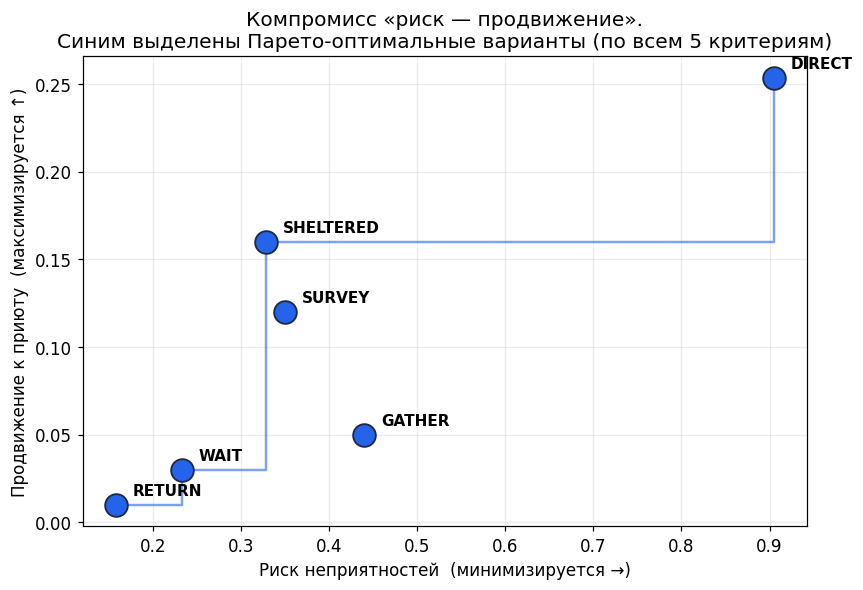

In [9]:
# =============================================================================
# Визуализация: компромисс «риск — продвижение» в демонстрационной ситуации
# -----------------------------------------------------------------------------
# Из пяти критериев выберем два самых конфликтных и нарисуем альтернативы
# точками. Идеал — левый верхний угол (риск 0, продвижение 1).
# =============================================================================

# plt.subplots создаёт рисунок (fig) и оси (ax), на которых будем рисовать.
fig, ax = plt.subplots(figsize=(8, 5.5))
# Значения двух столбцов матрицы как массивы: по X — риск, по Y — продвижение.
xs, ys = X_demo["risk"].values, X_demo["progress"].values

for i, a in enumerate(X_demo.index):
    on_front = a in PF_demo                  # True, если вариант в множестве Парето
    # scatter — точечная диаграмма. s — размер точки, c — цвет,
    # edgecolors — цвет обводки, zorder — «слой» (больше — выше).
    ax.scatter(xs[i], ys[i], s=220,
               c="#2563eb" if on_front else "#cbd5e1",
               edgecolors="#1e293b", linewidths=1.2, zorder=3)
    # annotate — подпись у точки; xytext сдвигает подпись на 11 и 6 пунктов.
    ax.annotate(a, (xs[i], ys[i]), textcoords="offset points", xytext=(11, 6),
                fontsize=10, fontweight="bold" if on_front else "normal")

# Ступенчатая граница: двигаясь слева направо (риск растёт), оставляем
# только точки, где продвижение выше всех предыдущих.
# sorted(...) сортирует пары (риск, продвижение) по возрастанию риска.
pf = sorted([(X_demo.loc[a, "risk"], X_demo.loc[a, "progress"]) for a in PF_demo])
best = -np.inf                     # «минус бесконечность»: любое число больше
line = []
for r, p in pf:
    if p > best:
        line.append((r, p))
        best = p
if len(line) > 1:
    # zip(*line) превращает список пар [(r1,p1), (r2,p2)] в два набора
    # (r1, r2) и (p1, p2) — координаты X и Y для функции step.
    ax.step(*zip(*line), where="post", color="#2563eb", lw=1.6, alpha=0.6, zorder=2)

ax.set_xlabel("Риск неприятностей  (минимизируется →)")
ax.set_ylabel("Продвижение к приюту  (максимизируется ↑)")
ax.set_title("Компромисс «риск — продвижение».\n"
             "Синим выделены Парето-оптимальные варианты (по всем 5 критериям)")
plt.tight_layout()     # аккуратно разместить подписи, чтобы не наезжали
plt.show()             # показать рисунок

**Как читать график.** По осям — два самых конфликтных критерия: риск (меньше — лучше,
идеал слева) и продвижение (больше — лучше, идеал сверху). Идеальная стратегия была бы
в левом верхнем углу, но такой нет. Синяя ступенчатая линия соединяет стратегии, которые
образуют **Парето-границу в этой проекции**: двигаясь вдоль неё вправо, мы «покупаем»
продвижение ценой риска.

Все шесть точек синие, потому что Парето-оптимальность проверялась по **всем пяти**
критериям: стратегия, которая на этом рисунке выглядит плохой, выигрывает по критериям,
которых здесь не видно. Например, SURVEY и рискованнее SHELTERED ($0{,}350\gt 0{,}328$),
и продвигает меньше ($0{,}120\lt 0{,}160$), зато она быстрее и даёт намного больше информации.
Двумерный рисунок — лишь срез пятимерной картины.

---
# §3. Методы скалярной свёртки: SAW и WPM

**Скалярная свёртка** — это способ «свернуть» строку из $m$ оценок в одно число — итоговый
балл альтернативы. Когда у каждой альтернативы есть один балл, выбрать лучшую просто:
у кого балл больше. Вся тонкость в том, **как** сворачивать.

## 3.1. SAW — метод взвешенной суммы

### Идея

SAW (Simple Additive Weighting — простое аддитивное взвешивание) — самый старый
и самый распространённый метод. Каждая оценка умножается на вес критерия, и всё
складывается. Так же считается средний балл в зачётке с учётом «веса» предметов.

### Формула

$$
F^{\text{SAW}}(a_i)=\sum_{j=1}^{m} w_j\,r_{ij}, \qquad\qquad (3.1)
$$

где $r_{ij}$ — нормализованная оценка (§2.1), $w_j$ — вес критерия, $\sum_j w_j=1$.
Лучшая альтернатива — с наибольшим $F^{\text{SAW}}$.

Если все $r_{ij}\in[0,1]$ и веса в сумме дают 1, то и $F^{\text{SAW}}\in[0,1]$: это
«средневзвешенная доля от идеала».

### Что на самом деле означает вес

В SAW вес — это **коэффициент замещения**. Пусть альтернатива потеряла $\Delta$ по
критерию 2. Чтобы итоговый балл не изменился, она должна выиграть по критерию 1

$$
\Delta_1=\frac{w_2}{w_1}\,\Delta_2 .
$$

Если $w_1=0{,}5$, а $w_2=0{,}25$, то потерю $0{,}2$ по второму критерию полностью
возмещает выигрыш $0{,}1$ по первому. Такое свойство называют **полной компенсацией**:
любой недостаток можно «выкупить» достоинством по другому критерию.

### Условия применимости

1. **Количественные оценки** в интервальной шкале или шкале отношений (§0.2).
2. **Взаимная независимость критериев по предпочтению**: то, насколько важен критерий,
   не должно зависеть от значений других критериев. Нарушение: «площадь мне важна,
   **только если** квартира недалеко от работы» — такую зависимость SAW не выразит.
3. **Допустимость компенсации**: ЛПР согласен, что недостаток можно возместить.

### Достоинства и недостатки

| Достоинства | Недостатки |
|---|---|
| прост и нагляден, считается вручную | результат зависит от схемы нормализации |
| веса имеют ясный смысл | полная компенсация: «перекос» по одному критерию может вытянуть плохую альтернативу |
| основа многих других методов (AHP, MAUT) | предполагает независимость критериев |

> **Разобранный пример** с ручным решением и проверкой кодом — в ноутбуке-спутнике
> `MCDA_Methods_Examples.ipynb`, пример 3.1.

## 3.2. WPM — метод взвешенного произведения

### Идея

WPM (Weighted Product Model) вместо суммы берёт **произведение** оценок, возведённых
в степени, равные весам. Произведение устроено иначе, чем сумма: если хотя бы один
сомножитель мал, мало и всё произведение. Поэтому WPM **строже наказывает слабые места**.

### Формула

$$
F^{\text{WPM}}(a_i)=\prod_{j=1}^{m} r_{ij}^{\,w_j}. \qquad\qquad (3.2)
$$

Символ $\prod$ означает произведение, так же как $\sum$ — сумму:
$\prod_{j=1}^{3} y_j=y_1\cdot y_2\cdot y_3$.

**Связь с SAW через логарифм.** Прологарифмируем (3.2):

$$
\ln F^{\text{WPM}}(a_i)=\sum_{j=1}^{m} w_j\,\ln r_{ij}.
$$

То есть WPM — это SAW, применённый к **логарифмам** оценок. Логарифм растягивает шкалу
около нуля: $\ln 0{,}9\approx-0{,}11$, а $\ln 0{,}3\approx-1{,}20$. Разница между «плохо»
и «очень плохо» для WPM гораздо больше, чем для SAW. Так получается **частичная
компенсация**: провал по одному критерию возместить трудно.

**Форма отношений.** Сравнить две альтернативы можно вообще без нормализации:

$$
P\!\left(\frac{a_k}{a_l}\right)=\prod_{j=1}^{m}\left(\frac{x_{kj}}{x_{lj}}\right)^{w_j}
\;\;\text{(для издержек дробь переворачивается).} \qquad (3.3)
$$

Если $P\gt 1$, то $a_k$ лучше $a_l$. Единицы измерения сокращаются в каждой дроби —
поэтому WPM **не зависит от выбора единиц**: хоть рубли, хоть тысячи рублей.

### Условия применимости

* Все оценки **строго положительны**: $0^{w}=0$ обнуляет произведение, а $\ln 0$ не
  определён. Поэтому перед WPM используют нормализацию (2.2), а не min–max (2.1).
* Шкала отношений: должно иметь смысл «в два раза больше».

### Достоинства и недостатки

| Достоинства | Недостатки |
|---|---|
| не зависит от единиц измерения (3.3) | не работает с нулевыми и отрицательными оценками |
| наказывает «перекосы», выбирает сбалансированные варианты | итоговый балл труднее интерпретировать, чем у SAW |
| устойчивее SAW к выбору схемы нормализации | ручной счёт требует степеней и логарифмов |

> **Разобранный пример** с ручным решением и проверкой кодом — в ноутбуке-спутнике
> `MCDA_Methods_Examples.ipynb`, пример 3.2 и мини-пример «перекос против ровности».

### Реализация в основной задаче

**Таблица 3.1. SAW (3.1): формула → код.**

| Формула | Python |
|---|---|
| $r_{ij}$ | `R = normalize(X, norm, directions)` — нормализованная матрица, по умолчанию min–max |
| $w_j$, выстроенные по столбцам | `w[R.columns]` — веса в том же порядке, что и столбцы `R` |
| $w_j\,r_{ij}$ | `R * w[R.columns]` — каждый столбец умножается на свой вес |
| $\sum_{j=1}^{m}$ | `.sum(axis=1)` — сумма **вдоль строки**, по всем критериям |
| вся формула: $F^{\text{SAW}}(a_i)=\sum_j w_j r_{ij}$ | `(R * w[R.columns]).sum(axis=1)` |

**Таблица 3.2. WPM (3.2): формула → код.**

| Формула | Python |
|---|---|
| $r_{ij}\gt 0$ | `normalize(X, "linear", ...).clip(lower=eps)` — схема (2.2) без нулей, плюс страховка |
| $\ln r_{ij}$ | `np.log(R)` — натуральный логарифм каждого элемента |
| $\sum_j w_j\ln r_{ij}$ | `(np.log(R) * w[R.columns]).sum(axis=1)` — SAW от логарифмов |
| $\prod_j r_{ij}^{w_j}=\exp\!\big(\sum_j w_j\ln r_{ij}\big)$ | `np.exp(logs)` — возврат из логарифмов |
| вся формула | `np.exp((np.log(R) * w[R.columns]).sum(axis=1))` |

Почему не написать произведение напрямую (`(R ** w).prod(axis=1)`)? При многих критериях
произведение чисел меньше 1 быстро становится крошечным, и точность теряется. Сумма
логарифмов численно устойчивее, а результат тот же.

In [10]:
# =============================================================================
# §3. СКАЛЯРНАЯ СВЁРТКА: SAW (формула 3.1) и WPM (формула 3.2)
# =============================================================================

def saw(X: pd.DataFrame, w: pd.Series, norm: str = "minmax",
        directions: Dict[str, str] = None) -> pd.Series:
    """SAW: F(a_i) = Σ_j w_j · r_ij — взвешенная сумма нормализованных оценок.

    Возвращает баллы альтернатив, отсортированные от лучшей к худшей.
    """
    R = normalize(X, norm, directions)     # шаг 1: нормализация, форма (n, m)
    # шаг 2: R * w[R.columns] умножает КАЖДЫЙ столбец на свой вес.
    # w[R.columns] выстраивает веса в том же порядке, что и столбцы R, —
    # защита от ошибки, если критерии в w перечислены в другом порядке.
    weighted = R * w[R.columns]
    # шаг 3: .sum(axis=1) — сумма ВДОЛЬ строки (по всем критериям).
    # axis=0 означало бы «по столбцу» (сверху вниз), axis=1 — «по строке».
    # .sort_values(ascending=False) — сортировка по убыванию.
    return weighted.sum(axis=1).sort_values(ascending=False)


def wpm(X: pd.DataFrame, w: pd.Series, norm: str = "linear", eps: float = 1e-6,
        directions: Dict[str, str] = None) -> pd.Series:
    """WPM: F(a_i) = Π_j r_ij^w_j — взвешенное произведение.

    Произведение многих чисел < 1 быстро становится очень маленьким, поэтому
    считаем через логарифм: ln F = Σ_j w_j · ln r_ij, затем F = exp(ln F).
    Это та же формула (3.2), только численно устойчивее.
    """
    # Нормализация по лучшему (2.2): у неё нет нулей, а ноль в произведении
    # обнулил бы всю оценку. .clip(lower=eps) — вторая страховка:
    # ln(0) = -∞, поэтому заменяем точные нули на крошечное eps.
    R = normalize(X, norm, directions).clip(lower=eps)
    # np.log — натуральный логарифм КАЖДОГО элемента таблицы.
    logs = (np.log(R) * w[R.columns]).sum(axis=1)   # Σ_j w_j · ln r_ij
    # np.exp — обратная операция: e в степени. Возвращаемся из логарифмов.
    return np.exp(logs).sort_values(ascending=False)


# --- Применяем к демонстрационной ситуации -----------------------------------
sc_saw = saw(X_demo, w_demo)       # веса — адаптивные w(s) из §1.4
sc_wpm = wpm(X_demo, w_demo)

# Сводим в одну таблицу. .reindex(STRATEGIES) расставляет строки
# в исходном порядке вариантов.
res_conv = pd.DataFrame({"SAW": sc_saw, "WPM": sc_wpm}).reindex(STRATEGIES)
# .rank(ascending=False) — место в рейтинге (1 — наибольший балл);
# .astype(int) — превратить 1.0 в целое 1.
res_conv["ранг SAW"] = res_conv["SAW"].rank(ascending=False).astype(int)
res_conv["ранг WPM"] = res_conv["WPM"].rank(ascending=False).astype(int)
# .index[0] — имя первой строки, то есть лидер после сортировки.
print(f"Лидер SAW: {sc_saw.index[0]}   |   Лидер WPM: {sc_wpm.index[0]}")
res_conv.sort_values("SAW", ascending=False).round(4)

Лидер SAW: WAIT   |   Лидер WPM: WAIT


,SAW,WPM,ранг SAW,ранг WPM
WAIT,0.6231,0.4701,1,1
SURVEY,0.6167,0.4674,2,2
GATHER,0.6122,0.4512,3,3
RETURN,0.6047,0.3782,4,5
SHELTERED,0.4695,0.3805,5,4
DIRECT,0.2712,0.2133,6,6


### Что получилось

В демонстрационном состоянии оба метода выбрали **WAIT**, и первые три места совпадают:
WAIT, SURVEY, GATHER. Но баллы очень близки: у SAW тройка лидеров укладывается в $0{,}011$
($0{,}6231$, $0{,}6167$, $0{,}6122$). Такой выбор хрупок — чуть другие веса, и лидер сменится.

Расхождение — на 4-м и 5-м местах: SAW ставит RETURN выше SHELTERED, WPM — наоборот.
У RETURN есть провалы: продвижение $0{,}010$ и информация $0{,}060$ — худшие в таблице;
после нормализации (2.2) это всего около 4 % и 6 % от лучших значений, и WPM наказывает
их сильнее, чем SAW. Это тот же эффект, что и с моделью B в примере 3.2 ноутбука-спутника.

DIRECT на последнем месте в обоих методах: при весе риска $0{,}397$ его риск $0{,}905$
не компенсируется ничем.

---
# §4. AHP — метод анализа иерархий

До сих пор веса мы задавали «на глаз». Но попробуйте честно ответить: вес цены — это
$0{,}35$ или $0{,}40$? Человеку трудно назвать абсолютное число. Зато легко сравнить
**две** вещи: «цена для меня важнее камеры — примерно в три раза». На этой психологической
особенности построен метод анализа иерархий американского математика Томаса Саати
(Analytic Hierarchy Process, AHP).

## Теория

### Иерархия

Задача представляется в виде дерева из трёх уровней:

* **цель** — «выбрать лучшее место практики»;
* **критерии** — по чему выбираем;
* **альтернативы** — из чего выбираем.

На каждом уровне элементы сравниваются **попарно** относительно элемента уровнем выше:
критерии — относительно цели, альтернативы — относительно каждого критерия.

### Шкала Саати

Суждение «во сколько раз $i$ важнее $j$» выражается числом от 1 до 9:

| Число $a_{ij}$ | Смысл |
|:--:|---|
| 1 | $i$ и $j$ одинаково важны |
| 3 | $i$ умеренно важнее $j$ |
| 5 | $i$ существенно важнее $j$ |
| 7 | $i$ значительно важнее $j$ |
| 9 | $i$ абсолютно важнее $j$ |
| 2, 4, 6, 8 | промежуточные суждения |
| $1/3,\;1/5,\dots$ | обратные: $j$ важнее $i$ |

Верхний предел 9 выбран не случайно: человек надёжно различает лишь несколько градаций
интенсивности, и более тонкая шкала не делает суждения точнее.

### Матрица парных сравнений

Суждения записываются в квадратную матрицу $A=[a_{ij}]$ размера $m\times m$ со свойствами

$$
a_{ii}=1,\qquad a_{ji}=\frac{1}{a_{ij}} \quad\text{(обратная симметрия).}
$$

Поэтому достаточно заполнить только клетки над диагональю — это $\dfrac{m(m-1)}{2}$
суждений (для 3 критериев — 3, для 5 — 10).

### Откуда берутся веса: собственный вектор

Представим, что истинные веса $w_1,\dots,w_m$ известны, а суждения **идеально точны**:
$a_{ij}=w_i/w_j$. Умножим $i$-ю строку матрицы на вектор весов:

$$
(Aw)_i=\sum_{j=1}^{m} a_{ij}w_j=\sum_{j=1}^{m}\frac{w_i}{w_j}\,w_j=\sum_{j=1}^{m} w_i=m\,w_i .
$$

Значит, $Aw=m\,w$: вектор весов — **собственный вектор** матрицы $A$ с собственным числом $m$.
Реальные суждения неточны, и Саати предложил искать веса как главный собственный вектор:

$$
A\,w=\lambda_{\max}\,w,\qquad \sum_j w_j=1, \qquad\qquad (4.1)
$$

где $\lambda_{\max}$ — наибольшее собственное число. Для положительной обратносимметричной
матрицы всегда $\lambda_{\max}\ge m$, и равенство достигается только при идеальной согласованности.

**Приближённый способ для ручного счёта — среднее геометрическое строк:**

$$
g_i=\Big(\prod_{j=1}^{m} a_{ij}\Big)^{1/m},\qquad w_i=\frac{g_i}{\sum_k g_k}, \qquad\qquad (4.2)
$$

а собственное число оценивается так:

$$
\lambda_{\max}\approx\frac{1}{m}\sum_{i=1}^{m}\frac{(Aw)_i}{w_i}. \qquad\qquad (4.3)
$$

Для матриц $3\times 3$ формула (4.2) даёт **в точности** главный собственный вектор,
для больших — близкое к нему приближение.

### Согласованность суждений

Идеально согласованная матрица удовлетворяет условию $a_{ij}\,a_{jk}=a_{ik}$: если
A важнее B в 2 раза, а B важнее C в 3 раза, то A важнее C в 6 раз. Люди так строго
не рассуждают, и небольшие противоречия допустимы. Их меру дают

$$
CI=\frac{\lambda_{\max}-m}{m-1}\;\;\text{(индекс согласованности)},\qquad
CR=\frac{CI}{RI}\;\;\text{(отношение согласованности)}, \qquad (4.4)
$$

где $RI$ — средний $CI$ для **случайно** заполненных матриц того же размера:

| $m$ | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 |
|---|---|---|---|---|---|---|---|---|---|---|
| $RI$ | 0 | 0 | 0,58 | 0,90 | 1,12 | 1,24 | 1,32 | 1,41 | 1,45 | 1,49 |

**Правило:** суждения приемлемы, если $CR\lt 0{,}10$, то есть противоречивость не превышает
10 % от противоречивости случайных ответов. Иначе суждения надо пересмотреть.

### Синтез: глобальные приоритеты

Если альтернативы тоже сравнивались попарно по каждому критерию и получены **локальные
приоритеты** $v_{ij}$ ($i$-я альтернатива по $j$-му критерию), итоговый (глобальный)
приоритет альтернативы — взвешенная сумма:

$$
P(a_i)=\sum_{j=1}^{m} w_j\,v_{ij}. \qquad\qquad (4.5)
$$

Это тот же SAW, только и веса, и оценки получены из парных сравнений.

### Достоинства и недостатки

| Достоинства | Недостатки |
|---|---|
| попарные суждения проще абсолютных | число сравнений растёт как $m^2$ |
| встроенная проверка согласованности ЛПР | при добавлении альтернативы порядок старых может измениться |
| работает и с качественными критериями | шкала 1–9 условна: «в 5 раз важнее» — субъективная оценка |

> **Разобранный пример** с ручным решением и проверкой кодом — в ноутбуке-спутнике
> `MCDA_Methods_Examples.ipynb`, примеры 4.1 (полный расчёт AHP) и 4.2 (несогласованные суждения).

## Реализация в основной задаче

В основной задаче ЛПР — геймдизайнер, который задаёт «характер» NPC. Он заполняет матрицу
парных сравнений пяти критериев агента, и из неё получаются веса. Код считает главный
собственный вектор точно (функция `np.linalg.eig`), без приближения (4.2).

Функция `build_pairwise` избавляет от рутины: достаточно перечислить суждения над
диагональю, а единицы на диагонали и обратные элементы дописываются автоматически.

**Таблица 4.1. Веса и согласованность AHP (4.1)–(4.4): формула → код.**

| Формула | Python |
|---|---|
| $a_{ii}=1$ | `P = np.ones((m, m))` — начинаем с матрицы из единиц: диагональ готова |
| $a_{ji}=1/a_{ij}$ | `P[idx[j], idx[i]] = 1.0 / v` — обратный элемент для каждого суждения |
| $A\,w=\lambda\,w$ | `eigval, eigvec = np.linalg.eig(P)` — все собственные числа и векторы |
| $\lambda_{\max}$ | `k = np.argmax(eigval.real)`; `lam_max = eigval[k].real` — наибольшее из них |
| $w,\;\sum_j w_j=1$ | `v = np.abs(eigvec[:, k].real)`; `w = v / v.sum()` — вектор определён с точностью до множителя, нормируем |
| $CI=\dfrac{\lambda_{\max}-m}{m-1}$ | `CI = (lam_max - m) / (m - 1)` |
| $CR=CI/RI$ | `CR = CI / RI_TABLE[m]` — при $m\le 2$ $RI=0$, и $CR$ полагается равным 0 |
| вся процедура | `w, lam_max, CI, CR = ahp_weights(P, labels)` |

`eigvec[:, k]` — это $k$-й **столбец** массива собственных векторов (двоеточие означает
«все строки»). `.real` отбрасывает мнимую часть: у несимметричных матриц NumPy возвращает
комплексные числа, хотя у главного собственного вектора мнимая часть нулевая.

In [11]:
# =============================================================================
# §4. AHP: ВЕСА КРИТЕРИЕВ ИЗ ПАРНЫХ СРАВНЕНИЙ
# -----------------------------------------------------------------------------
# Реализуем формулы (4.1)–(4.4): главный собственный вектор матрицы парных
# сравнений даёт веса, собственное число λ_max — меру согласованности.
# =============================================================================

# Индекс случайной согласованности RI по Саати: средний CI случайно
# заполненных матриц размера m. Для m = 1 и 2 любая матрица согласована.
RI_TABLE = {1: 0.00, 2: 0.00, 3: 0.58, 4: 0.90, 5: 1.12,
            6: 1.24, 7: 1.32, 8: 1.41, 9: 1.45, 10: 1.49}


def ahp_weights(P: np.ndarray, labels: List[str]) -> Tuple[pd.Series, float, float, float]:
    """Веса, λ_max, CI и CR по матрице парных сравнений P (формулы 4.1–4.4).

    Функция возвращает сразу ЧЕТЫРЕ значения (кортеж). При вызове их можно
    разложить по четырём переменным: w, lam, CI, CR = ahp_weights(...).
    """
    P = np.asarray(P, dtype=float)     # превратить вход (например, список
                                       # списков) в массив NumPy
    m = P.shape[0]                     # .shape — форма массива (строк, столбцов)
    # assert проверяет условие и останавливает программу, если оно ложно.
    assert P.shape == (m, m), "Матрица парных сравнений должна быть квадратной"

    # np.linalg.eig возвращает ВСЕ собственные числа и собственные векторы.
    # У положительной обратносимметричной матрицы наибольшее собственное
    # число вещественно (теорема Перрона — Фробениуса).
    eigval, eigvec = np.linalg.eig(P)
    # .real — вещественная часть (NumPy может вернуть комплексные числа);
    # np.argmax — НОМЕР наибольшего элемента.
    k = int(np.argmax(eigval.real))
    lam_max = float(eigval[k].real)                 # λ_max из формулы (4.1)

    # eigvec[:, k] — k-й СТОЛБЕЦ массива (двоеточие = «все строки»).
    # Собственный вектор определён с точностью до множителя и знака,
    # поэтому берём модуль (np.abs) и нормируем к сумме 1.
    v = np.abs(eigvec[:, k].real)
    w = pd.Series(v / v.sum(), index=labels)

    CI = (lam_max - m) / (m - 1) if m > 1 else 0.0              # (4.4)
    # .get(m, 1.49) — взять значение по ключу m, а если его нет — 1.49.
    RI = RI_TABLE.get(m, 1.49)
    CR = CI / RI if RI > 0 else 0.0                             # (4.4)
    return w, lam_max, CI, CR


def build_pairwise(prefs: Dict[Tuple[str, str], float], labels: List[str]) -> pd.DataFrame:
    """Матрица парных сравнений из словаря {(i, j): a_ij}.

    Достаточно задать только суждения «i важнее j в a_ij раз»; обратные
    элементы a_ji = 1 / a_ij и единицы на диагонали дописываются
    автоматически — так матрица гарантированно обратносимметрична.
    """
    m = len(labels)
    # Словарь «имя критерия -> его номер»: {"progress": 0, "risk": 1, ...}
    idx = {c: i for i, c in enumerate(labels)}
    P = np.ones((m, m))                             # матрица из единиц: a_ii = 1
    # .items() выдаёт пары (ключ, значение). Ключ здесь — кортеж (i, j),
    # и его сразу «распаковываем» в две переменные.
    for (i, j), v in prefs.items():
        P[idx[i], idx[j]] = v                       # прямое суждение
        P[idx[j], idx[i]] = 1.0 / v                 # обратное: a_ji = 1/a_ij
    return pd.DataFrame(P, index=labels, columns=labels)


# --- Суждения ЛПР: профиль «осторожного путешественника» ----------------------
# Читается так: ("risk", "progress"): 2 — «риск важнее продвижения в 2 раза».
# ЗАДАНИЕ 1: замените эти числа своими и добейтесь CR < 0.10.
prefs_careful = {
    ("progress", "time"): 3,  ("progress", "supply"): 2,  ("progress", "info"): 2,
    ("risk", "progress"): 2,  ("risk", "time"): 4,  ("risk", "supply"): 3,
    ("risk", "info"): 3,
    ("info", "time"): 2,      ("info", "supply"): 1,
    ("supply", "time"): 2,
}
P_careful = build_pairwise(prefs_careful, CRITERIA)
# P_careful.values — «голый» массив чисел из таблицы.
w_ahp, lam, CI, CR = ahp_weights(P_careful.values, CRITERIA)

print(f"λ_max = {lam:.4f}   CI = {CI:.4f}   CR = {CR:.4f}   → ",
      "СОГЛАСОВАНО (CR < 0.10)" if CR < 0.10
      else "НЕ СОГЛАСОВАНО, суждения надо пересмотреть")
print("\nМатрица парных сравнений:")
display(P_careful.round(3))
print("\nПолученные веса:")
# .rename(index=словарь) заменяет подписи строк по словарю.
w_ahp.rename(index=CRIT_LABELS).round(4)

λ_max = 5.0331   CI = 0.0083   CR = 0.0074   →  СОГЛАСОВАНО (CR < 0.10)

Матрица парных сравнений:


,progress,risk,time,supply,info
progress,1.000,0.500,3.0,2.0,2.0
risk,2.000,1.000,4.0,3.0,3.0
time,0.333,0.250,1.0,0.5,0.5
supply,0.500,0.333,2.0,1.0,1.0
info,0.500,0.333,2.0,1.0,1.0



Полученные веса:


Продвижение к приюту    0.2444
Риск неприятностей      0.4030
Затраты времени         0.0791
Восстановление          0.1367
Знание местности        0.1367
dtype: float64

### Что получилось

Суждения «осторожного путешественника» согласованы: $\lambda_{\max}=5{,}033$ при $m=5$, откуда
$CI=0{,}0083$ и $CR=0{,}0074$ — в тринадцать раз ниже порога $0{,}10$.

Самый весомый критерий — риск ($0{,}403$), за ним продвижение ($0{,}244$). Восстановление
и информация получили одинаковые веса ($0{,}137$): в матрице они сравнены как равные
($a=1$) и одинаково соотносятся со всеми остальными критериями. Меньше всего весит время ($0{,}079$).

Эти веса пока нигде не используются: в §11 политика строится от `W_BASE`. В **задании 2**
вы подставите вместо них свои веса `w_ahp` и посмотрите, как изменится поведение агента.

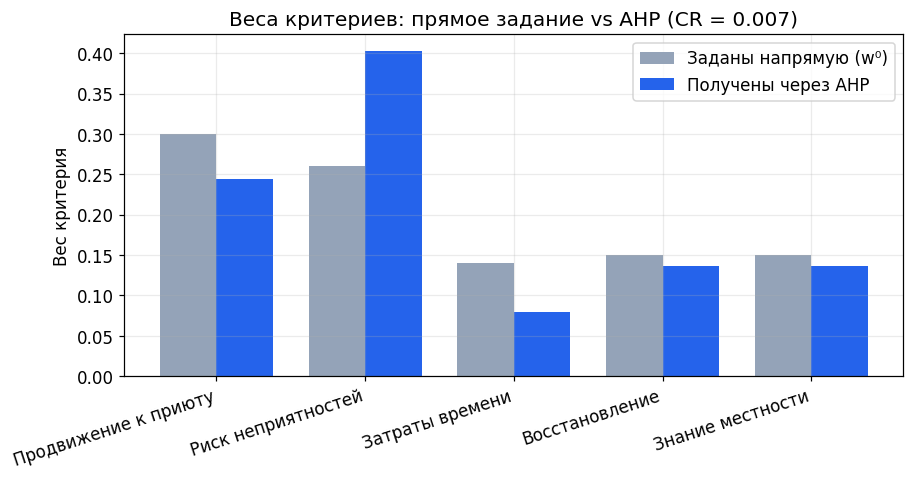

In [12]:
# =============================================================================
# Сравнение: веса, заданные «на глаз» (W_BASE), и веса, полученные через AHP
# =============================================================================
fig, ax = plt.subplots(figsize=(8.5, 4.5))
# np.arange(5) — массив [0, 1, 2, 3, 4]: позиции групп столбиков по оси X.
x = np.arange(len(CRITERIA))
width = 0.38                      # ширина столбика; две группы сдвинуты на ±width/2
# ax.bar(позиции, высоты, ширина, ...) — столбчатая диаграмма.
ax.bar(x - width / 2, W_BASE[CRITERIA].values, width,
       label="Заданы напрямую (w⁰)", color="#94a3b8")
ax.bar(x + width / 2, w_ahp[CRITERIA].values, width,
       label="Получены через AHP", color="#2563eb")
ax.set_xticks(x)                  # где ставить подписи по оси X
ax.set_xticklabels([CRIT_LABELS[c] for c in CRITERIA], rotation=18, ha="right")
ax.set_ylabel("Вес критерия")
ax.legend()                       # легенда: какой цвет что означает
ax.set_title(f"Веса критериев: прямое задание vs AHP (CR = {CR:.3f})")
plt.tight_layout()
plt.show()

**Как читать график.** Серые столбики — веса, назначенные «на глаз», синие — полученные
через AHP из суждений осторожного путешественника. Главная разница — в риске: прямое задание
дало $0{,}26$, AHP — $0{,}40$. Так AHP часто «проявляет» предпочтения, в которых ЛПР сам себе
не признаётся: назвать риск самым важным критерием проще, чем вычислить, что он весит
больше, чем время, восстановление и информация вместе взятые.

---
# §5. TOPSIS — близость к идеальному решению

## Теория

### Идея

Представим каждую альтернативу **точкой** в пространстве критериев: у точки столько
координат, сколько критериев. Теперь вообразим две несуществующие альтернативы:

* **идеальную** $A^+$ — лучшую по каждому критерию сразу (самую дешёвую, самую быструю,
  самую качественную);
* **антиидеальную** $A^-$ — худшую по каждому критерию.

Хорошая альтернатива должна быть **близко к идеалу и далеко от антиидеала**. Это и есть
TOPSIS — Technique for Order Preference by Similarity to Ideal Solution, метод Хвана и Юна (1981).

Почему не достаточно одного расстояния до идеала? Две альтернативы могут быть одинаково
далеки от идеала, но одна при этом «провальная» по какому-то критерию (близка к антиидеалу),
а другая — нет. Учёт обоих расстояний различает эти случаи.

### Алгоритм и формулы

**Шаг 1. Векторная нормализация** (2.3):

$$
r_{ij}=\frac{x_{ij}}{\sqrt{\sum_{k=1}^{n}x_{kj}^{2}}}. \qquad\qquad (5.1)
$$

**Шаг 2. Взвешенная нормализованная матрица:**

$$
v_{ij}=w_j\,r_{ij}. \qquad\qquad (5.2)
$$

Вес здесь работает как **масштаб оси**: ось важного критерия растягивается, и отклонения
по ней сильнее влияют на расстояние.

**Шаг 3. Идеальная и антиидеальная точки:**

$$
A^+=(v_1^+,\dots,v_m^+),\quad
v_j^+=\begin{cases}\max_i v_{ij}, & j\;\text{— выгода},\\ \min_i v_{ij}, & j\;\text{— издержка};\end{cases}
\qquad
v_j^-=\begin{cases}\min_i v_{ij}, & j\;\text{— выгода},\\ \max_i v_{ij}, & j\;\text{— издержка}.\end{cases} \qquad (5.3)
$$

**Шаг 4. Евклидовы расстояния** до идеала и антиидеала:

$$
d_i^+=\sqrt{\sum_{j=1}^{m}\big(v_{ij}-v_j^+\big)^2},\qquad
d_i^-=\sqrt{\sum_{j=1}^{m}\big(v_{ij}-v_j^-\big)^2}. \qquad (5.4)
$$

**Шаг 5. Коэффициент относительной близости:**

$$
C_i=\frac{d_i^-}{d_i^+ + d_i^-}\in[0,1]. \qquad\qquad (5.5)
$$

$C_i=1$, если альтернатива совпадает с идеалом ($d_i^+=0$); $C_i=0$, если с антиидеалом.

**Шаг 6.** Ранжировать альтернативы по убыванию $C_i$.

### Достоинства и недостатки

| Достоинства | Недостатки |
|---|---|
| наглядная геометрическая идея | евклидово расстояние предполагает, что критерии «перпендикулярны» — независимы |
| итоговый балл в $[0,1]$ легко интерпретировать | при добавлении или удалении альтернативы идеал сдвигается, и порядок остальных может измениться |
| учитывает и лучшее, и худшее | компенсаторен, как SAW |
| прост в программировании | не проверяет согласованность весов — их надо получить отдельно (например, AHP) |

> **Разобранный пример** с ручным решением и проверкой кодом — в ноутбуке-спутнике
> `MCDA_Methods_Examples.ipynb`, пример 5.1.

## Реализация в основной задаче

В коде есть одно отличие от классического алгоритма. Функция `normalize` в режиме `"vector"`
сразу **отражает** издержки: $r'_{ij}=1-r_{ij}$. После этого все критерии — выгоды,
и идеал всегда равен максимуму столбца. Меняет ли это ответ? Нет. Пусть $v'=w(1-r)=w-v$.
Тогда идеал $v'^+=\max(w-v)=w-\min v$, и

$$
v'_{ij}-v'^{+}_j=(w_j-v_{ij})-(w_j-\min_i v_{ij})=-(v_{ij}-\min_i v_{ij}),
$$

то есть разность отличается от классической только знаком, а в квадрате (5.4) знак
пропадает. Расстояния, а значит, и $C_i$ совпадают. В ноутбуке-спутнике функция
`topsis` на данных примера 5.1 даёт ровно $0{,}573$; $0{,}537$; $0{,}472$; $0{,}427$ — те же числа,
что ручной расчёт по классическому алгоритму.

**Таблица 5.1. TOPSIS (5.1)–(5.5): формула → код.**

| Формула | Python |
|---|---|
| $r_{ij}$ (5.1), издержки отражены | `R = normalize(X, "vector", directions)` |
| $v_{ij}=w_j r_{ij}$ (5.2) | `V = R * w[R.columns]` — каждый столбец масштабирован своим весом |
| $v_j^+=\max_i v_{ij}$ | `ideal = V.max(axis=0)` — `axis=0`: максимум **по строкам**, одно число на столбец |
| $v_j^-=\min_i v_{ij}$ | `anti_ideal = V.min(axis=0)` |
| $(v_{ij}-v_j^+)^2$ | `(V - ideal) ** 2` — строка `ideal` вычитается из каждой строки `V` |
| $\sqrt{\sum_j(\ldots)^2}$ | `np.sqrt((...).sum(axis=1))` — сумма вдоль строки, затем корень |
| $C_i=d_i^-/(d_i^++d_i^-)$ | `d_minus / (d_plus + d_minus + 1e-12)` — `1e-12` спасает от деления на 0 |
| вся процедура | `topsis(X, w, detail=True)` — таблица $d^+$, $d^-$, $C$ |

Операция `V - ideal`, где `V` — таблица $6\times 5$, а `ideal` — строка из 5 чисел, называется
**broadcasting** («растягивание»): pandas сам повторяет строку `ideal` для каждой из шести
строк `V`. Писать цикл не нужно.

In [13]:
# =============================================================================
# §5. TOPSIS: БЛИЗОСТЬ К ИДЕАЛУ (формулы 5.1–5.5)
# =============================================================================

def topsis(X: pd.DataFrame, w: pd.Series, norm: str = "vector",
           detail: bool = False, directions: Dict[str, str] = None):
    """TOPSIS: C_i = d_i^- / (d_i^+ + d_i^-).

    detail=False — вернуть только коэффициенты близости C (отсортированные);
    detail=True  — вернуть таблицу с расстояниями d+, d- и C.
    """
    # Шаг 1 (5.1). Векторная нормализация. Для издержек функция normalize
    # уже выполнила отражение 1 - v, поэтому дальше ВСЕ столбцы — «выгоды».
    R = normalize(X, norm, directions)

    # Шаг 2 (5.2). Взвешивание: v_ij = w_j · r_ij. Вес «растягивает» ось
    # своего критерия: важный критерий сильнее влияет на расстояния.
    V = R * w[R.columns]

    # Шаг 3 (5.3). Идеальная и антиидеальная точки. Всё приведено к
    # «больше — лучше», поэтому идеал — максимум столбца, антиидеал — минимум.
    # axis=0: вычисляем ВДОЛЬ столбца (по всем строкам) — одно число
    # на каждый столбец. Результат — Series из 5 чисел.
    ideal      = V.max(axis=0)
    anti_ideal = V.min(axis=0)

    # Шаг 4 (5.4). Евклидовы расстояния до идеала и антиидеала:
    # корень из суммы квадратов разностей по всем критериям.
    # V - ideal вычитает строку ideal из КАЖДОЙ строки V — это называется
    # «broadcasting» (растягивание), цикл писать не нужно.
    # ** 2 — возведение в квадрат; np.sqrt — квадратный корень.
    d_plus  = np.sqrt(((V - ideal)      ** 2).sum(axis=1))
    d_minus = np.sqrt(((V - anti_ideal) ** 2).sum(axis=1))

    # Шаг 5 (5.5). Коэффициент относительной близости. 1e-12 в знаменателе
    # спасает от деления на ноль, если все альтернативы совпадают.
    C = d_minus / (d_plus + d_minus + 1e-12)

    if detail:
        # Скобки вокруг длинного выражения позволяют перенести его на
        # несколько строк — Python продолжит читать до закрывающей скобки.
        return (pd.DataFrame({"d+": d_plus, "d-": d_minus, "C": C})
                .sort_values("C", ascending=False))
    return C.sort_values(ascending=False)


det = topsis(X_demo, w_demo, detail=True)
print("Лидер TOPSIS:", det.index[0])
det.round(4)

Лидер TOPSIS: WAIT


,d+,d-,C
WAIT,0.1438,0.2593,0.6433
RETURN,0.1712,0.2712,0.6131
GATHER,0.1508,0.2375,0.6117
SURVEY,0.1632,0.2167,0.5703
SHELTERED,0.1780,0.2163,0.5486
DIRECT,0.3141,0.1316,0.2952


### Что получилось

TOPSIS, как и SAW с WPM, выбрал **WAIT** ($C=0{,}643$). Но порядок остальных иной: второе
место у RETURN ($0{,}613$), которого SAW ставил четвёртым. Почему? RETURN лучше всех по
самому тяжёлому критерию — риску (вес $0{,}397$), и в TOPSIS этот критерий «растягивает»
пространство сильнее всего. Поэтому RETURN оказывается далеко от антиидеала
($d^-=0{,}271$ — наибольшее значение в таблице), хотя к идеалу он дальше, чем WAIT
($d^+=0{,}171$ против $0{,}144$).

DIRECT последний с большим отрывом: $C=0{,}295$. Он ближе всех к антиидеалу, потому что худший
именно по риску.

Разрыв между первым и вторым местом — $0{,}030$. Это и есть **запас превосходства** (margin),
который в §11 будет решать, выбирает ли агент стратегию уверенно или «бросает монетку».

---
# §6. MAUT — теория многокритериальной полезности

## Теория

### Идея

SAW складывает нормализованные оценки так, будто каждая следующая единица критерия ценна
ровно столько же, сколько предыдущая. Но люди так не оценивают. Прибавка зарплаты с 60
до 90 тыс. руб. меняет жизнь сильнее, чем прибавка с 150 до 180 тыс. — хотя разница
одинаковая. Первые единицы безопасности важнее последних.

**Функция полезности** $u(x)$ переводит «объективное» значение критерия в «субъективную
ценность» для ЛПР. MAUT (Multi-Attribute Utility Theory — теория многокритериальной
полезности, Р. Кини и Х. Райфа, 1976) строит такую функцию для каждого критерия
и складывает полезности.

### Полезность и риск

Функция полезности особенно важна, когда исход **случаен**. Пусть альтернатива — это
**лотерея**: с вероятностью $p_k$ получаем исход $x_k$. Её оценивают **ожидаемой полезностью**

$$
EU=\sum_{k} p_k\,u(x_k). \qquad\qquad (6.1)
$$

Фон Нейман и Моргенштерн доказали: если предпочтения ЛПР между лотереями разумны (полны,
транзитивны, непрерывны и не зависят от посторонних исходов), то существует функция $u$,
при которой ЛПР всегда выбирает лотерею с наибольшим $EU$.

Сравним лотерею с её **ожидаемым значением** $EV=\sum_k p_k x_k$ — средним выигрышем:

* если $u(EV)\gt EU$, ЛПР предпочитает гарантированный средний результат лотерее —
  он **избегает риска**, и его $u$ **вогнута** (выгнута вверх, как купол);
* если $u(EV)\lt EU$ — **склонен к риску**, $u$ **выпукла**;
* если $u(EV)=EU$ — **нейтрален** к риску, $u$ линейна.

**Эквивалент определённости** $CE$ — такая гарантированная сумма, которая для ЛПР равноценна
лотерее: $u(CE)=EU$. Разность $EV-CE$ называется **премией за риск** — сколько ЛПР готов
«заплатить», чтобы избавиться от неопределённости:

$$
u(CE)=EU,\qquad \text{премия за риск}=EV-CE. \qquad\qquad (6.2)
$$

### Экспоненциальная функция полезности

Удобное семейство функций на отрезке $[0,1]$ с одним параметром $c$:

$$
u(x')=\frac{1-e^{-c\,x'}}{1-e^{-c}},\qquad x'\in[0,1]. \qquad\qquad (6.3)
$$

Здесь $x'$ — значение критерия, приведённое к $[0,1]$ и направлению «больше — лучше».
Свойства: $u(0)=0$ и $u(1)=1$ при любом $c$;

* $c\gt 0$ — вогнутая функция, **неприятие риска** (чем больше $c$, тем сильнее);
* $c\lt 0$ — выпуклая, **склонность к риску**;
* $c\to 0$ — прямая $u(x')=x'$, и MAUT превращается в SAW.

### Многокритериальная полезность

Если критерии **взаимно независимы по предпочтению** (ценность одного не зависит от значений
других), общая полезность — аддитивная:

$$
U(a_i)=\sum_{j=1}^{m} k_j\,u_j(x'_{ij}),\qquad \sum_j k_j=1. \qquad\qquad (6.4)
$$

Коэффициенты $k_j$ похожи на веса, но их смысл точнее: $k_j$ — ценность перехода $j$-го
критерия **от худшего значения шкалы к лучшему** при остальных критериях на худшем уровне.
Поэтому $k_j$ зависит от диапазона шкалы: если зарплаты различаются на 5 тыс., её $k_j$
должен быть мал, даже если «деньги важны».

### Достоинства и недостатки

| Достоинства | Недостатки |
|---|---|
| учитывает отношение ЛПР к риску | построение $u_j$ требует долгого опроса ЛПР |
| строгое аксиоматическое обоснование | аддитивная форма верна только при независимости критериев |
| при $c_j=0$ совпадает с SAW — удобно сравнивать | люди на практике нарушают аксиомы (парадокс Алле) |

> **Разобранный пример** с ручным решением и проверкой кодом — в ноутбуке-спутнике
> `MCDA_Methods_Examples.ipynb`, примеры 6.1 (лотерея и эквивалент определённости) и 6.2 (MAUT против SAW).

## Реализация в основной задаче

У путешественника своё отношение к риску по каждому критерию — словарь `RISK_ATTITUDE`:

* по **риску** $c=2{,}5$ — сильная вогнутость: уйти от очень высокого риска к просто
  заметному ценнее, чем от спокойной прогулки к совсем спокойной;
* по **продвижению** $c=-1$ — выпуклость, азарт: последние шаги к приюту ценятся больше первых;
* по остальным — умеренное неприятие риска.

Одно отличие от примера 6.2 ноутбука-спутника: в коде шкала каждого критерия — это min–max **по текущей
матрице** (как в §2.1), а не диапазон, названный ЛПР. Для учебной модели это удобнее —
шкалы не надо задавать вручную для каждого из 243 состояний.

**Таблица 6.1. MAUT (6.3)–(6.4): формула → код.**

| Формула | Python |
|---|---|
| $x'_{ij}\in[0,1]$, «больше — лучше» | `R = normalize(X, "minmax", directions)` |
| $c_j$ | `attitude.get(c, 0.0)` — если коэффициент не задан, критерий нейтрален к риску |
| $1-e^{-c\,x'}$ | `1 - np.exp(-c * x)` — числитель (6.3) |
| $1-e^{-c}$ | `1 - np.exp(-c)` — знаменатель: гарантирует $u(1)=1$ |
| $c\to 0$ | `if abs(c) < 1e-9: return x` — предел формулы — прямая; иначе было бы деление $0/0$ |
| $k_j\,u_j(x'_{ij})$ | `U * w[U.columns]` — роль $k_j$ играют веса $w_j$ |
| вся формула: $U(a_i)=\sum_j k_j u_j(x'_{ij})$ | `(U * w[U.columns]).sum(axis=1)` |

Лидер MAUT: GATHER


,U(a)
GATHER,0.7230
WAIT,0.6945
SURVEY,0.6890
RETURN,0.6372
SHELTERED,0.5403
DIRECT,0.2881


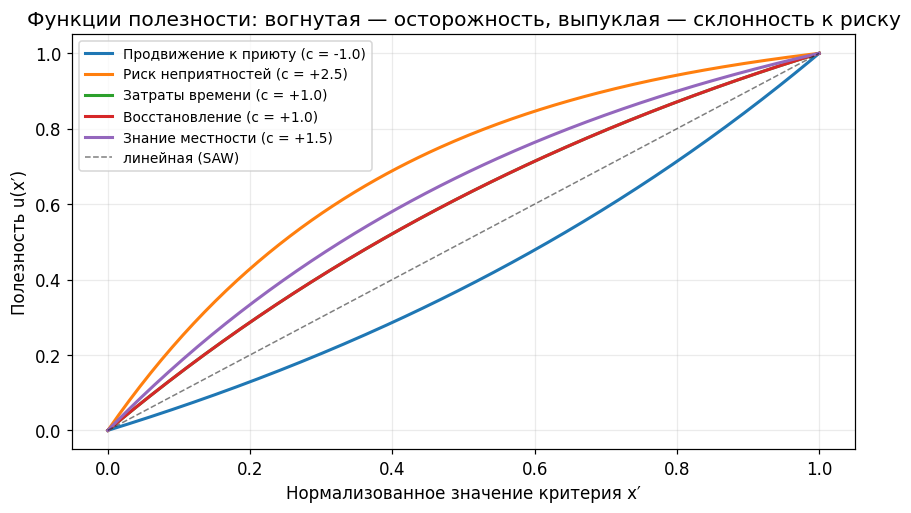

In [14]:
# =============================================================================
# §6. MAUT: МНОГОКРИТЕРИАЛЬНАЯ ФУНКЦИЯ ПОЛЕЗНОСТИ (формулы 6.3–6.4)
# =============================================================================

def utility(x: np.ndarray, c: float) -> np.ndarray:
    """Экспоненциальная функция полезности на [0, 1] (формула 6.3).

    u(0) = 0, u(1) = 1 при любом c.
    c > 0 — вогнутая функция, неприятие риска (осторожность);
    c < 0 — выпуклая функция, склонность к риску (азарт);
    c = 0 — прямая u(x) = x: MAUT совпадает с SAW.
    """
    x = np.asarray(x, dtype=float)
    # abs(c) — модуль числа. При c, очень близком к нулю, формула дала бы
    # деление 0/0, поэтому отдельно возвращаем её предел — сам x.
    if abs(c) < 1e-9:
        return x
    # np.exp(-c * x) — e в степени (-c·x) для каждого элемента массива.
    return (1 - np.exp(-c * x)) / (1 - np.exp(-c))


# Коэффициенты отношения к риску c_j для каждого критерия основной задачи.
# Это «характер» путешественника, выраженный не весами, а формой кривых.
RISK_ATTITUDE = {
    "progress": -1.0,   # азарт: последние шаги к приюту ценятся особенно высоко
    "risk":      2.5,   # сильная осторожность: уйти от серьёзных неприятностей важнее всего
    "time":      1.0,
    "supply":    1.0,
    "info":      1.5,
}


def maut(X: pd.DataFrame, w: pd.Series,
         attitude: Dict[str, float] = RISK_ATTITUDE, norm: str = "minmax",
         directions: Dict[str, str] = None) -> pd.Series:
    """MAUT: U(a_i) = Σ_j k_j · u_j(x'_ij) — аддитивная модель полезности (6.4).

    Роль шкалирующих коэффициентов k_j здесь играют веса w.
    """
    # x' — значение, приведённое к [0, 1] и направлению «больше — лучше».
    # В коде шкала берётся min–max по текущей матрице; в учебном примере
    # ЛПР задавал диапазоны сам (см. текст) — это единственное отличие.
    R = normalize(X, norm, directions)
    # Для каждого критерия c применяем свою функцию полезности со своим c_j.
    # attitude.get(c, 0.0): если коэффициент не задан, считаем критерий
    # нейтральным к риску (линейная полезность).
    # R[c].values — массив значений столбца c.
    U = pd.DataFrame({c: utility(R[c].values, attitude.get(c, 0.0))
                      for c in R.columns}, index=R.index)
    # Аддитивная свёртка — та же взвешенная сумма, что в SAW,
    # только от полезностей u_j(x'), а не от самих x'.
    return (U * w[U.columns]).sum(axis=1).sort_values(ascending=False)


sc_maut = maut(X_demo, w_demo)
print("Лидер MAUT:", sc_maut.index[0])
# .to_frame("U(a)") превращает столбец Series в таблицу с заголовком U(a).
display(sc_maut.round(4).to_frame("U(a)"))

# --- Графики функций полезности всех пяти критериев --------------------------
grid = np.linspace(0, 1, 200)          # 200 равномерных точек на отрезке [0, 1]
fig, ax = plt.subplots(figsize=(8, 4.8))
# .items() даёт пары (ключ, значение): имя критерия и его коэффициент c.
for c_name, c_val in RISK_ATTITUDE.items():
    ax.plot(grid, utility(grid, c_val), lw=2,       # lw — толщина линии
            label=f"{CRIT_LABELS[c_name]} (c = {c_val:+.1f})")   # :+.1f — со знаком
ax.plot(grid, grid, "k--", lw=1, alpha=0.5, label="линейная (SAW)")  # "k--" — чёрный пунктир
ax.set_xlabel("Нормализованное значение критерия x′")
ax.set_ylabel("Полезность u(x′)")
ax.set_title("Функции полезности: вогнутая — осторожность, "
             "выпуклая — склонность к риску")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Что получилось

MAUT впервые выбрал **не WAIT, а GATHER** ($U=0{,}723$ против $0{,}695$ у WAIT). Почему?

* У GATHER нормализованный риск $0{,}622$ — средний. Вогнутая полезность риска ($c=2{,}5$)
  «подтягивает» средние значения вверх: $u(0{,}622)\approx 0{,}86$. Разница с WAIT
  (у него $r=0{,}900$, $u\approx 0{,}97$) по риску сжалась.
* Зато по восстановлению GATHER лучший ($r=1$), а вес восстановления в этом состоянии
  высок ($0{,}242$).

Это тот же эффект, что в примере 6.2 ноутбука-спутника: вогнутость уменьшает выигрыш от «отличного» значения
по сравнению с «хорошим», и на первый план выходят другие критерии.

**Как читать график.** Каждая кривая — функция полезности одного критерия. Пунктир —
прямая SAW. Кривые **над** прямой (риск, информация, время, восстановление) — неприятие
риска: уже средний результат даёт большую часть полезности. Кривая **под** прямой
(продвижение, $c=-1$) — азарт: полезность растёт медленно в начале и быстро в конце.

---
# §7. VIKOR — компромиссное ранжирование

## Теория

### Идея

VIKOR (сербск. *VIšeKriterijumska Optimizacija i Kompromisno Rešenje* — многокритериальная
оптимизация и компромиссное решение; S. Opricović, 1998) отвечает на вопрос: какое решение
устроит **и большинство, и недовольное меньшинство**?

Для каждой альтернативы считаются две величины:

* $S$ — **групповая полезность**: сколько всего она «недобрала» до лучших значений по всем
  критериям вместе. Маленькое $S$ — хороша «в сумме».
* $R$ — **индивидуальное сожаление**: самый большой недобор по одному критерию. Маленькое
  $R$ — у неё нет провала.

Если представить критерии голосующими участниками, $S$ — это суммарное недовольство всех,
а $R$ — недовольство самого обиженного. Итоговый индекс $Q$ смешивает оба.

### Формулы

Пусть $f_j^*$ — лучшее значение $j$-го критерия среди альтернатив (максимум для выгоды,
минимум для издержки), $f_j^-$ — худшее.

**Доля недобора** альтернативы до лучшего значения:

$$
D_{ij}=\frac{f_j^*-x_{ij}}{f_j^*-f_j^-}\in[0,1]. \qquad\qquad (7.1)
$$

Для издержки формула та же: числитель и знаменатель оба отрицательны, и дробь всё равно
в $[0,1]$. $D=0$ — альтернатива лучшая по критерию, $D=1$ — худшая.

**Групповая полезность и сожаление:**

$$
S_i=\sum_{j=1}^{m} w_j\,D_{ij}, \qquad\qquad (7.2)
$$

$$
R_i=\max_{j} \big(w_j\,D_{ij}\big). \qquad\qquad (7.3)
$$

$S$ — это «$1-$SAW» на нормализации min–max, а $R$ — худшее слагаемое этой суммы.

**Компромиссный индекс:**

$$
Q_i=\nu\,\frac{S_i-S^*}{S^--S^*}+(1-\nu)\,\frac{R_i-R^*}{R^--R^*}, \qquad\qquad (7.4)
$$

где $S^*=\min_i S_i$, $S^-=\max_i S_i$, так же для $R$. Параметр $\nu\in[0,1]$ — **вес
стратегии большинства**: $\nu=0{,}5$ — консенсус, $\nu\gt 0{,}5$ — решение большинством,
$\nu\lt 0{,}5$ — право вето для самого недовольного. **Меньше $Q$ — лучше.**

### Условия принятия решения

Лидер $a^{(1)}$ по $Q$ принимается как единственное решение, только если выполнены два условия.

**C1 — приемлемое преимущество:** он опережает второго на заметную величину

$$
Q(a^{(2)})-Q(a^{(1)})\ge DQ,\qquad DQ=\frac{1}{n-1}. \qquad\qquad (7.5)
$$

**C2 — приемлемая устойчивость:** $a^{(1)}$ лучший также по $S$ или по $R$.

Если условия нарушены, VIKOR честно предлагает **множество компромиссных решений**:

* нарушено C1 — все альтернативы, у которых $Q(a)-Q(a^{(1)})\lt DQ$;
* нарушено только C2 — пара $\{a^{(1)},a^{(2)}\}$.

Обратите внимание: при малом числе альтернатив $DQ$ велико (для $n=4$ это $1/3$), и C1
выполняется редко. Это не дефект: на четырёх вариантах трудно уверенно различить близкие.

### Достоинства и недостатки

| Достоинства | Недостатки |
|---|---|
| явно учитывает «провалы» через $R$ | параметр $\nu$ выбирается произвольно |
| честно сообщает, когда решение неоднозначно | компромиссное множество может быть большим |
| $\nu$ — наглядный регулятор «большинство против вето» | при изменении набора альтернатив $f^*$ и $f^-$ сдвигаются |

> **Разобранный пример** с ручным решением и проверкой кодом — в ноутбуке-спутнике
> `MCDA_Methods_Examples.ipynb`, пример 7.1.

## Реализация в основной задаче

В коде VIKOR сначала нормализует матрицу min–max. Это не меняет результата: доля недобора
(7.1) не зависит от линейного преобразования шкалы. Зато после нормализации все критерии —
выгоды, и $f_j^*$ — просто максимум столбца.

> **Исправление по сравнению с версией 1.0 ноутбука.** Раньше при одновременном нарушении
> C1 и C2 код возвращал пару $\{a^{(1)},a^{(2)}\}$. По правилам Opricović и Tzeng (2004),
> если нарушено C1, компромиссное множество определяется по $DQ$ независимо от C2. Теперь
> код следует этому правилу. На политику агента исправление не влияет: VIKOR в ней
> не участвует.

**Таблица 7.1. VIKOR (7.1)–(7.5): формула → код.**

| Формула | Python |
|---|---|
| $f_j^*,\;f_j^-$ | `f_star, f_minus = R.max(axis=0), R.min(axis=0)` — после min–max всё «больше — лучше» |
| $D_{ij}=\dfrac{f_j^*-x_{ij}}{f_j^*-f_j^-}$ | `D = (f_star - R) / rng` |
| $w_j D_{ij}$ | `WD = D * w[R.columns]` |
| $S_i=\sum_j w_j D_{ij}$ | `S = WD.sum(axis=1)` — сумма вдоль строки |
| $R_i=\max_j w_j D_{ij}$ | `Rg = WD.max(axis=1)` — максимум вдоль строки (имя `Rg`, чтобы не путать с матрицей `R`) |
| $Q_i$ (7.4) | `nu * (S - S_s) / (S_m - S_s) + (1 - nu) * (Rg - R_s) / (R_m - R_s)` |
| $DQ=1/(n-1)$ | `DQ = 1.0 / (n - 1)` |
| C1 | `out["Q"].iloc[1] - out["Q"].iloc[0] >= DQ` — `iloc[0]`, `iloc[1]` — первая и вторая строки после сортировки по $Q$ |
| C2 | `order[0] == S.idxmin() or order[0] == Rg.idxmin()` — `idxmin` возвращает **имя** альтернативы с минимумом |
| компромиссное множество при нарушении C1 | `[a for a in order if Q[a] - Q[a1] < DQ]` |

In [15]:
# =============================================================================
# §7. VIKOR: КОМПРОМИССНОЕ РАНЖИРОВАНИЕ (формулы 7.1–7.5)
# =============================================================================

def vikor(X: pd.DataFrame, w: pd.Series, nu: float = 0.5,
          directions: Dict[str, str] = None) -> Tuple[pd.DataFrame, List[str]]:
    """VIKOR: таблица S, R, Q (меньше — лучше) и компромиссное множество."""
    # Нормализация min–max не меняет результата VIKOR: доля недобора (7.1)
    # не зависит от линейного изменения шкалы. Зато после неё все критерии —
    # «выгоды», и лучшее значение — просто максимум.
    R = normalize(X, "minmax", directions)
    f_star, f_minus = R.max(axis=0), R.min(axis=0)       # f_j* и f_j^-
    # .replace(0, 1e-12) заменяет нулевой размах крошечным числом,
    # чтобы не делить на ноль.
    rng = (f_star - f_minus).replace(0, 1e-12)

    # (7.1) Доля недобора до лучшего значения по каждому критерию, в [0, 1].
    D = (f_star - R) / rng
    WD = D * w[R.columns]                                 # взвешенные недоборы

    S = WD.sum(axis=1)     # (7.2) групповая полезность — «сколько всего недобрали»
    Rg = WD.max(axis=1)    # (7.3) индивидуальное сожаление — «самый большой недобор»

    # (7.4) Индекс Q: смесь нормированных S и R с весом ν.
    # ν = 0.5 — консенсус, ν > 0.5 — решение большинством, ν < 0.5 — вето.
    S_s, S_m = S.min(), S.max()
    R_s, R_m = Rg.min(), Rg.max()
    # max(a, 1e-12) — защита от деления на ноль, если все S одинаковы.
    Q = (nu * (S - S_s) / max(S_m - S_s, 1e-12)
         + (1 - nu) * (Rg - R_s) / max(R_m - R_s, 1e-12))

    out = pd.DataFrame({"S": S, "R": Rg, "Q": Q}).sort_values("Q")
    order = list(out.index)          # альтернативы по возрастанию Q
    n = len(order)

    # (7.5) Условие C1 — приемлемое преимущество: лидер опережает второго
    # хотя бы на DQ = 1/(n - 1). .iloc[0] — первая строка, .iloc[1] — вторая.
    DQ = 1.0 / (n - 1) if n > 1 else 0.0
    c1 = (out["Q"].iloc[1] - out["Q"].iloc[0] >= DQ) if n > 1 else True
    # Условие C2 — приемлемая устойчивость: лидер по Q является лучшим
    # также по S или по R. .idxmin() возвращает ИМЯ строки с минимумом;
    # or — логическое «или».
    c2 = order[0] == S.idxmin() or order[0] == Rg.idxmin()

    # Итог по правилам Opricovic & Tzeng (2004):
    #   C1 и C2 выполнены        -> единственное решение a1;
    #   C1 нарушено              -> все a, у которых Q(a) - Q(a1) < DQ;
    #   нарушено только C2       -> пара {a1, a2}.
    if c1 and c2:
        compromise = [order[0]]
    elif not c1:
        compromise = [a for a in order if out.loc[a, "Q"] - out["Q"].iloc[0] < DQ]
    else:
        compromise = order[:2]       # срез [:2] — первые два элемента списка
    return out, compromise


# Функция возвращает два значения — раскладываем их по двум переменным.
vk, comp_set = vikor(X_demo, w_demo)
print("Компромиссное множество VIKOR:", comp_set)
vk.round(4)

Компромиссное множество VIKOR: ['GATHER', 'WAIT', 'RETURN', 'SURVEY']


,S,R,Q
GATHER,0.3878,0.1498,0.0154
WAIT,0.3769,0.1589,0.0185
RETURN,0.3953,0.1731,0.0735
SURVEY,0.3833,0.1865,0.0834
SHELTERED,0.5305,0.2143,0.3488
DIRECT,0.7288,0.3968,1.0000


### Что получилось

По $Q$ лидирует **GATHER** ($0{,}015$), вплотную за ним WAIT ($0{,}019$). Проверим условия:
альтернатив шесть, поэтому $DQ=1/5=0{,}2$.

* **C1:** $0{,}0185-0{,}0154=0{,}003\lt 0{,}2$ — нарушено: GATHER и WAIT практически неразличимы.
* **C2:** GATHER имеет наименьшее $R$ ($0{,}150$) — выполнено.

Так как нарушено C1, в компромиссное множество входят все стратегии с $Q\lt 0{,}0154+0{,}2$:
**GATHER, WAIT, RETURN, SURVEY**. SHELTERED ($0{,}349$) и DIRECT ($1{,}000$) отброшены.

Для агента это ценная информация: в этом состоянии четыре стратегии «одинаково разумны»,
и жёстко выбирать одну нет оснований. В §11 такие состояния помечаются как неоднозначные,
и в игре NPC выбирает между лучшими случайно — поведение становится живее.

---
# §8. ELECTRE I — метод отношения превосходства

## Теория

### Идея

Все методы до сих пор сводили альтернативу к одному числу. Французская школа (Б. Руа, 1968)
предложила другой путь, ближе к тому, как рассуждает комиссия. Для каждой пары альтернатив
проверяется гипотеза

$$
\text{«$a$ не хуже $b$»}\qquad(\text{пишут } a\,S\,b),
$$

и она принимается, если выполнены два условия:

1. **согласие** — достаточно весомое «большинство» критериев за то, что $a$ не хуже $b$;
2. **отсутствие вето** — ни по одному критерию $a$ не проигрывает $b$ катастрофически.

Второе условие — главное отличие от SAW: огромный проигрыш по одному критерию нельзя
«выкупить» выигрышем по остальным. Компенсация **ограничена**.

ELECTRE — ÉLimination Et Choix Traduisant la REalité (исключение и выбор, отражающие
реальность). Существует целое семейство: ELECTRE I (выбор), II, III, IV (ранжирование),
TRI (сортировка по классам). Мы изучаем первый и самый простой.

### Формулы

Пусть $r_{ij}\in[0,1]$ — нормализованные оценки, «больше — лучше».

**Индекс согласия** — сумма весов критериев, по которым $a$ не хуже $b$:

$$
c(a,b)=\sum_{j:\;r_{aj}\ge r_{bj}} w_j\;\in[0,1]. \qquad\qquad (8.1)
$$

**Индекс несогласия** — самый большой проигрыш $a$ по тем критериям, где $a$ хуже $b$,
в долях шкалы:

$$
d(a,b)=\max_{j:\;r_{aj}\lt r_{bj}}\;\frac{r_{bj}-r_{aj}}{\delta},\qquad
\delta=\max_{j}\big(\max_i r_{ij}-\min_i r_{ij}\big), \qquad (8.2)
$$

$d(a,b)=0$, если $a$ нигде не хуже $b$. После нормализации min–max размах $\delta=1$.

**Отношение превосходства** с порогами $\hat c$ (согласия) и $\hat d$ (несогласия):

$$
a\,S\,b \iff c(a,b)\ge \hat c \;\;\text{и}\;\; d(a,b)\le \hat d. \qquad\qquad (8.3)
$$

Обычно берут $\hat c$ от $0{,}5$ до $0{,}8$ и $\hat d$ от $0{,}2$ до $0{,}5$. Чем строже пороги
(больше $\hat c$, меньше $\hat d$), тем меньше пар удастся сравнить.

### Граф и ядро

Отношения $a\,S\,b$ рисуют как **граф**: вершины — альтернативы, стрелка $a\to b$ означает
«$a$ превосходит $b$». Выбор делается по **ядру** графа.

**Формально** ядро — множество вершин, которое (1) *внутренне устойчиво* — между его
вершинами нет стрелок, и (2) *внешне устойчиво* — в каждую вершину вне ядра ведёт стрелка
из ядра.

**Упрощённо** (так в нашем коде) берут **неперевзойдённые** альтернативы — вершины, в которые
не входит ни одна стрелка. Их никто не превосходит, поэтому исключить их нельзя.

### Что важно понимать

* ELECTRE I **не ранжирует** альтернативы, а сужает выбор: отбрасывает те, которые
  превзойдены.
* Часть альтернатив может остаться **несравнимой** — это не ошибка, а честное признание:
  данных для сравнения недостаточно.
* Результат сильно зависит от порогов. Их подбор — часть работы аналитика вместе с ЛПР.

| Достоинства | Недостатки |
|---|---|
| ограниченная компенсация: учитывает «вето» | не даёт полного ранжирования |
| допускает несравнимость | пороги $\hat c$, $\hat d$ произвольны, а результат от них сильно зависит |
| близок к логике коллегиального решения | при строгих порогах ядро может включать почти все альтернативы |

> **Разобранный пример** с ручным решением и проверкой кодом — в ноутбуке-спутнике
> `MCDA_Methods_Examples.ipynb`, пример 8.1.

## Реализация в основной задаче

**Таблица 8.1. ELECTRE I (8.1)–(8.3): формула → код.**

| Формула | Python |
|---|---|
| $r_{aj}\ge r_{bj}$ | `better = R.loc[a] >= R.loc[b] - 1e-12` — массив из `True`/`False` по критериям; равенство идёт в пользу $a$ |
| $c(a,b)=\sum_{j:\,r_{aj}\ge r_{bj}} w_j$ | `w[R.columns][better.values].sum()` — выбираем веса по маске `better` и складываем |
| $r_{bj}-r_{aj}$ там, где $a$ хуже | `(R.loc[b] - R.loc[a])[~better.values]` — `~` обращает маску: берём критерии, где $a$ хуже |
| $\delta$ | `span = (R.max(axis=0) - R.min(axis=0)).max()` — после min–max равно 1 |
| $d(a,b)=\max(\ldots)/\delta$; ноль, если хуже нигде | `diffs.max() / span if len(diffs) else 0.0` |
| $a\,S\,b\iff c\ge\hat c$ и $d\le\hat d$ | `C.loc[a, b] >= c_thr and D.loc[a, b] <= d_thr` |
| «в $b$ не входит ни одна стрелка» | `Out[b].sum() == 0` — сумма по столбцу $b$ матрицы смежности |

**Выборка по маске** — важный приём NumPy и pandas: `w[mask]` оставляет только те элементы,
где в `mask` стоит `True`. Так сумма «по критериям, где $a$ не хуже $b$» записывается одной
строкой без цикла.

In [16]:
# =============================================================================
# §8. ELECTRE I: ОТНОШЕНИЕ ПРЕВОСХОДСТВА (формулы 8.1–8.3)
# =============================================================================

def electre_i(X: pd.DataFrame, w: pd.Series,
              c_thr: float = 0.55, d_thr: float = 0.55,
              directions: Dict[str, str] = None):
    """ELECTRE I: матрицы согласия C и несогласия D, граф превосходства, ядро.

    c_thr — порог согласия ĉ: «за» гипотезу должно быть не меньше ĉ веса;
    d_thr — порог несогласия d̂: самый сильный проигрыш не больше d̂.
    """
    R = normalize(X, "minmax", directions)      # все критерии — «выгоды», [0, 1]
    names = list(X.index)
    # Две пустые таблицы n × n, заполненные нулями (0.0).
    C = pd.DataFrame(0.0, index=names, columns=names)
    D = pd.DataFrame(0.0, index=names, columns=names)

    # Шкала для несогласия: наибольший размах по критериям. После min–max
    # нормализации он равен 1. Запись «... or 1.0» подставит 1.0, если
    # размах вдруг окажется нулевым.
    span = float((R.max(axis=0) - R.min(axis=0)).max()) or 1.0

    for a in names:                   # проверяем гипотезу «a не хуже b»
        for b in names:
            if a == b:
                continue              # continue — перейти к следующему шагу цикла
            # R.loc[a] — строка альтернативы a. Сравнение даёт МАСКУ:
            # True там, где a не хуже b (равенство идёт в пользу a).
            better = R.loc[a] >= R.loc[b] - 1e-12
            # (8.1) Индекс согласия: берём веса по маске и складываем.
            # w[...][better.values] оставляет только веса, где маска True.
            C.loc[a, b] = float(w[R.columns][better.values].sum())
            # (8.2) Индекс несогласия: самый большой проигрыш a по тем
            # критериям, где a хуже b. ~ обращает маску (True <-> False).
            diffs = (R.loc[b] - R.loc[a])[~better.values]
            # len(diffs) — сколько таких критериев; если ни одного — 0.0.
            D.loc[a, b] = float(diffs.max() / span) if len(diffs) else 0.0

    # (8.3) a превосходит b, если согласие достаточно велико И несогласие
    # достаточно мало. Результат — ориентированный граф (матрица смежности):
    # 1 в клетке (a, b) — стрелка из a в b.
    Out = pd.DataFrame(0, index=names, columns=names)
    for a in names:
        for b in names:
            if a != b and C.loc[a, b] >= c_thr and D.loc[a, b] <= d_thr:
                Out.loc[a, b] = 1

    # Упрощённое ядро: вершины, в которые не входит ни одна стрелка, то есть
    # альтернативы, которых никто не превосходит. Out[b] — столбец b,
    # его сумма — число входящих стрелок.
    kernel = [b for b in names if Out[b].sum() == 0]
    return C, D, Out, kernel


C_m, D_m, Out_m, kernel = electre_i(X_demo, w_demo, c_thr=0.55, d_thr=0.55)
print("Ядро ELECTRE I (никем не превзойдённые варианты):", kernel)
print("\nМатрица согласия c(a,b):")
display(C_m.round(3))
print("Отношение превосходства (1 = строка превосходит столбец):")
Out_m

Ядро ELECTRE I (никем не превзойдённые варианты): ['SURVEY', 'GATHER', 'WAIT', 'RETURN']

Матрица согласия c(a,b):


,DIRECT,SHELTERED,SURVEY,GATHER,WAIT,RETURN
DIRECT,0.000,0.277,0.173,0.277,0.277,0.258
SHELTERED,0.723,0.000,0.570,0.570,0.258,0.258
SURVEY,0.827,0.430,0.000,0.758,0.361,0.361
GATHER,0.723,0.430,0.242,0.000,0.500,0.500
WAIT,0.723,0.742,0.639,0.500,0.000,0.500
RETURN,0.742,0.742,0.639,0.500,0.500,0.000


Отношение превосходства (1 = строка превосходит столбец):


,DIRECT,SHELTERED,SURVEY,GATHER,WAIT,RETURN
DIRECT,0,0,0,0,0,0
SHELTERED,0,0,0,0,0,0
SURVEY,1,0,0,0,0,0
GATHER,0,0,0,0,0,0
WAIT,0,1,0,0,0,0
RETURN,0,0,0,0,0,0


### Что получилось

При порогах $\hat c=\hat d=0{,}55$ граф превосходства почти пуст — в нём всего две стрелки:

* **SURVEY → DIRECT**: согласие $0{,}827$, SURVEY не хуже DIRECT по всем критериям, кроме
  продвижения, а проигрыш по продвижению ($1-0{,}452=0{,}548$) едва укладывается в порог $0{,}55$;
* **WAIT → SHELTERED**: согласие $0{,}742$.

Неперевзойдённые стратегии: **SURVEY, GATHER, WAIT, RETURN**. Та же четвёрка, что
в компромиссном множестве VIKOR, хотя методы устроены совершенно по-разному. Совпадение
разных методов — сильный аргумент в пользу того, что именно эти стратегии разумны
в данной ситуации.

Смотрите на матрицу согласия: у DIRECT все значения в строке меньше $0{,}28$ — он почти ни
с кем не может сравняться, потому что проигрывает по самому тяжёлому критерию, риску.

---
# §9. Сравнение методов

## Теория

### Почему методы расходятся

Мы применили шесть методов к одной матрице с одними весами — и получили разных лидеров.
Это не ошибка. Методы по-разному отвечают на вопрос «что значит лучше»:

| Метод | «Лучше» означает… | Компенсация | Что выдаёт |
|---|---|---|---|
| SAW | больше средневзвешенная оценка | полная | балл, ранжирование |
| WPM | больше взвешенное произведение, слабые места дороже | частичная | балл, ранжирование |
| TOPSIS | ближе к идеалу и дальше от антиидеала | полная | балл $C\in[0,1]$ |
| MAUT | больше суммарная полезность с учётом отношения к риску | полная | полезность |
| VIKOR | меньше смесь суммарного недобора и худшего провала | ограниченная | $Q$ и компромиссное множество |
| ELECTRE I | не превзойдена по правилу «большинство без вето» | ограниченная | граф и ядро |

Если все методы указывают на одно и то же — решение **надёжно**. Если расходятся —
задача находится в «зоне безразличия», и ЛПР стоит уточнить свои предпочтения.

### Коэффициент ранговой корреляции Спирмена

Чтобы измерить, насколько согласны две ранжировки, используют коэффициент Спирмена.
Пусть каждой из $n$ альтернатив два метода присвоили ранги, $d_i$ — разность рангов $i$-й
альтернативы. Если совпадающих рангов нет,

$$
\rho=1-\frac{6\sum_{i=1}^{n} d_i^2}{n\,(n^2-1)}. \qquad\qquad (9.1)
$$

| Значение $\rho$ | Смысл |
|---|---|
| $1$ | ранжировки совпадают полностью |
| $0{,}7\ldots 0{,}9$ | сильное согласие, расхождения в деталях |
| около $0$ | ранжировки не связаны |
| $-1$ | ранжировки противоположны |

> **Разобранный пример 9.1** (согласие SAW и WPM на смартфонах, $\rho=0{,}8$) — в ноутбуке-спутнике
> `MCDA_Methods_Examples.ipynb`.

> **Совпадающие ранги.** Если у двух альтернатив одинаковый балл, им дают средний ранг
> (например, 2,5 и 2,5 вместо 2 и 3), а $\rho$ вычисляют как обычный коэффициент корреляции
> Пирсона между рангами. Формула (9.1) — частный случай этого вычисления без совпадений.
> Код использует общий способ.

## Реализация в основной задаче

Чтобы сравнивать, все методы приводятся к единому виду «больше — лучше»:

* у VIKOR лучшая альтернатива имеет наименьшее $Q$, поэтому берём $1-Q$;
* ELECTRE I не выдаёт баллов, только граф. Для ранжирования используем **чистый поток
  согласия**: $\varphi(a)=\sum_b c(a,b)-\sum_b c(b,a)$ — сколько «поддержки» альтернатива
  получает, когда сравнивается с другими, минус сколько получают другие против неё. Это
  тот же приём, что лежит в основе метода PROMETHEE.

**Таблица 9.1. Коэффициент Спирмена: формула → код.**

| Формула | Python |
|---|---|
| ранги первой ранжировки | `ra = pd.Series(a).rank().values` — `rank` сам даёт средние ранги при совпадениях |
| ранги второй | `rb = pd.Series(b).rank().values` |
| центрирование | `ra - ra.mean()`, `rb - rb.mean()` |
| $\rho=\dfrac{\sum(ra)(rb)}{\sqrt{\sum ra^2\sum rb^2}}$ | `(ra * rb).sum() / np.sqrt((ra**2).sum() * (rb**2).sum())` — корреляция Пирсона рангов |
| все ранги одинаковы | `np.nan` — корреляция не определена |

In [17]:
# =============================================================================
# §9. СРАВНЕНИЕ МЕТОДОВ: ЕДИНАЯ ТАБЛИЦА И КОРРЕЛЯЦИЯ СПИРМЕНА (формула 9.1)
# =============================================================================

def rank_all_methods(X: pd.DataFrame, w: pd.Series) -> pd.DataFrame:
    """Баллы и ранги альтернатив по всем шести методам в одной таблице.

    Чтобы сравнивать методы, все баллы приводятся к виду «больше — лучше».
    """
    # Словарь «название метода -> баллы альтернатив».
    scores = {
        "SAW":    saw(X, w),
        "WPM":    wpm(X, w),
        "TOPSIS": topsis(X, w),
        "MAUT":   maut(X, w),
    }
    # У VIKOR лучшая альтернатива имеет НАИМЕНЬШИЙ Q, поэтому переворачиваем:
    # 1 - Q. Символ _ — принятое имя для значения, которое нам не нужно
    # (здесь — компромиссное множество).
    vk_tab, _ = vikor(X, w)
    scores["VIKOR"] = 1.0 - vk_tab["Q"]

    # ELECTRE I сам по себе не выдаёт баллов — только граф. Для ранжирования
    # берём «чистый поток согласия»: сумма по строке матрицы C (поддержка,
    # когда альтернатива сравнивается с другими) минус сумма по столбцу
    # (поддержка других против неё). Это аналог потоков метода PROMETHEE.
    Cm, _, _, _ = electre_i(X, w)
    net = (Cm.sum(axis=1) - Cm.sum(axis=0)).astype(float)
    # Приводим к отрезку [0, 1], чтобы масштаб был как у других методов.
    scores["ELECTRE"] = (net - net.min()) / max(net.max() - net.min(), 1e-12)

    S = pd.DataFrame(scores).reindex(X.index)
    # method="min": при равных баллах обе альтернативы получают меньший ранг
    # (как в спорте: два «вторых места», затем «четвёртое»).
    Rk = S.rank(ascending=False, method="min").astype(int)
    Rk.columns = [f"ранг {c}" for c in Rk.columns]
    # pd.concat([A, B], axis=1) склеивает две таблицы БОК О БОК.
    return pd.concat([S, Rk], axis=1)


def spearman(a: np.ndarray, b: np.ndarray) -> float:
    """Коэффициент ранговой корреляции Спирмена.

    Считаем как корреляцию Пирсона между РАНГАМИ: это общая формула, которая
    корректно работает и при совпадающих рангах. Без совпадений она даёт
    ровно то же, что формула (9.1) с суммой квадратов разностей рангов.
    """
    ra = pd.Series(a).rank().values          # ранги первой ранжировки
    rb = pd.Series(b).rank().values          # ранги второй
    ra, rb = ra - ra.mean(), rb - rb.mean()  # центрирование: вычитаем среднее
    den = np.sqrt((ra ** 2).sum() * (rb ** 2).sum())   # знаменатель
    # np.nan — «не число»: корреляция не определена, если все ранги равны.
    return float((ra * rb).sum() / den) if den > 1e-12 else np.nan


tab = rank_all_methods(X_demo, w_demo)
methods = ["SAW", "WPM", "TOPSIS", "MAUT", "VIKOR", "ELECTRE"]
print("Победитель по каждому методу:")
for m in methods:
    # {m:8s} — вывести строку m, дополнив пробелами до 8 символов (ровные столбцы).
    # .idxmax() — имя строки с наибольшим значением в столбце.
    print(f"  {m:8s} → {tab[m].idxmax()}")
display(tab.sort_values("TOPSIS", ascending=False).round(4))

# Матрица 6 × 6: ρ для каждой пары методов. Вложенный генератор списков:
# внешний перебирает m1 (строки), внутренний — m2 (столбцы).
corr = pd.DataFrame(
    [[spearman(tab[m1].values, tab[m2].values) for m2 in methods] for m1 in methods],
    index=methods, columns=methods)
print("Согласованность методов (ρ Спирмена по рангам):")
corr.round(3)

Победитель по каждому методу:
  SAW      → WAIT
  WPM      → WAIT
  TOPSIS   → WAIT
  MAUT     → GATHER
  VIKOR    → GATHER
  ELECTRE  → RETURN


,SAW,WPM,TOPSIS,MAUT,VIKOR,ELECTRE,ранг SAW,ранг WPM,ранг TOPSIS,ранг MAUT,ранг VIKOR,ранг ELECTRE
WAIT,0.6231,0.4701,0.6433,0.6945,0.9815,0.9897,1,1,1,2,2,2
RETURN,0.6047,0.3782,0.6131,0.6372,0.9265,1.0000,4,5,2,4,3,1
GATHER,0.6122,0.4512,0.6117,0.7230,0.9846,0.6091,3,3,3,1,1,4
SURVEY,0.6167,0.4674,0.5703,0.6890,0.9166,0.7925,2,2,4,3,4,3
SHELTERED,0.4695,0.3805,0.5486,0.5403,0.6512,0.6002,5,4,5,5,5,5
DIRECT,0.2712,0.2133,0.2952,0.2881,0.0000,0.0000,6,6,6,6,6,6


Согласованность методов (ρ Спирмена по рангам):


,SAW,WPM,TOPSIS,MAUT,VIKOR,ELECTRE
SAW,1.000,0.943,0.771,0.829,0.714,0.657
WPM,0.943,1.000,0.600,0.771,0.600,0.429
TOPSIS,0.771,0.600,1.000,0.714,0.829,0.886
MAUT,0.829,0.771,0.714,1.000,0.943,0.486
VIKOR,0.714,0.600,0.829,0.943,1.000,0.600
ELECTRE,0.657,0.429,0.886,0.486,0.600,1.000


### Что получилось

| Метод | Лидер |
|---|---|
| SAW, WPM, TOPSIS | WAIT |
| MAUT, VIKOR | GATHER |
| ELECTRE (поток согласия) | RETURN |

Три разных ответа на один вопрос. Но посмотрите на ранги внимательнее: **WAIT во всех методах
в первой двойке**, DIRECT во всех методах последний, а SHELTERED пятый везде, кроме WPM. Методы согласны
в главном — что точно делать не надо, — и спорят о деталях среди разумных вариантов.

Корреляции Спирмена подтверждают: самые близкие пары — SAW и WPM ($\rho=0{,}943$), MAUT
и VIKOR ($0{,}943$). Первые обе — свёртки одних и тех же нормализованных оценок; вторые
обе «сглаживают» крайние значения (вогнутостью полезности и учётом сожаления). Дальше всех
друг от друга WPM и ELECTRE ($0{,}429$).

**Вывод для практики.** В этом состоянии выбор неустойчив: стратегии WAIT, GATHER и RETURN
почти равноценны. Правильная реакция агента — не делать вид, что лучший вариант очевиден,
а выбирать между ними с некоторой случайностью. Это и заложено в §11.

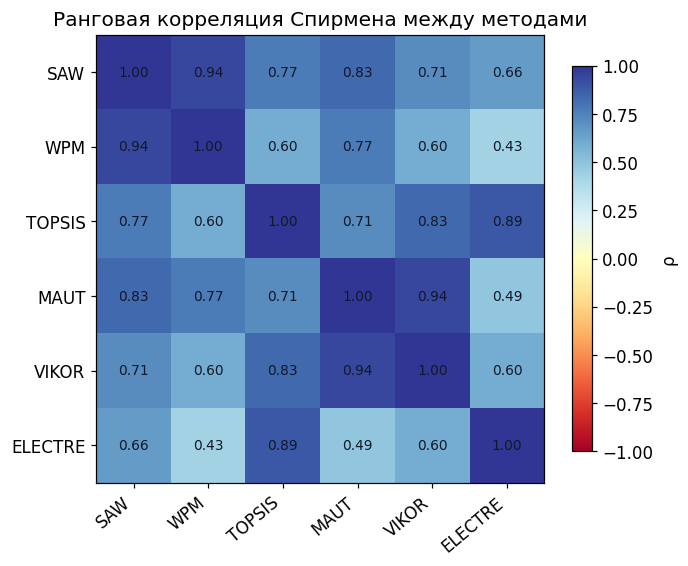

In [18]:
# =============================================================================
# Тепловая карта согласованности методов
# -----------------------------------------------------------------------------
# Синие клетки — методы согласны (ρ близко к 1), красные — противоречат
# друг другу (ρ близко к -1). Диагональ всегда равна 1.
# =============================================================================
fig, ax = plt.subplots(figsize=(6.4, 5.4))
# imshow рисует таблицу чисел как картинку: каждое число — цветная клетка.
# cmap — палитра, vmin/vmax — какие значения соответствуют крайним цветам.
im = ax.imshow(corr.values, cmap="RdYlBu", vmin=-1, vmax=1)
ax.set_xticks(range(len(methods)))
ax.set_xticklabels(methods, rotation=40, ha="right")
ax.set_yticks(range(len(methods)))
ax.set_yticklabels(methods)
for i in range(len(methods)):            # подписываем число в каждой клетке
    for j in range(len(methods)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center",
                fontsize=9, color="#111827")
ax.set_title("Ранговая корреляция Спирмена между методами")
ax.grid(False)                           # сетка поверх клеток только мешает
fig.colorbar(im, ax=ax, shrink=0.8, label="ρ")   # шкала цветов справа
plt.tight_layout()
plt.show()

**Как читать тепловую карту.** Каждая клетка — $\rho$ для пары методов, диагональ равна 1.
Тёмно-синие клетки — методы почти согласны, светлые — расходятся. Красных клеток нет:
отрицательной корреляции (когда один метод ставит наверх то, что другой ставит вниз)
здесь не бывает. Такая картина типична: методы MCDA чаще спорят о порядке «хороших»
альтернатив, чем о том, какие альтернативы плохи.

---
# §10. Анализ чувствительности

## Теория

### Зачем

Веса — самая субъективная часть модели. ЛПР сказал «вес риска $0{,}40$», но с тем же успехом
мог сказать $0{,}35$ или $0{,}45$. Если при таком небольшом изменении лучшая альтернатива
меняется, решению нельзя доверять без дополнительного обсуждения с ЛПР. **Анализ
чувствительности** отвечает на вопрос: насколько должны измениться веса, чтобы изменился
ответ?

### Однофакторный анализ: критический вес

Меняем вес одного критерия $w_k=t$, а остальные веса масштабируем так, чтобы их доли
между собой сохранились, а сумма всех весов осталась равной 1:

$$
w_j(t)=w_j^0\cdot\frac{1-t}{1-w_k^0},\qquad j\ne k. \qquad\qquad (10.1)
$$

Для SAW балл каждой альтернативы — линейная функция от $t$, и точку, где две альтернативы
сравниваются, можно найти, решив уравнение $F_a(t)=F_b(t)$. Такая точка называется
**критическим весом**. Расстояние от текущего веса до ближайшего критического — **запас
устойчивости** решения.

> **Разобранный пример 10.1** (выбор курса повышения квалификации, критический вес $w^*=0{,}556$)
> с графиком — в ноутбуке-спутнике `MCDA_Methods_Examples.ipynb`.

### Многофакторный анализ: метод Монте-Карло

Однофакторный анализ меняет один вес. Чтобы проверить устойчивость к **одновременному**
изменению всех весов, делают так:

1. генерируют много (тысячи) случайных наборов весов «вокруг» исходного;
2. для каждого набора решают задачу;
3. считают, в какой доле наборов победила каждая альтернатива.

Случайные веса удобно брать из **распределения Дирихле** с параметрами
$\alpha_j=\kappa\,w_j^0$: оно выдаёт наборы неотрицательных чисел с суммой 1, в среднем
равные $w^0$. Параметр **концентрации** $\kappa$ управляет разбросом: дисперсия веса
примерно равна $\dfrac{w_j(1-w_j)}{\kappa+1}$. Например, при $\kappa=40$ вес $0{,}30$ колеблется
со стандартным отклонением $\sqrt{0{,}30\cdot 0{,}70/41}\approx 0{,}07$, то есть в основном
между $0{,}16$ и $0{,}44$.

**Правило интерпретации (условное):** если лидер побеждает в 70 % розыгрышей и больше, выбор
устойчив; если меньше — альтернативы находятся в зоне безразличия.

> **Типичная ошибка.** Сделать анализ чувствительности только для одного, «удобного» критерия.
> Проверять нужно тот критерий, вес которого ЛПР назвал с наибольшим сомнением, — или все
> сразу методом Монте-Карло.

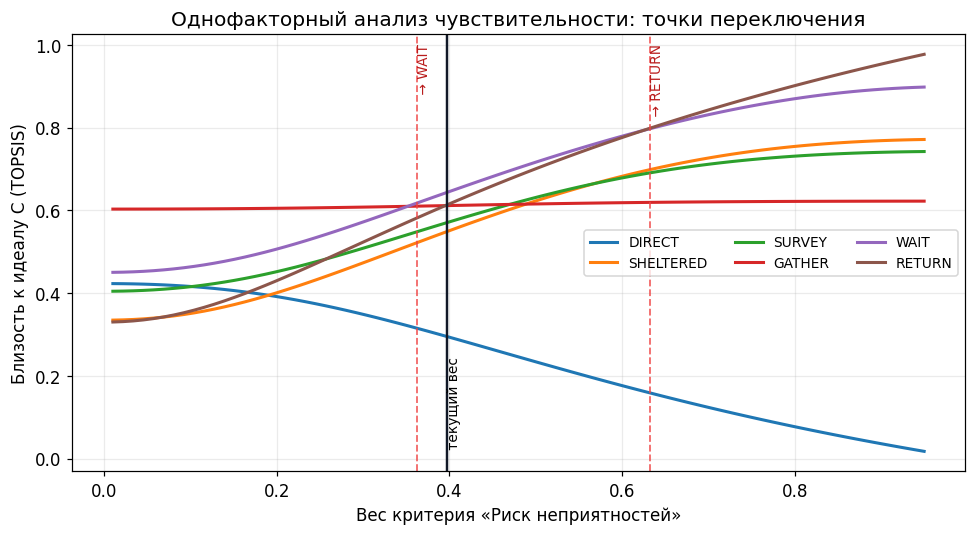

Точки переключения лидера: w_risk=0.362 → WAIT, w_risk=0.633 → RETURN


In [19]:
# =============================================================================
# §10.1. ОДНОФАКТОРНЫЙ АНАЛИЗ ЧУВСТВИТЕЛЬНОСТИ
# -----------------------------------------------------------------------------
# Плавно меняем вес одного критерия и смотрим, в какой момент меняется
# лучший вариант. Остальные веса при этом масштабируются пропорционально,
# чтобы сумма всех весов оставалась равной 1 (формула 10.1).
# =============================================================================

def weight_sweep(X: pd.DataFrame, w0: pd.Series, crit: str,
                 method=topsis, n: int = 81) -> pd.DataFrame:
    """Баллы всех альтернатив при весе критерия crit от 0.01 до 0.95.

    Строка результата — одно значение веса, столбцы — альтернативы.
    Параметр method=topsis: функцию можно передать как аргумент, как число.
    """
    others = [c for c in w0.index if c != crit]          # все, кроме crit
    # Доли остальных критериев между собой. Они сохраняются при любом весе
    # crit: если «время» было вдвое важнее «знания местности», так и останется.
    base_rest = w0[others] / w0[others].sum()
    # np.linspace(a, b, n) — n равномерно расставленных чисел от a до b.
    grid = np.linspace(0.01, 0.95, n)
    rows = []
    for wc in grid:
        # Вес crit = wc; остальным достаётся (1 - wc), поделённая в прежних
        # пропорциях. ** перед словарём «распаковывает» его внутрь нового
        # словаря; .to_dict() превращает Series в обычный словарь.
        w = pd.Series({crit: wc, **(base_rest * (1 - wc)).to_dict()})[w0.index]
        rows.append(method(X, w).reindex(X.index))       # баллы при этом весе
    return pd.DataFrame(rows, index=grid)


sweep = weight_sweep(X_demo, w_demo, "risk")   # исследуем вес риска

fig, ax = plt.subplots(figsize=(9, 5))
palette = plt.cm.tab10(np.linspace(0, 1, 10))  # 10 различимых цветов
for k, a in enumerate(STRATEGIES):
    ax.plot(sweep.index, sweep[a], lw=2, label=a, color=palette[k])

# .idxmax(axis=1) — для каждой строки имя столбца с максимумом: лидер при
# каждом значении веса.
leader = sweep.idxmax(axis=1)
# Точки переключения: номера i, где лидер отличается от предыдущего.
switch = [(sweep.index[i], leader.iloc[i]) for i in range(1, len(leader))
          if leader.iloc[i] != leader.iloc[i - 1]]
for xw, new in switch:                           # красные пунктиры — переключения
    ax.axvline(xw, color="#ef4444", ls="--", lw=1.2, alpha=0.8)   # вертикальная линия
    ax.text(xw, ax.get_ylim()[1] * 0.98, f" → {new}", rotation=90,
            va="top", fontsize=9, color="#b91c1c")

ax.axvline(w_demo["risk"], color="#111827", lw=1.6)   # где мы находимся сейчас
ax.text(w_demo["risk"], 0.02, " текущий вес", rotation=90, fontsize=9)
ax.set_xlabel("Вес критерия «Риск неприятностей»")
ax.set_ylabel("Близость к идеалу C (TOPSIS)")
ax.set_title("Однофакторный анализ чувствительности: точки переключения")
ax.legend(ncol=3, fontsize=9)                    # легенда в три колонки
plt.tight_layout()
plt.show()

# ", ".join(...) склеивает описания через запятую; «or» подставит текст
# «нет», если список переключений пуст.
print("Точки переключения лидера:",
      ", ".join(f"w_risk={x:.3f} → {a}" for x, a in switch) or "нет (выбор устойчив)")

### Что получилось

Меняя вес риска от $0{,}01$ до $0{,}95$ (метод TOPSIS), получаем три зоны:

| Вес риска | Лидер | Смысл |
|---|---|---|
| меньше $0{,}362$ | GATHER | риск не пугает — важнее восстановить запасы |
| $0{,}362\ldots 0{,}633$ | **WAIT** | осторожность и восстановление в укрытии |
| больше $0{,}633$ | RETURN | безопасность любой ценой |

Текущий вес риска $0{,}397$ (чёрная линия) лежит в зоне WAIT, но всего в $0{,}035$ от границы
с GATHER. Это относительное изменение меньше 10 %: решение **хрупкое**.

Такая картина осмысленна: чем осторожнее путешественник, тем скромнее его планы — от «пополнить
запасы» к «переждать под навесом» и далее к «вернуться назад».

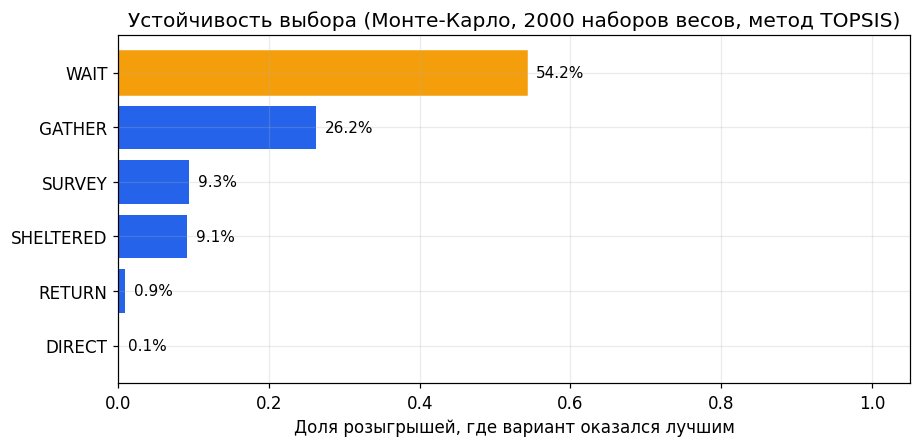

Вариант WAIT побеждает в 54.2% случаев → выбор НЕустойчив, зона безразличия


In [20]:
# =============================================================================
# §10.2. МОНТЕ-КАРЛО: УСТОЙЧИВОСТЬ ВЫБОРА К ИЗМЕНЕНИЮ ВСЕХ ВЕСОВ СРАЗУ
# -----------------------------------------------------------------------------
# Генерируем много случайных наборов весов «вокруг» исходных и считаем,
# как часто каждый вариант оказывается лучшим. Наборы берутся из
# распределения Дирихле: оно выдаёт наборы неотрицательных чисел
# с суммой 1 — ровно то, чем должны быть веса.
# =============================================================================

def monte_carlo_stability(X: pd.DataFrame, w0: pd.Series, method=topsis,
                          n_iter: int = 2000, concentration: float = 40.0,
                          rng=RNG) -> pd.Series:
    """Доля розыгрышей, в которых каждая альтернатива стала лучшей.

    concentration (κ) управляет разбросом: при α = κ · w0 среднее
    случайных весов равно w0, а дисперсия примерно w(1 - w)/(κ + 1).
    Большое κ — веса почти не меняются; малое — меняются сильно.
    """
    alpha = np.asarray(w0.values, dtype=float) * concentration   # параметры Дирихле
    wins = {a: 0 for a in X.index}                  # счётчик побед, сначала нули
    # for _ in range(n): повторить n раз; переменная цикла не нужна, поэтому _.
    for _ in range(n_iter):
        w = pd.Series(rng.dirichlet(alpha), index=w0.index)   # случайные веса
        # += 1 — увеличить значение на единицу (то же, что x = x + 1).
        wins[method(X, w).idxmax()] += 1            # кто победил при них
    # Делим число побед на число розыгрышей — получаем доли.
    return (pd.Series(wins) / n_iter).sort_values(ascending=False)


stab = monte_carlo_stability(X_demo, w_demo, n_iter=2000)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
# barh — горизонтальные столбики. [::-1] — список в обратном порядке,
# чтобы лидер оказался наверху.
bars = ax.barh(stab.index[::-1], stab.values[::-1], color="#2563eb")
bars[-1].set_color("#f59e0b")                       # [-1] — последний элемент: лидер
for i, v in enumerate(stab.values[::-1]):
    if v > 0.001:
        # :.1% — вывести долю как процент с одним знаком: 0.542 -> 54.2%
        ax.text(v + 0.012, i, f"{v:.1%}", va="center", fontsize=10)
ax.set_xlim(0, 1.05)
ax.set_xlabel("Доля розыгрышей, где вариант оказался лучшим")
ax.set_title("Устойчивость выбора (Монте-Карло, 2000 наборов весов, метод TOPSIS)")
plt.tight_layout()
plt.show()

# Порог 70 % — условное правило: если лидер выигрывает реже, решение
# зависит от мелких деталей весов, и ЛПР стоит уточнить предпочтения.
print(f"Вариант {stab.index[0]} побеждает в {stab.iloc[0]:.1%} случаев "
      f"→ выбор {'устойчив' if stab.iloc[0] > 0.7 else 'НЕустойчив, зона безразличия'}")

### Что получилось

При случайном «встряхивании» всех весов сразу WAIT побеждает лишь в 54 % розыгрышей —
ниже порога 70 %. Главный соперник — GATHER (26 %), тот же сосед, что и в однофакторном
анализе; ещё по 9 % достаются SURVEY и SHELTERED. RETURN побеждает лишь в 1 % розыгрышей:
чтобы до него дошло, вес риска должен вырасти очень сильно, а случайные колебания весов
так далеко почти не заходят.

**Три независимых подтверждения одного вывода:** близкие баллы в §3–§5, компромиссное
множество VIKOR из четырёх стратегий в §7 и 54 % в Монте-Карло. В демонстрационном
состоянии выбор между WAIT и GATHER **неустойчив**. Для игрового агента это
не проблема, а подсказка: здесь нужно поведение с долей случайности, а не жёсткий выбор.

---
# §11. От одного решения к политике $\pi: S\to A$

## Что такое политика

Всё, что мы делали в §2–§10, относилось к **одному** состоянию. Но агент попадает в самые разные
ситуации, и для каждой нужен ответ. **Политика** — это правило, которое каждому состоянию
ставит в соответствие действие:

$$
\pi(s)=\arg\max_{a\in A} F\big(X(s),\,w(s)\big)_a .
$$

Поскольку состояний конечное число (243), политику можно просто **вычислить заранее**
и записать в таблицу. Это называется **табличной политикой**. В игре агенту не нужно ничего
считать: он определяет, в каком состоянии находится, и читает ответ из таблицы.

## Алгоритм

Для каждого из 243 состояний:

1. восстановить числовые значения переменных по индексам уровней (§1.1);
2. построить матрицу решений $X(s)$ (§1.3);
3. вычислить адаптивные веса $w(s)$ по формуле (1.1);
4. применить выбранный метод (SAW, WPM, TOPSIS или MAUT) и получить баллы шести стратегий;
5. записать лидера, второе место и **запас превосходства**
   $\text{margin}=F(a^{(1)})-F(a^{(2)})$.

VIKOR и ELECTRE в политике не участвуют: первый выдаёт множество, второй — граф, а таблице
нужен однозначный балл каждой стратегии.

## Неоднозначные состояния

Если margin меньше порога ($0{,}015$), лидер выбран «на волоске» — ровно та ситуация, которую
§9–§10 показали для демонстрационного состояния. Такие записи помечаются флагом
`ambiguous`. В игре NPC выберет в них стратегию **случайно**, с вероятностями по правилу
softmax:

$$
P(a_i)=\frac{\exp\!\big(F(a_i)/\tau\big)}{\sum_k \exp\!\big(F(a_k)/\tau\big)},
$$

где $\tau$ — «температура» ($0{,}04$): чем она меньше, тем чаще выбирается лидер. Так поведение
становится живым и непредсказуемым, но не бессмысленным: плохие стратегии почти никогда
не выбираются.

In [21]:
# =============================================================================
# §11. ПОСТРОЕНИЕ ПОЛИТИКИ π(s): ПЕРЕБОР ВСЕХ 243 СИТУАЦИЙ
# -----------------------------------------------------------------------------
# Для каждой ситуации повторяем всё, что делали для одной s_demo:
# матрица решений -> адаптивные веса -> метод MCDA -> лучший вариант.
# =============================================================================

# Методы, которые выдают числовой балл каждому варианту. VIKOR и ELECTRE
# сюда не входят: первый выдаёт компромиссное МНОЖЕСТВО, второй — граф,
# а для таблицы политики нужен однозначный балл.
# Значения словаря — сами функции (без скобок: мы их не вызываем, а храним).
METHOD_REGISTRY = {
    "SAW": saw, "WPM": wpm, "TOPSIS": topsis, "MAUT": maut,
}


def build_policy(method_name: str = "TOPSIS", w0: pd.Series = W_BASE,
                 adaptive: bool = True,
                 ambiguity_threshold: float = 0.015) -> pd.DataFrame:
    """Таблица политики: одна строка на ситуацию, индекс — ключ '0|2|2|1|1'."""
    method = METHOD_REGISTRY[method_name]      # достаём функцию по названию
    records = []                               # сюда соберём 243 записи
    for idx in itertools.product(range(3), repeat=len(STATE_VARS)):
        s = state_from_bins(idx)                          # числа ситуации
        X = decision_matrix(s)                            # X(s), форма (6, 5)
        w = adaptive_weights(s, w0, enabled=adaptive)     # w(s), формула (1.1)
        sc = method(X, w).reindex(STRATEGIES)             # баллы в порядке STRATEGIES
        order = sc.sort_values(ascending=False)           # от лучшего к худшему

        # Запас превосходства: насколько лидер опережает второго. Малый
        # margin — лидер выбран «на волоске», и в Unity такая ситуация
        # помечается как неоднозначная (выбор там будет вероятностным).
        margin = float(order.iloc[0] - order.iloc[1])

        # Запись о ситуации — словарь. Метод .update(...) добавляет в него
        # пары из другого словаря.
        rec = {"key": state_key(idx)}
        rec.update({v: i for v, i in zip(STATE_VARS, idx)})   # индексы уровней
        rec["strategy"]  = order.index[0]                 # π(s) — главный результат
        rec["runner_up"] = order.index[1]                 # второе место
        rec["margin"]    = margin
        rec["ambiguous"] = margin < ambiguity_threshold   # True / False
        # Баллы ВСЕХ вариантов — нужны Unity для вероятностного выбора.
        rec.update({f"score_{a}": float(sc[a]) for a in STRATEGIES})
        records.append(rec)
    # Список словарей превращается в таблицу: каждый словарь — строка.
    # .set_index("key") делает ключ ситуации подписью строки.
    return pd.DataFrame(records).set_index("key")


policy = build_policy("TOPSIS", W_BASE, adaptive=True)
print(f"Построена политика для {len(policy)} ситуаций методом TOPSIS\n")

# .value_counts() — сколько раз встречается каждое значение столбца.
# .fillna(0) — заменить пропуски (вариант не встретился ни разу) нулями.
dist = policy["strategy"].value_counts().reindex(STRATEGIES).fillna(0).astype(int)
summary = pd.DataFrame({
    "ситуаций": dist,
    # .map(функция) применяет функцию к каждому элементу.
    # lambda v: ... — короткая безымянная функция в одну строку.
    "доля": (dist / len(policy)).map(lambda v: f"{v:.1%}"),
    # .groupby("strategy")["margin"].mean() — средний margin по каждому варианту.
    "средний margin": (policy.groupby("strategy")["margin"].mean()
                       .reindex(STRATEGIES).round(3)),
})
display(summary)
print(f"Неоднозначных ситуаций (margin < 0.015): {policy['ambiguous'].sum()} "
      f"({policy['ambiguous'].mean():.1%}) — в них выбор делается с долей случайности")

Построена политика для 243 ситуаций методом TOPSIS



,ситуаций,доля,средний margin
strategy,,,
DIRECT,46,18.9%,0.080
SHELTERED,66,27.2%,0.072
SURVEY,66,27.2%,0.031
GATHER,26,10.7%,0.020
WAIT,23,9.5%,0.020
RETURN,16,6.6%,0.029


Неоднозначных ситуаций (margin < 0.015): 64 (26.3%) — в них выбор делается с долей случайности


### Что получилось

Политика задействует **все шесть вариантов действий** — значит, модель не вырождена:

* SHELTERED и SURVEY — по 27 % состояний, самые частые;
* DIRECT — 19 %: там, где погода ясная или приют близко;
* GATHER, WAIT, RETURN — от 7 до 11 %: «особые» варианты для трудных ситуаций.

Средний margin различается: у DIRECT и SHELTERED он около $0{,}07\ldots 0{,}08$ — если путешественник
решил идти, он уверен в решении. У GATHER и WAIT — $0{,}02$: эти стратегии побеждают с небольшим
отрывом. Почти каждое четвёртое состояние (26 %) неоднозначно.

> **Проверка качества политики.** Если какая-то стратегия не выбирается ни в одном состоянии,
> часть модели «мёртвая»: в игре вы эту стратегию никогда не увидите. Правьте веса или функции
> оценивания, пока не задействуется хотя бы пять стратегий из шести.

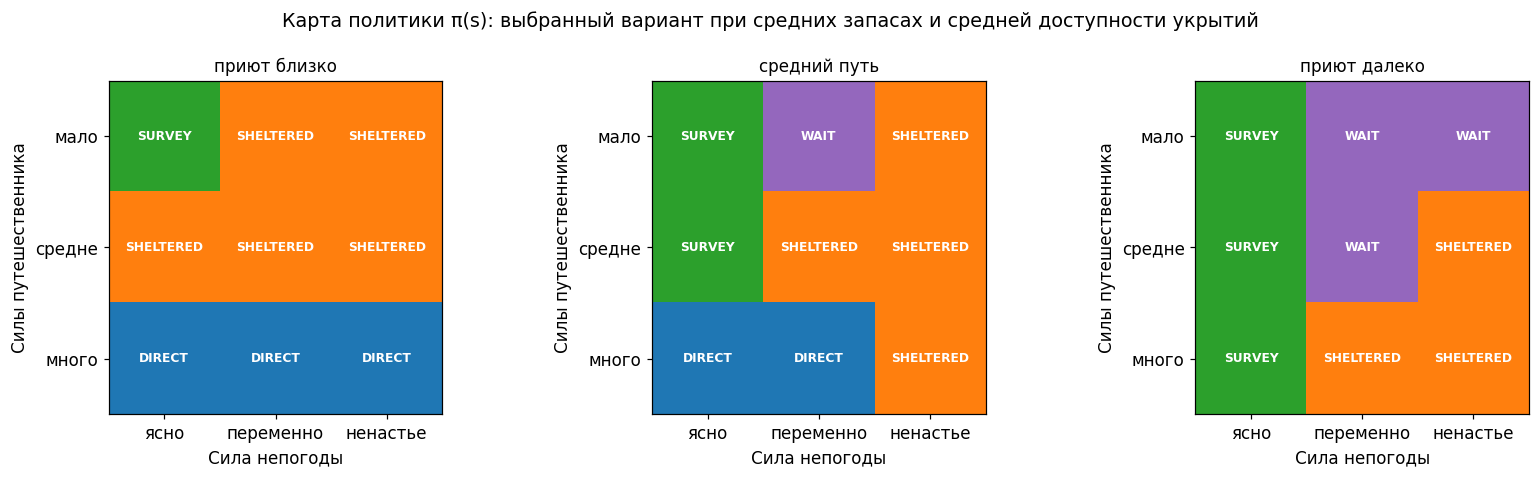

In [22]:
# =============================================================================
# Карта политики: какой вариант выбран при разных силах и погоде
# -----------------------------------------------------------------------------
# Ситуация пятимерная, а рисунок двумерный, поэтому три переменные
# фиксируем (запасы и укрытия — средние, расстояние — своё на каждой панели),
# а по осям откладываем силы и непогоду.
# =============================================================================

def policy_heatmap(policy: pd.DataFrame, row_var: str, col_var: str,
                   fixed: Dict[str, int], ax=None):
    """Срез таблицы политики 3 × 3 по двум переменным при фиксированных остальных."""
    sub = policy.copy()                        # копия, чтобы не испортить оригинал
    for v, i in fixed.items():
        # Фильтрация строк: sub[v] == i даёт маску, sub[маска] оставляет
        # только строки, где переменная v находится на уровне i.
        sub = sub[sub[v] == i]
    grid = np.full((3, 3), -1, dtype=int)      # таблица 3×3 из -1 («нет данных»)
    # .iterrows() перебирает строки таблицы: (подпись, строка).
    for _, r in sub.iterrows():
        # STRATEGIES.index(имя) — номер варианта в списке (для цвета).
        grid[int(r[row_var]), int(r[col_var])] = STRATEGIES.index(r["strategy"])

    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))
    # Каждому варианту — свой цвет из палитры tab10.
    cmap = matplotlib.colors.ListedColormap(plt.cm.tab10(np.arange(len(STRATEGIES))))
    ax.imshow(grid, cmap=cmap, vmin=0, vmax=len(STRATEGIES) - 1)
    for i in range(3):
        for j in range(3):
            if grid[i, j] >= 0:
                ax.text(j, i, STRATEGIES[grid[i, j]], ha="center", va="center",
                        fontsize=8, fontweight="bold", color="white")
    ax.set_yticks(range(3))
    ax.set_yticklabels(BIN_NAMES[row_var])
    ax.set_xticks(range(3))
    ax.set_xticklabels(BIN_NAMES[col_var])
    ax.set_ylabel(STATE_LABELS[row_var])
    ax.set_xlabel(STATE_LABELS[col_var])
    ax.grid(False)
    return ax


# Три панели в ряд: plt.subplots(1, 3) — одна строка, три колонки осей.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, dist_bin, title in zip(axes, [0, 1, 2],
                               ["приют близко", "средний путь", "приют далеко"]):
    policy_heatmap(policy, "energy", "weather",
                   fixed={"dist": dist_bin, "supplies": 1, "shelter": 1}, ax=ax)
    ax.set_title(title, fontsize=11)
fig.suptitle("Карта политики π(s): выбранный вариант при средних запасах "
             "и средней доступности укрытий", fontsize=12.5)
plt.tight_layout()
plt.show()

**Как читать карты.** Каждая панель — срез политики 3×3: по вертикали силы, по горизонтали
непогода; запасы и укрытия зафиксированы на среднем уровне; панели отличаются расстоянием
до приюта. В клетке — вариант, который выбирает путешественник.

Сверьте карту с ожиданиями здравого смысла — совпадают ли они с вашей политикой?

* уставший путешественник в ненастье пережидает или возвращается;
* бодрый путешественник вблизи приюта идёт напрямик;
* вдалеке от приюта в ясную погоду выгоднее осмотреться и идти защищённой тропой.

Если карта противоречит замыслу геймдизайнера, правится **не код Unity**, а веса и функции
оценивания в этом ноутбуке. В этом и состоит «поддержка принятия решений»: модель
предпочтений отделена от исполнительного механизма.

## 11.1. Как метод агрегирования меняет характер путешественника

Построим четыре политики с **одинаковыми** весами, но разными методами. Если бы метод не
имел значения, политики совпали бы.

Число ситуаций, в которых выбран вариант (из 243):


,SAW,WPM,TOPSIS,MAUT
strategy,,,,
DIRECT,14,4,46,12
SHELTERED,30,86,66,27
SURVEY,143,141,66,131
GATHER,1,1,26,67
WAIT,14,11,23,5
RETURN,41,0,16,1


Доля ситуаций, где метод согласен с TOPSIS:


,совпадение
SAW,52.3%
WPM,58.0%
TOPSIS,100.0%
MAUT,36.6%


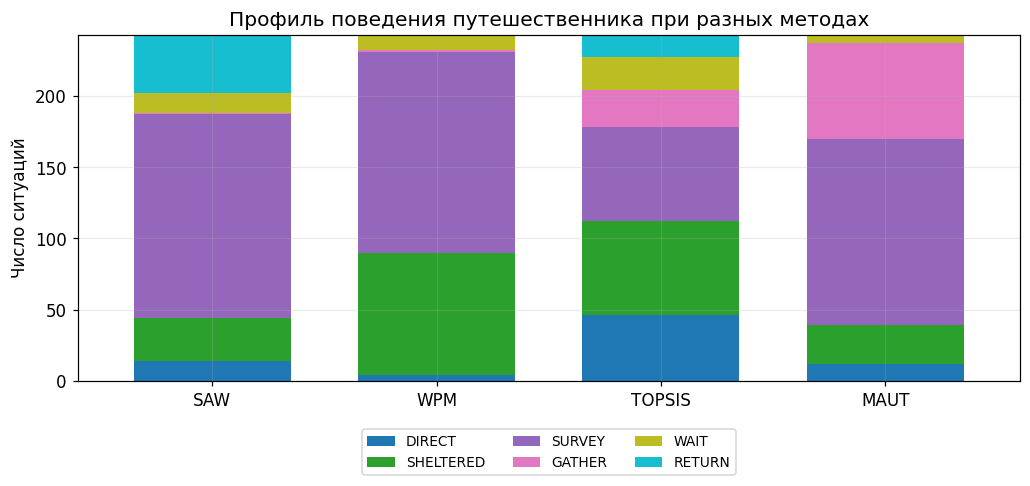

In [23]:
# =============================================================================
# §11.1. КАК МЕТОД АГРЕГИРОВАНИЯ МЕНЯЕТ ХАРАКТЕР ПУТЕШЕСТВЕННИКА
# -----------------------------------------------------------------------------
# Строим четыре политики с одинаковыми весами, но разными методами,
# и сравниваем, как часто в них выбирается каждый вариант.
# =============================================================================

# Генератор словаря: для каждого названия метода строим свою политику.
pol_variants = {m: build_policy(m, W_BASE, adaptive=True) for m in METHOD_REGISTRY}

# Таблица «вариант × метод»: число ситуаций, где вариант выбран.
cmp_tab = pd.DataFrame({
    m: p["strategy"].value_counts().reindex(STRATEGIES).fillna(0).astype(int)
    for m, p in pol_variants.items()})
print("Число ситуаций, в которых выбран вариант (из 243):")
display(cmp_tab)

# Доля ситуаций, где метод выбрал тот же вариант, что и TOPSIS.
# (p["strategy"] == base) — маска совпадений; .mean() от True/False —
# доля True (True считается как 1, False как 0).
base = pol_variants["TOPSIS"]["strategy"]
agree = pd.Series({m: float((p["strategy"] == base).mean())
                   for m, p in pol_variants.items()})
print("Доля ситуаций, где метод согласен с TOPSIS:")
display(agree.map(lambda v: f"{v:.1%}").to_frame("совпадение"))

fig, ax = plt.subplots(figsize=(9.5, 4.6))
# .T — транспонировать: методы по оси X; stacked=True — столбики друг на друге.
cmp_tab.T.plot(kind="bar", stacked=True, ax=ax, colormap="tab10", width=0.7)
ax.set_ylabel("Число ситуаций")
ax.set_xlabel("")
ax.set_title("Профиль поведения путешественника при разных методах")
ax.legend(ncol=3, fontsize=9, loc="upper center", bbox_to_anchor=(0.5, -0.12))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Что получилось

Методы порождают **разных путешественников**, хотя веса одинаковы:

| Метод | Характер путешественника |
|---|---|
| TOPSIS | самый разнообразный: все шесть вариантов в заметных долях |
| SAW | «любознательный»: SURVEY в 143 ситуациях из 243; часто возвращается (41) |
| WPM | «любознательный осторожный»: SURVEY и SHELTERED почти всегда, RETURN никогда |
| MAUT | «любознательный хозяйственник»: SURVEY и GATHER (67 ситуаций) |

С TOPSIS совпадают лишь 37–58 % решений других методов. Объяснение — в теории §3–§6:

* SAW полностью компенсаторен, а у SURVEY есть сразу два выдающихся критерия (информация и
  время), которые «выкупают» слабое продвижение;
* WPM наказывает провалы: у RETURN продвижение и информация — всего несколько процентов от лучших значений, и он не выигрывает ни разу;
* MAUT вогнутой полезностью сглаживает разницу по риску, и на первый план выходит
  восстановление — сильная сторона GATHER.

**Вывод.** Выбор метода агрегирования — не техническая деталь, а решение о характере персонажа,
такое же важное, как выбор весов.

---
# §12. Экспорт политики в Unity: `policy.json`

Формат спроектирован так, чтобы C#-сторона была максимально простой: один
`Dictionary<string, Entry>`, ключ — строка из индексов бинов.

```
policy.json
├── schema_version, generated_at, method
├── criteria[]       — имена, направления, веса
├── strategies[]     — коды стратегий (порядок фиксирован!)
├── state_bins{}     — границы дискретизации, чтобы Unity умел кодировать своё состояние
└── entries{}        — "energy|dist|weather|supplies|shelter" → { strategy, scores[], margin, ambiguous }
```

In [24]:
# =============================================================================
# §12. ЭКСПОРТ ПОЛИТИКИ ДЛЯ UNITY
# -----------------------------------------------------------------------------
# Политика — это таблица на 243 строки. Сохраняем её в двух видах:
#   policy.json       — подробный, со словарём: удобно читать глазами и в Python;
#   policy_unity.json — «плоский», только массивы: его без сторонних библиотек
#                       читает стандартный UnityEngine.JsonUtility.
# =============================================================================
import os             # os — работа с файлами и папками операционной системы
OUT_DIR = "unity_export"   # путь относительно рабочей папки ядра — в VS Code
                           # это папка, где лежит ноутбук
os.makedirs(OUT_DIR, exist_ok=True)       # создать папку; exist_ok=True — не
                                          # ругаться, если она уже есть
# os.path.abspath — полный путь к папке: по нему файлы легко найти в проводнике.
print("Папка экспорта:", os.path.abspath(OUT_DIR))


def bin_edges(values: List[float]) -> List[float]:
    """Границы между соседними бинами — середины между их значениями.

    Для energy: значения [0.25, 0.60, 0.95] -> границы [0.425, 0.775].
    Unity по этим границам определяет, в какой бин попали ТЕКУЩИЕ силы
    агента, — так в Unity не приходится дублировать числа из ноутбука.
    """
    return [round((values[i] + values[i + 1]) / 2, 4) for i in range(len(values) - 1)]


def export_policy(policy: pd.DataFrame, method_name: str, w0: pd.Series,
                  out_dir: str = OUT_DIR) -> dict:
    """Записывает policy.json и policy_unity.json; возвращает содержимое и пути."""
    entries_list = []   # для Unity: массив записей (JsonUtility не умеет словари)
    entries_dict = {}   # для людей: словарь «ключ -> запись»
    # .iterrows() перебирает строки таблицы: key — подпись строки, r — сама строка.
    for key, r in policy.iterrows():
        e = {
            "key": key,                                     # "0|2|2|1|1"
            "strategy": r["strategy"],                      # π(s)
            "runnerUp": r["runner_up"],
            "margin": round(float(r["margin"]), 5),
            "ambiguous": bool(r["ambiguous"]),
            # Баллы в порядке STRATEGIES — по этому порядку их читает Unity.
            "scores": [round(float(r[f"score_{a}"]), 5) for a in STRATEGIES],
        }
        entries_list.append(e)
        # Копия записи без поля "key" (ключ и так будет ключом словаря).
        entries_dict[key] = {k: v for k, v in e.items() if k != "key"}

    # Общие сведения: откуда политика, каким методом, что делать по умолчанию.
    meta = {
        "schemaVersion": "1.0",
        "generatedAt": datetime.datetime.now().isoformat(timespec="seconds"),
        "method": method_name,
        "course": "Математические и инструментальные методы поддержки принятия решений",
        "strategies": STRATEGIES,
        "stateVars": STATE_VARS,
        "fallback": "WAIT",               # если ключа нет в таблице — переждать
        "ambiguityThreshold": 0.015,
    }

    # dict(meta) — КОПИЯ словаря meta: дальше дополняем её, не трогая оригинал.
    full = dict(meta)
    full["criteria"] = [{"name": c, "label": CRIT_LABELS[c], "direction": DIRECTIONS[c],
                         "baseWeight": round(float(w0[c]), 6)} for c in CRITERIA]
    full["stateBins"] = {v: {"representatives": STATE_BINS[v],
                             "edges": bin_edges(STATE_BINS[v]),
                             "names": BIN_NAMES[v]} for v in STATE_VARS}
    full["entries"] = entries_dict

    unity = dict(meta)
    unity["criteria"] = [{"name": c, "direction": DIRECTIONS[c],
                          "baseWeight": round(float(w0[c]), 6)} for c in CRITERIA]
    # Ключ называется varName, а не var: var — зарезервированное слово C#,
    # и поле с таким именем в Unity просто не скомпилируется.
    unity["edges"] = [{"varName": v, "values": bin_edges(STATE_BINS[v])}
                      for v in STATE_VARS]
    unity["entries"] = entries_list

    p_full  = os.path.join(out_dir, "policy.json")
    p_unity = os.path.join(out_dir, "policy_unity.json")
    for path, obj in ((p_full, full), (p_unity, unity)):
        # with open(путь, "w") as f: — открыть файл на ЗАПИСЬ ("w" = write).
        # Конструкция with сама закроет файл, когда блок закончится.
        with open(path, "w", encoding="utf-8") as f:
            # ensure_ascii=False — русские подписи сохраняются читаемыми
            json.dump(obj, f, ensure_ascii=False, indent=1)
    return full, p_full, p_unity


payload, p_full, p_unity = export_policy(policy, "TOPSIS", W_BASE)

for p in (p_full, p_unity):
    # os.path.getsize — размер файла в байтах; / 1024 — в килобайтах.
    print(f"{os.path.basename(p):20s}  {os.path.getsize(p)/1024:7.1f} КБ")
print(f"\nСостояний в политике: {len(payload['entries'])}\n")
print("Фрагмент policy_unity.json (то, что читает Unity):")
# json.dumps превращает словарь в текст JSON (indent=1 — с отступами).
print(json.dumps({"strategies": STRATEGIES,
                  "edges": [{"varName": v, "values": bin_edges(STATE_BINS[v])}
                            for v in STATE_VARS],
                  "entries": [{"key": k, **payload["entries"][k]}
                              for k in list(payload["entries"])[:2]]},
                 ensure_ascii=False, indent=1))

# Та же таблица в CSV — для приложения к отчёту (откроется в Excel).
# utf-8-sig добавляет метку, по которой Excel правильно покажет кириллицу.
csv_path = os.path.join(OUT_DIR, "policy_table.csv")
policy.reset_index().to_csv(csv_path, index=False, encoding="utf-8-sig")
print(f"\nТаблица для отчёта: {csv_path}")

Папка экспорта: unity_export


policy.json              52.8 КБ
policy_unity.json        54.4 КБ

Состояний в политике: 243

Фрагмент policy_unity.json (то, что читает Unity):
{
 "strategies": [
  "DIRECT",
  "SHELTERED",
  "SURVEY",
  "GATHER",
  "WAIT",
  "RETURN"
 ],
 "edges": [
  {
   "varName": "energy",
   "values": [
    0.425,
    0.775
   ]
  },
  {
   "varName": "dist",
   "values": [
    0.35,
    0.675
   ]
  },
  {
   "varName": "weather",
   "values": [
    0.3,
    0.7
   ]
  },
  {
   "varName": "supplies",
   "values": [
    0.4,
    0.8
   ]
  },
  {
   "varName": "shelter",
   "values": [
    0.35,
    0.65
   ]
  }
 ],
 "entries": [
  {
   "key": "0|0|0|0|0",
   "strategy": "SURVEY",
   "runnerUp": "GATHER",
   "margin": 0.00719,
   "ambiguous": true,
   "scores": [
    0.37455,
    0.48216,
    0.63333,
    0.62615,
    0.58261,
    0.55258
   ]
  },
  {
   "key": "0|0|0|0|1",
   "strategy": "SURVEY",
   "runnerUp": "GATHER",
   "margin": 0.01383,
   "ambiguous": true,
   "scores": [
    0.36014

## 12.1. C#-загрузчик для Unity

Файл `policy_unity.json` содержит только массивы, поэтому читается штатным
`UnityEngine.JsonUtility` — никаких сторонних JSON-библиотек не требуется.
Скрипты кладутся в `Assets/Scripts/Decision/`, файл политики — в `Assets/Resources/`
или в `StreamingAssets`.

**`PolicyModel.cs`** — контейнеры данных:

```csharp
using System;
using System.Collections.Generic;
using UnityEngine;

[Serializable] public class PolicyEntry {
    public string  key;          // "energy|dist|weather|supplies|shelter", например "0|2|2|1|1"
    public string  strategy;
    public string  runnerUp;
    public float   margin;
    public bool    ambiguous;
    public float[] scores;       // порядок соответствует strategies[]
}

[Serializable] public class EdgeSpec { public string varName; public float[] values; }

[Serializable] public class PolicyFile {
    public string       schemaVersion;
    public string       method;
    public string[]     strategies;
    public string[]     stateVars;
    public string       fallback;
    public EdgeSpec[]   edges;
    public PolicyEntry[] entries;
}
```

**`DecisionPolicy.cs`** — загрузка и запрос:

```csharp
public class DecisionPolicy : MonoBehaviour {
    [SerializeField] private TextAsset policyAsset;              // policy_unity.json
    [SerializeField] private bool  stochasticWhenAmbiguous = true;
    [SerializeField] private float softmaxTemperature      = 0.04f;

    private PolicyFile _file;
    private readonly Dictionary<string, PolicyEntry> _index = new();
    private readonly Dictionary<string, float[]>     _edges = new();

    void Awake() {
        _file = JsonUtility.FromJson<PolicyFile>(policyAsset.text);
        foreach (var e in _file.entries) _index[e.key] = e;
        foreach (var e in _file.edges)   _edges[e.varName] = e.values;
        Debug.Log($"[DecisionPolicy] {_index.Count} состояний, метод {_file.method}");
    }

    private int Bin(string varName, float value) {
        var e = _edges[varName];
        int i = 0;
        while (i < e.Length && value >= e[i]) i++;
        return i;                                   // 0, 1 или 2
    }

    public string Decide(float energy, float dist, float weather, float supplies, float shelter,
                         out PolicyEntry entry) {
        float[] v = { energy, dist, weather, supplies, shelter };
        var parts = new string[_file.stateVars.Length];
        for (int i = 0; i < parts.Length; i++)
            parts[i] = Bin(_file.stateVars[i], Mathf.Clamp01(v[i])).ToString();

        string key = string.Join("|", parts);
        if (!_index.TryGetValue(key, out entry)) {
            Debug.LogWarning($"[DecisionPolicy] нет записи {key} → fallback {_file.fallback}");
            return _file.fallback;
        }
        return (stochasticWhenAmbiguous && entry.ambiguous)
             ? SoftmaxSample(entry.scores)
             : entry.strategy;
    }

    private string SoftmaxSample(float[] scores) {
        float max = float.NegativeInfinity;
        foreach (var s in scores) max = Mathf.Max(max, s);
        var p = new float[scores.Length];
        float sum = 0f;
        for (int i = 0; i < scores.Length; i++) { p[i] = Mathf.Exp((scores[i]-max)/softmaxTemperature); sum += p[i]; }
        float r = UnityEngine.Random.value * sum, acc = 0f;
        for (int i = 0; i < p.Length; i++) { acc += p[i]; if (r <= acc) return _file.strategies[i]; }
        return _file.strategies[0];
    }
}
```

**`StrategyExecutor.cs`** — выполнение выбранного варианта действий (скелет для лабораторной работы):

```csharp
public class StrategyExecutor : MonoBehaviour {
    [SerializeField] private DecisionPolicy policy;
    [SerializeField] private AgentState     state;        // energy/dist/weather/supplies/shelter в [0,1]
    [SerializeField] private float replanInterval = 1.0f;
    [SerializeField] private float hysteresis     = 0.02f; // защита от «дрожания» на границе бинов

    private string _current = "WAIT";
    private float  _timer;

    void Update() {
        _timer -= Time.deltaTime;
        if (_timer <= 0f) {
            _timer = replanInterval;
            string next = policy.Decide(state.Energy01, state.Dist01, state.Weather01,
                                        state.Supplies01, state.Shelter01, out var entry);
            if (next != _current && entry.margin >= hysteresis) {
                Debug.Log($"[{name}] {_current} → {next} (margin {entry.margin:F3})");
                _current = next;
            }
        }
        Execute(_current);
    }

    void Execute(string strategy) {
        switch (strategy) {
            case "DIRECT":    WalkToHut(speed: 1.00f, preferShelter: false); break; // напрямик
            case "SHELTERED": WalkToHut(speed: 0.55f, preferShelter: true);  break; // защищённой тропой
            case "SURVEY":    ExploreUnknownArea();                          break; // осмотреться
            case "GATHER":    GoToNearestSpring();                           break; // пополнить запасы
            case "WAIT":      RestUnderShelter();                            break; // переждать
            case "RETURN":    WalkBackToCamp();                              break; // вернуться
        }
    }
    // Реализация низкоуровневых методов — задание лабораторной работы №3
}
```

> **Методический акцент.** `replanInterval` и `hysteresis` — самостоятельный предмет
> исследования: слишком частый пересмотр даёт «дёрганого» NPC, мечущегося между
> стратегиями на границе бинов; слишком редкий — неадаптивного. Это хорошая тема для
> мини-эксперимента в отчёте.

---
# §13. Проверка политики в мини-симуляторе

## Зачем

Политика выглядит разумной на карте, но хороша ли она **в деле**? Прежде чем переносить её
в игровой движок, проверим её в простом Python-симуляторе. Это даёт **числовые метрики**
и делает Unity-часть не «фокусом», а проверкой уже понятной модели.

## Как устроен симулятор

Эпизод — один поход: попытка путешественника дойти до приюта. На каждом шаге:

1. политика смотрит на ситуацию и выбирает вариант действий;
2. среда меняет состояние по **модели перехода**, согласованной с функциями оценивания:
   * расстояние до приюта уменьшается пропорционально $g_{\text{progress}}$;
   * с вероятностью, пропорциональной $g_{\text{risk}}$, случается неприятность (промок,
     поскользнулся, сбился с тропы), и путешественник теряет силы — тем больше, чем сильнее непогода;
   * силы и запасы восстанавливаются пропорционально $g_{\text{supply}}$, а вода и еда
     понемногу расходуются на каждом шаге;
   * непогода стихает, если осмотреться и найти обход, и сильнее застаёт того, кто идёт напрямик;
     к вечеру погода понемногу портится;
3. поход заканчивается **успехом** (дошёл до приюта), **изнеможением** (силы кончились,
   путешественника забирают спасатели) или **таймаутом** — стемнело (24 шага).

Раз неприятности случайны, один эпизод ничего не доказывает. Поэтому каждую политику прогоняем на
**500** эпизодах, и все политики получают **один и тот же** набор стартовых состояний — иначе
разница могла бы объясняться везением.

## Какие политики сравниваем

* `MCDA-TOPSIS`, `MCDA-SAW`, `MCDA-MAUT` — наши табличные политики из §11;
* `ALWAYS_DIRECT` — «торопыга», который всегда идёт напрямик;
* `RANDOM` — выбор наугад: нижняя граница, ниже которой разумная политика опускаться не должна.

In [25]:
# =============================================================================
# §13. МИНИ-СИМУЛЯТОР: ПРОВЕРКА ПОЛИТИКИ ДО ПЕРЕНОСА В UNITY
# -----------------------------------------------------------------------------
# Модель перехода «ситуация + выбранный вариант -> новая ситуация». Её
# эффекты согласованы с функциями оценивания: если g_progress большое,
# путешественник и правда приближается к приюту; если g_risk большое,
# неприятность (промок, продрог, сбился с пути) случается чаще.
# =============================================================================

# @dataclass — «декоратор»: он превращает класс в простую запись с полями.
# Класс — это описание нового типа данных. Здесь каждое поле — одна
# характеристика итога похода; после двоеточия указан тип поля.
@dataclass
class EpisodeResult:
    """Итог одного эпизода — одной попытки дойти до приюта."""
    success: bool         # дошёл до приюта
    exhausted: bool       # выбился из сил и сошёл с маршрута
    steps: int            # сколько шагов прошло
    final_energy: float   # силы на финише
    final_supplies: float # запасы на финише
    info_gained: float    # насколько хорошо изучил местность


MAX_STEPS = 24          # до темноты — 24 шага; не успел — эпизод окончен


def step_env(s: Dict[str, float], strategy: str, rng) -> Dict[str, float]:
    """Один шаг похода: применяем выбранный вариант к ситуации s."""
    g = EVALUATORS[strategy](s)      # оценки той же функции, что и в MCDA
    ns = dict(s)                     # новая ситуация — копия старой

    # Продвижение: расстояние уменьшается пропорционально g_progress.
    ns["dist"] = clip01(s["dist"] - 0.20 * g["progress"])
    if strategy == "RETURN":         # возвращение ОТДАЛЯЕТ от приюта
        ns["dist"] = clip01(s["dist"] + 0.08)

    # Неприятность — случайное событие: вероятность пропорциональна g_risk,
    # потеря сил — силе непогоды. rng.random() — случайное число из [0, 1):
    # условие выполняется с вероятностью g["risk"] * 0.85.
    if rng.random() < g["risk"] * 0.85:
        ns["energy"] = clip01(ns["energy"] - (0.12 + 0.20 * s["weather"]))
    # Проверяем, не выбился ли путешественник из сил, ДО отдыха.
    # <= — «меньше или равно».
    ns["exhausted"] = ns["energy"] <= 1e-9

    # Восстановление сил и расход/пополнение запасов.
    ns["energy"]   = clip01(ns["energy"] + 0.09 * g["supply"])
    ns["supplies"] = clip01(s["supplies"] - 0.07 + 0.22 * g["supply"])

    # Погода: осмотревшись, легче найти путь в обход непогоды; идя напрямик,
    # чаще попадаешь под дождь и ветер; защищённая тропа и возвращение
    # уводят от непогоды. Плюс к вечеру погода понемногу портится (+0.030).
    delta = (-0.16 * g["info"]
             + (0.14 if strategy == "DIRECT" else 0.0)
             - (0.10 if strategy in ("RETURN", "SHELTERED") else 0.0)
             + 0.030)
    # rng.normal(0, 0.07) — случайная добавка из нормального распределения
    # со средним 0 и разбросом 0.07: погода меняется непредсказуемо.
    ns["weather"] = clip01(s["weather"] + delta + rng.normal(0, 0.07))

    # Доступность укрытий — свойство местности, меняется при перемещении.
    ns["shelter"] = clip01(s["shelter"] + rng.normal(0, 0.10))
    return ns


def run_episode(policy_fn: Callable[[Dict[str, float]], str],
                s0: Dict[str, float], max_steps: int = MAX_STEPS,
                rng=None) -> EpisodeResult:
    """Прогоняет один поход: на каждом шаге политика выбирает вариант."""
    # «A or B»: если rng не передали (None), создаём новый генератор.
    rng = rng or np.random.default_rng()
    s = dict(s0)
    info = 0.0
    # range(1, max_steps + 1) — числа 1, 2, ..., max_steps.
    for t in range(1, max_steps + 1):
        a = policy_fn(s)                         # решение политики
        info += EVALUATORS[a](s)["info"]         # копим знание местности
        s = step_env(s, a, rng)                  # ответ среды
        # .pop("exhausted", False) — прочитать значение и удалить его из
        # словаря (если ключа нет — вернуть False).
        if s.pop("exhausted", False):
            # return внутри цикла сразу завершает функцию.
            return EpisodeResult(False, True, t, 0.0, s["supplies"], info)
        if s["dist"] <= 0.06:                    # дошёл до приюта
            return EpisodeResult(True, False, t, s["energy"], s["supplies"], info)
    # Цикл закончился, а до приюта не дошли: не успели до темноты.
    return EpisodeResult(False, False, max_steps, s["energy"], s["supplies"], info)


# --- Политики-кандидаты -------------------------------------------------------
def make_table_policy(policy_df: pd.DataFrame, stochastic: bool = True,
                      temp: float = 0.04):
    """Политика «по таблице» — ровно то, что будет делать Unity.

    1) непрерывная ситуация -> индексы уровней по границам bin_edges;
    2) индексы -> ключ '0|2|2|1|1' -> строка таблицы;
    3) если запись неоднозначна — случайный выбор по softmax баллов.
    Функция ВОЗВРАЩАЕТ ДРУГУЮ ФУНКЦИЮ (fn), которую потом можно вызывать.
    """
    edges = {v: bin_edges(STATE_BINS[v]) for v in STATE_VARS}

    # Функция внутри функции («вложенная»): видна только здесь.
    def to_bin(v, x):
        e = edges[v]
        i = 0
        # while — цикл «пока условие истинно»: считаем, сколько границ
        # уровня значение x уже перешагнуло.
        while i < len(e) and x >= e[i]:
            i += 1
        return i

    def fn(s):
        key = "|".join(str(to_bin(v, s[v])) for v in STATE_VARS)
        if key not in policy_df.index:
            return "WAIT"
        row = policy_df.loc[key]                 # строка таблицы по ключу
        if stochastic and bool(row["ambiguous"]):
            # softmax: p_i ∝ exp((score_i - max) / temp). Вычитание максимума
            # не меняет вероятностей, но защищает exp от переполнения.
            sc = np.array([row[f"score_{a}"] for a in STRATEGIES], dtype=float)
            p = np.exp((sc - sc.max()) / temp)
            p /= p.sum()                         # /= — разделить и сохранить
            # np.random.choice(список, p=вероятности) — случайный выбор.
            # Используется глобальный генератор np.random: так сделано
            # в эталонной версии, и именно с ним получены цифры бенчмарка
            # в методичке. Меняйте осознанно.
            return str(np.random.choice(STRATEGIES, p=p))
        return str(row["strategy"])
    return fn


# lambda s: "DIRECT" — функция, которая при любой ситуации отвечает "DIRECT".
POLICIES = {
    "MCDA-TOPSIS":   make_table_policy(pol_variants["TOPSIS"]),
    "MCDA-SAW":      make_table_policy(pol_variants["SAW"]),
    "MCDA-MAUT":     make_table_policy(pol_variants["MAUT"]),
    "ALWAYS_DIRECT": lambda s: "DIRECT",         # «торопыга»: всегда напрямик
    "RANDOM":        lambda s: STRATEGIES[np.random.randint(len(STRATEGIES))],
}
print(f"Симулятор готов: до темноты {MAX_STEPS} шага, "
      f"политик для сравнения — {len(POLICIES)}")

Симулятор готов: до темноты 24 шага, политик для сравнения — 5


Симулятор и политики готовы. Следующая ячейка прогоняет каждую политику на 500 эпизодах.
Обратите внимание на функцию `make_table_policy`: она делает **ровно то же, что будет делать
Unity**, — переводит непрерывное состояние в индексы уровней по границам `bin_edges`,
составляет ключ и читает запись таблицы. Поэтому результаты симулятора — честный прогноз
поведения агента в игре. Прогон занимает около 20–40 секунд.

,"дошёл, %","выбился из сил, %","не успел, %",шагов (успех),силы на финише,изучено
MCDA-TOPSIS,62.8,4.8,32.4,15.79,0.71,11.47
MCDA-SAW,35.2,1.0,63.8,19.23,0.88,18.60
MCDA-MAUT,50.2,1.6,48.2,18.15,0.85,16.31
ALWAYS_DIRECT,7.0,93.0,0.0,5.54,0.27,0.86
RANDOM,45.6,15.0,39.4,17.14,0.84,6.57


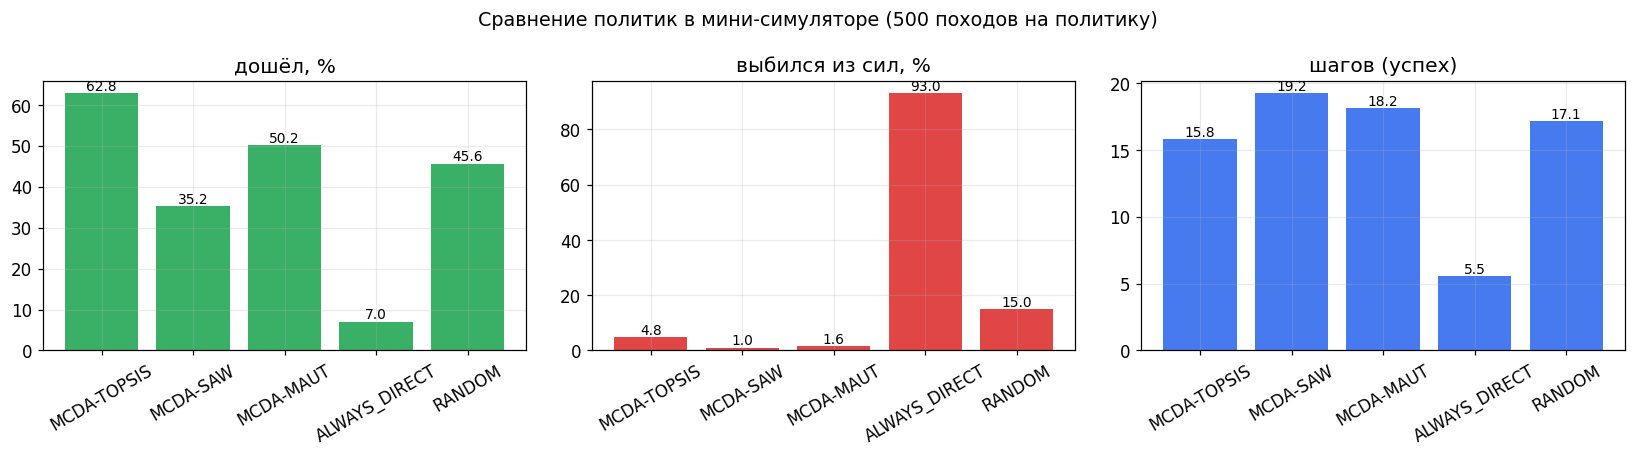

Лучшая политика по доле дошедших: MCDA-TOPSIS (62.8%)
Отрыв от случайной политики: +17.2 п.п.


In [26]:
# =============================================================================
# §13.1. ЭКСПЕРИМЕНТ: 500 ПОХОДОВ НА КАЖДУЮ ПОЛИТИКУ
# -----------------------------------------------------------------------------
# Все политики проходят ОДИН И ТОТ ЖЕ набор стартовых ситуаций (одно зерно
# seed=7) — иначе разница в результатах могла бы объясняться везением.
# =============================================================================

def evaluate(policy_fn, n_episodes: int = 500, seed: int = 7) -> Dict[str, float]:
    """Результаты политики на n_episodes случайных стартах."""
    rng_local = np.random.default_rng(seed)   # стартовые ситуации и погода
    np.random.seed(seed)                      # случайный выбор внутри политики
    results = []  # список результатов всех походов
    for _ in range(n_episodes):
        # rng_local.uniform(a, b) — случайное число из отрезка [a, b].
        # Эти диапазоны повторяет генератор стартов в Unity, поэтому
        # результаты ноутбука и игры сопоставимы.
        s0 = make_state(
            energy   = float(rng_local.uniform(0.45, 1.00)),
            dist     = float(rng_local.uniform(0.55, 0.95)),
            weather  = float(rng_local.uniform(0.15, 0.85)),
            supplies = float(rng_local.uniform(0.30, 0.90)),
            shelter  = float(rng_local.uniform(0.10, 0.90)),
        )
        results.append(run_episode(policy_fn, s0, rng=rng_local))
    # Только успешные походы — для средних «силы на финише» и «шагов».
    # r.success — обращение к полю записи EpisodeResult через точку.
    ok = [r for r in results if r.success]
    return {
        # np.mean от списка True/False — доля True; * 100 — в процентах.
        "дошёл, %":          100 * np.mean([r.success for r in results]),
        "выбился из сил, %": 100 * np.mean([r.exhausted for r in results]),
        "не успел, %":       100 * np.mean([(not r.success) and (not r.exhausted)
                                            for r in results]),
        "шагов (успех)":     float(np.mean([r.steps for r in ok])) if ok else np.nan,
        "силы на финише":    float(np.mean([r.final_energy for r in ok])) if ok else np.nan,
        "изучено":           float(np.mean([r.info_gained for r in results])),
    }


# Словарь {имя: результаты} -> таблица; .T — политики в строках.
bench = pd.DataFrame({name: evaluate(fn) for name, fn in POLICIES.items()}).T
display(bench.round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, col, color in zip(axes,
                          ["дошёл, %", "выбился из сил, %", "шагов (успех)"],
                          ["#16a34a", "#dc2626", "#2563eb"]):
    vals = bench[col]
    ax.bar(vals.index, vals.values, color=color, alpha=0.85)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)
    for i, v in enumerate(vals.values):
        if np.isfinite(v):          # np.isfinite — «это обычное число, не nan»
            ax.text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)
fig.suptitle("Сравнение политик в мини-симуляторе (500 походов на политику)",
             fontsize=12.5)
plt.tight_layout()
plt.show()

best = bench["дошёл, %"].idxmax()
# bench.loc[строка, столбец] — обращение к клетке по подписям.
print(f"Лучшая политика по доле дошедших: {best} ({bench.loc[best, 'дошёл, %']:.1f}%)")
print(f"Отрыв от случайной политики: "
      f"{bench.loc[best, 'дошёл, %'] - bench.loc['RANDOM', 'дошёл, %']:+.1f} п.п.")

### Что получилось

| Политика | Дошёл | Выбился из сил | Комментарий |
|---|--:|--:|---|
| MCDA-TOPSIS | 62,8 % | 4,8 % | лучшая: быстро и достаточно безопасно |
| MCDA-MAUT | 50,2 % | 1,6 % | осторожнее, чаще не успевает |
| RANDOM | 45,6 % | 15,0 % | нижняя граница |
| MCDA-SAW | 35,2 % | 1,0 % | почти не выбивается из сил, но слишком долго осматривается и не успевает до темноты |
| ALWAYS_DIRECT | 7,0 % | 93,0 % | спешка изматывает |

Два урока.

1. **Многокритериальность окупается.** «Всегда напрямик» оптимизирует один критерий
   (продвижение) и выбивается из сил в 93 % походов. TOPSIS, балансируя пять критериев, доходит
   до приюта в 63 %.
2. **Метод агрегирования виден в поведении.** SAW-путешественник, которого §11.1 назвал
   «любознательным», почти не выбивается из сил, но в 64 % походов не успевает: осмотры съедают время.
   Характер, заданный методом, напрямую сказывается на результате.

Эти цифры — **эталон** (baseline), с которым сравнивается обученный RL-агент в §14, и с
которым должны совпасть замеры в Unity (с точностью около 10 процентных пунктов).

---
# §14. Мост к Unity ML-Agents

## 14.1. Три учебные 2D-среды

| # | Среда | Что проверяет | Связь с разделами курса |
|---|---|---|---|
| 1 | **GridForage2D** — сетка 20×20, родники и ягодники, участки с непогодой, горный приют | базовый компромисс «риск — продвижение — запасы» | Разделы 2–3: Парето, SAW, TOPSIS |
| 2 | **CorridorRisk2D** — три тропы: короткая по открытому склону, длинная защищённая лесом, средняя мимо родника | явный выбор из трёх альтернатив, наблюдаемый глазом | Раздел 5: MAUT, отношение к риску |
| 3 | **SharedSprings2D** — два путешественника с разными «характерами» (разными весами) делят немногочисленные родники и узкие тропы | взаимодействие политик, равновесие | Раздел 6: теория игр |

Среда №2 — обязательный минимум: в ней траектория агента визуально читается как выбор
альтернативы, и студент видит, как изменение весов в ноутбуке меняет маршрут.

## 14.2. Два уровня работы

**Уровень A (базовый, обязателен для всех) — «MCDA управляет NPC».**
ML-Agents не нужен. `DecisionPolicy` читает `policy_unity.json`, `StrategyExecutor`
выполняет выбранный вариант действий. Требуется только Unity 2D + C#. Результат: NPC, поведение
которого полностью объяснимо через веса критериев.

**Уровень B (продвинутый) — «RL учится той же задаче».**
Агент ML-Agents обучается PPO в той же сцене. MCDA-политика используется трояко:

1. **Baseline** — метрики MCDA-политики служат порогом качества для RL.
2. **Демонстрации для имитации** — уровень A записывается в `.demo`, и в конфиг
   добавляется `behavioral_cloning` / GAIL: обучение стартует не с нуля, а с разумного
   поведения. Это радикально ускоряет сходимость и наглядно показывает ценность
   экспертных знаний.
3. **Формирование награды (reward shaping)** — компоненты награды берутся прямо из
   критериев MCDA с теми же весами: $r = \sum_j w_j \cdot \Delta g_j$. Так студент
   видит, что функция награды в RL и свёртка критериев в MCDA — это одна и та же
   математическая конструкция, применённая в разных местах.

## 14.3. Спецификация агента ML-Agents

**Observation (vector, 16 значений)** — расширенный вектор состояния:

```
[0] energy01        [5] time_used01       [8]  velocity.x
[1] dist01          [6] hut_dir.x         [9]  velocity.y
[2] weather01       [7] hut_dir.y         [10…15] текущий вариант действий, one-hot (6 чисел)
[3] supplies01
[4] shelter01
```

Итого $5+1+2+2+6=16$ — ровно столько указывается в Behavior Parameters → Space Size.

Плюс `RayPerceptionSensor2D` (8 лучей, 3 тега: `BadWeather` — участок непогоды, `Supply` — родник или ягодник, `Shelter` — укрытие).

**Action space.** Принципиальный выбор — **дискретный, размерности 6: индекс стратегии**,
а не низкоуровневое управление. Тогда RL решает ровно ту же задачу, что и MCDA (выбор
альтернативы), и сравнение корректно. Низкоуровневое исполнение остаётся в
`StrategyExecutor` и одинаково у обоих агентов.

```csharp
public override void CollectObservations(VectorSensor sensor) {
    sensor.AddObservation(state.Energy01);
    sensor.AddObservation(state.Dist01);
    sensor.AddObservation(state.Weather01);
    sensor.AddObservation(state.Supplies01);
    sensor.AddObservation(state.Shelter01);
    sensor.AddObservation(state.TimeUsed01);
    sensor.AddObservation(state.HutDir);            // Vector2 → 2 значения: направление на приют
    sensor.AddObservation(rb.linearVelocity / maxSpeed);
    sensor.AddOneHotObservation(currentStrategyIndex, 6);
}

public override void OnActionReceived(ActionBuffers actions) {
    int idx = actions.DiscreteActions[0];           // 0..5 — индекс стратегии
    executor.SetStrategy(strategies[idx]);
    AddReward(ShapedReward());                      // см. ниже
}

// Эвристика = MCDA-политика: даёт и ручную проверку, и запись демонстраций
public override void Heuristic(in ActionBuffers actionsOut) {
    string a = policy.Decide(state.Energy01, state.Dist01, state.Weather01,
                             state.Supplies01, state.Shelter01, out _);
    actionsOut.DiscreteActions.Array[0] = Array.IndexOf(strategies, a);
}
```

> `Heuristic()`, возвращающий решение MCDA, — ключевой приём всей связки. Он позволяет
> одним переключателем `Behavior Type: Heuristic Only / Default` сравнить две политики
> в одной и той же сцене и записать демонстрации для имитационного обучения.

**Награда, согласованная с критериями MCDA:**

```csharp
float ShapedReward() {
    float r = 0f;
    r += W_PROGRESS * (prevDist - state.Dist01);        // продвижение
    r -= W_RISK     * energyLostThisStep;               // риск неприятностей
    r -= W_TIME     * (1f / maxSteps);                  // время
    r -= W_COST     * suppliesSpentThisStep;            // расход запасов
    r += W_INFO     * newCellsExplored / totalCells;    // знание местности
    return r;
}
// Терминальные: +1.0 дошёл до приюта, −1.0 выбился из сил, −0.5 стемнело (таймаут)
```

In [27]:
# =============================================================================
# §14. КОНФИГУРАЦИЯ ДЛЯ ОБУЧЕНИЯ С ПОДКРЕПЛЕНИЕМ (Unity ML-Agents)
# -----------------------------------------------------------------------------
# Генерируем два файла:
#   decision_agent.yaml  — настройки алгоритма PPO для команды mlagents-learn;
#   reward_weights.json  — веса критериев, из которых C#-код собирает награду.
# Смысл: награда RL строится из ТЕХ ЖЕ пяти критериев и ТЕХ ЖЕ весов, что и
# свёртка MCDA, — поэтому две политики решают одну и ту же задачу.
# =============================================================================
w_export = W_BASE.round(4)      # веса с 4 знаками — для файла JSON

# Текст YAML собираем f-строкой в ТРОЙНЫХ кавычках """...""": такая строка
# может занимать много строк. {OUT_DIR} внутри подставится автоматически.
# Параметры PPO стандартные для небольшой задачи; их смысл — в §14.

yaml_cfg = f"""# {OUT_DIR}/decision_agent.yaml  — конфигурация ML-Agents (mlagents-learn)
behaviors:
  DecisionAgent:
    trainer_type: ppo
    hyperparameters:
      batch_size: 512
      buffer_size: 10240
      learning_rate: 3.0e-4
      beta: 5.0e-3
      epsilon: 0.2
      lambd: 0.95
      num_epoch: 3
      learning_rate_schedule: linear
    network_settings:
      normalize: true
      hidden_units: 256
      num_layers: 2
      vis_encode_type: simple
    reward_signals:
      extrinsic:
        gamma: 0.99
        strength: 1.0
      # --- Имитация MCDA-политики: раскомментировать на уровне B, шаг 2 ---
      # gail:
      #   strength: 0.3
      #   gamma: 0.99
      #   demo_path: Assets/Demos/MCDA_TOPSIS.demo
    # behavioral_cloning:
    #   demo_path: Assets/Demos/MCDA_TOPSIS.demo
    #   strength: 0.5
    #   steps: 50000
    keep_checkpoints: 5
    max_steps: 1500000
    time_horizon: 128
    summary_freq: 10000

environment_parameters:
  # Curriculum (учебный план): начинаем с хорошей погоды и постепенно её ухудшаем
  weather_level:
    curriculum:
      - name: Easy
        completion_criteria:
          measure: reward
          behavior: DecisionAgent
          signal_smoothing: true
          min_lesson_length: 100
          threshold: 0.5
        value: 0.2
      - name: Medium
        completion_criteria:
          measure: reward
          behavior: DecisionAgent
          signal_smoothing: true
          min_lesson_length: 100
          threshold: 0.7
        value: 0.55
      - name: Hard
        value: 0.85
"""

# Записываем YAML в ту же папку, что и политику. os.path.join склеивает
# имя папки и имя файла с правильным разделителем для любой ОС.
yaml_path = os.path.join(OUT_DIR, "decision_agent.yaml")
with open(yaml_path, "w", encoding="utf-8") as f:
    f.write(yaml_cfg)

# Веса критериев отдельным файлом — чтобы C# считал награду теми же весами,
# что и MCDA. Меняете W_BASE — меняется и награда RL-агента.
weights_path = os.path.join(OUT_DIR, "reward_weights.json")
with open(weights_path, "w", encoding="utf-8") as f:
    # json.dump(словарь, файл) записывает словарь в файл в формате JSON.
    json.dump({"source": "MCDA base weights (AHP/expert)",
               "weights": {c: float(w_export[c]) for c in CRITERIA},
               "note": "Те же веса используются в свёртке MCDA и в shaped reward ML-Agents"},
              f, ensure_ascii=False, indent=1)

print("Созданные для Unity файлы:")
# os.listdir — список файлов папки; sorted — по алфавиту.
for f_ in sorted(os.listdir(OUT_DIR)):
    print(f"  {f_:24s} {os.path.getsize(os.path.join(OUT_DIR, f_))/1024:8.1f} КБ")
print("\nЗапуск обучения:\n  mlagents-learn unity_export/decision_agent.yaml --run-id=mcda_vs_ppo_01")

Созданные для Unity файлы:
  decision_agent.yaml           1.6 КБ
  policy.json                  52.8 КБ
  policy_table.csv             42.0 КБ
  policy_unity.json            54.4 КБ
  reward_weights.json           0.3 КБ

Запуск обучения:
  mlagents-learn unity_export/decision_agent.yaml --run-id=mcda_vs_ppo_01


## 14.4. Протокол сравнения MCDA-политики и обученного RL-агента

Сравнение проводится на **одном и том же наборе стартовых состояний** (фиксированные
сиды), по одинаковым метрикам:

| Метрика | MCDA | PPO | Комментарий |
|---|---|---|---|
| Доля успешных эпизодов | из §13 | замер | главный показатель |
| Средняя длина успешного эпизода | из §13 | замер | эффективность |
| Доля «выбился из сил» | из §13 | замер | безопасность |
| Расход запасов | из §13 | замер | экономичность |
| Разнообразие стратегий (энтропия выбора) | считаем | считаем | не выродилась ли политика |
| **Объяснимость** | полная | нулевая | обсуждается в выводах |
| Стоимость получения | минуты | часы GPU | обсуждается в выводах |

Ожидаемый результат, который и является учебной кульминацией: **PPO обгоняет MCDA по
успешности на 5–15%, но проигрывает по объяснимости и стоимости, а стартовав с
демонстраций MCDA — сходится в 3–5 раз быстрее**. Вывод, который должен сформулировать
студент: экспертная модель предпочтений и обучение с подкреплением не конкуренты,
а взаимодополняющие инструменты.

---
# §15. Итоги

## 15.1. Сводная таблица: формула ↔ код

Шпаргалка ко всем методам ноутбука. Слева — полная формула, справа — строка кода,
которая её реализует.

| Метод | Математика | Python |
|---|---|---|
| Нормализация min–max (2.1) | $r_{ij}=\dfrac{x_{ij}-x_j^{\min}}{x_j^{\max}-x_j^{\min}}$ | `(x - lo) / (hi - lo)` |
| Нормализация по лучшему (2.2) | $r_{ij}=x_{ij}/x_j^{\max}$, для издержки $x_j^{\min}/x_{ij}$ | `x / hi`, `lo / x` |
| Доминирование (2.4) | $a\succ b\iff r(a)\ge r(b)\;\forall j,\;\exists k: r_k(a)\gt r_k(b)$ | `np.all(u >= v) and np.any(u > v)` |
| SAW (3.1) | $F(a_i)=\sum_j w_j r_{ij}$ | `(R * w[R.columns]).sum(axis=1)` |
| WPM (3.2) | $F(a_i)=\prod_j r_{ij}^{w_j}=\exp\sum_j w_j\ln r_{ij}$ | `np.exp((np.log(R) * w[R.columns]).sum(axis=1))` |
| AHP (4.1) | $Aw=\lambda_{\max}w$ | `np.linalg.eig(P)`, затем `v / v.sum()` |
| Согласованность (4.4) | $CR=\dfrac{\lambda_{\max}-m}{(m-1)\,RI}$ | `(lam_max - m) / (m - 1) / RI_TABLE[m]` |
| TOPSIS (5.4)–(5.5) | $C_i=\dfrac{d_i^-}{d_i^++d_i^-}$, $d_i^\pm=\lVert v_i-A^\pm\rVert$ | `d_minus / (d_plus + d_minus)` |
| Полезность (6.3) | $u(x')=\dfrac{1-e^{-cx'}}{1-e^{-c}}$ | `(1 - np.exp(-c * x)) / (1 - np.exp(-c))` |
| MAUT (6.4) | $U(a_i)=\sum_j k_j u_j(x'_{ij})$ | `(U * w[U.columns]).sum(axis=1)` |
| VIKOR (7.2)–(7.3) | $S_i=\sum_j w_jD_{ij}$, $R_i=\max_j w_jD_{ij}$ | `WD.sum(axis=1)`, `WD.max(axis=1)` |
| VIKOR (7.4) | $Q_i=\nu\frac{S_i-S^*}{S^--S^*}+(1-\nu)\frac{R_i-R^*}{R^--R^*}$ | `nu * (S - S_s) / (S_m - S_s) + (1 - nu) * (Rg - R_s) / (R_m - R_s)` |
| ELECTRE (8.1) | $c(a,b)=\sum_{j:\,r_{aj}\ge r_{bj}} w_j$ | `w[R.columns][better.values].sum()` |
| ELECTRE (8.3) | $aSb\iff c(a,b)\ge\hat c,\;d(a,b)\le\hat d$ | `C.loc[a, b] >= c_thr and D.loc[a, b] <= d_thr` |
| Спирмен (9.1) | $\rho$ — корреляция рангов | `spearman(a, b)` |
| Адаптивные веса (1.1) | $w_j(s)=\dfrac{w_j^0 m_j(s)}{\sum_k w_k^0 m_k(s)}$ | `w0 * m[w0.index]`, затем `w / w.sum()` |
| Политика | $\pi(s)=\arg\max_a F(X(s),w(s))_a$ | `method(X, w).sort_values(ascending=False).index[0]` |

## 15.2. Глоссарий

| Термин | Значение |
|---|---|
| **ЛПР** | лицо, принимающее решение; чьи предпочтения учитываются |
| **Альтернатива** | вариант, из которого выбирают |
| **Критерий** | признак, по которому сравнивают альтернативы; бывает выгодой (max) и издержкой (min) |
| **Матрица решений** | таблица оценок «альтернативы × критерии» |
| **Нормализация** | перевод критериев в единую безразмерную шкалу с одним направлением |
| **Доминирование** | $a$ не хуже $b$ по всем критериям и строго лучше хотя бы по одному |
| **Множество Парето** | альтернативы, которых никто не доминирует |
| **Вес критерия** | относительная важность критерия; веса в сумме дают 1 |
| **Компенсация** | возможность возместить недостаток по одному критерию достоинством по другому |
| **Матрица парных сравнений** | суждения ЛПР «во сколько раз $i$ важнее $j$» (AHP) |
| **Отношение согласованности $CR$** | мера противоречивости суждений ЛПР; приемлемо $CR\lt 0{,}1$ |
| **Идеальная точка** | воображаемая альтернатива, лучшая по всем критериям сразу (TOPSIS) |
| **Функция полезности** | субъективная ценность значения критерия для ЛПР (MAUT) |
| **Эквивалент определённости** | гарантированная сумма, равноценная для ЛПР лотерее |
| **Групповая полезность / сожаление** | суммарный и наибольший недобор до лучших значений (VIKOR) |
| **Отношение превосходства** | «$a$ не хуже $b$» при достаточном согласии и без вето (ELECTRE) |
| **Анализ чувствительности** | проверка, насколько решение устойчиво к изменению весов |
| **Политика** | правило «состояние → действие» |
| **Запас превосходства (margin)** | разница баллов лидера и второй альтернативы |

## 15.3. Задания

### Учебные примеры

Все учебные примеры §2–§10 решены вручную и проверены кодом в ноутбуке-спутнике
`MCDA_Methods_Examples.ipynb`. Там же — шесть упражнений на их вариации.

### Основные задания (уровень A)

1. **Собственный профиль ЛПР.** Замените суждения `prefs_careful` в §4 своими, добейтесь
   $CR\lt 0{,}10$, получите веса. Опишите словами, какой «характер» NPC вы задали.
2. **Постройте политику** своим профилем: `build_policy("TOPSIS", w_ahp)` в §11. Сравните
   карту с эталонной. Найдите минимум три состояния, где ваш агент ведёт себя иначе,
   и объясните почему.
3. **Анализ чувствительности** (§10): найдите критический вес, при котором ваш агент
   перестаёт выбирать `DIRECT` вблизи цели.
4. **Перенос в Unity**: загрузите свой `policy_unity.json` в сцену `CorridorRisk2D`,
   запишите видео 60 с, где видна смена стратегий.
5. **Отчёт** с таблицей метрик из §13 для вашей политики против `ALWAYS_DIRECT`.

### Дополнительные задания (уровень B)

6. Реализуйте ELECTRE III с псевдокритериями (пороги безразличия и предпочтения) и сравните
   полученную политику с TOPSIS.
7. Запишите `.demo` из эвристики MCDA и обучите PPO с `behavioral_cloning`. Постройте график:
   сходимость с демонстрациями против сходимости с нуля.
8. **SharedSprings2D**: запустите двух путешественников с разными профилями AHP. Есть ли пара профилей,
   устойчивая по Нэшу? Свяжите с материалом раздела по теории игр.
9. Замените дискретизацию 3×3×3×3×3 на нечёткую (функции принадлежности вместо уровней)
   и сравните плавность поведения NPC.

## 15.4. Вопросы для самопроверки

Сначала ответьте сами, затем раскройте ответ.

<details>
<summary><b>1. Чем многокритериальная задача принципиально отличается от однокритериальной?</b></summary>

В однокритериальной задаче «лучше» определено однозначно — больше (или меньше) значение
целевой функции. В многокритериальной критерии противоречат друг другу, и без информации
о предпочтениях ЛПР (весов, функций полезности, порогов) выбрать единственный ответ нельзя.
Математика позволяет лишь отбросить доминируемые варианты (множество Парето).
</details>

<details>
<summary><b>2. Почему перед SAW обязательна нормализация?</b></summary>

Критерии измерены в разных единицах и имеют разные направления. Без нормализации сумма
«рублей и метров» бессмысленна, а результат зависит от выбора единиц. Нормализация делает
оценки безразмерными и разворачивает издержки так, чтобы везде «больше — лучше».
</details>

<details>
<summary><b>3. Почему перед WPM нельзя использовать нормализацию min–max?</b></summary>

Min–max превращает худшее значение в 0, а ноль в произведении обнуляет всю оценку
альтернативы. Для WPM нужна нормализация по лучшему значению (2.2), у которой нулей нет.
</details>

<details>
<summary><b>4. Почему WPM выбирает более «ровные» альтернативы, чем SAW?</b></summary>

WPM — это SAW от логарифмов. Логарифм растягивает шкалу около нуля, поэтому провал по одному
критерию стоит в WPM гораздо дороже. Пример: $(1;\,0{,}25)$ против $(0{,}6;\,0{,}6)$ при равных весах —
SAW даёт $0{,}625$ и $0{,}6$, WPM — $0{,}5$ и $0{,}6$.
</details>

<details>
<summary><b>5. Что означает CR = 0,25 в AHP и что с этим делать?</b></summary>

Суждения противоречивы: их несогласованность составляет 25 % от несогласованности случайно
заполненной матрицы, что выше допустимых 10 %. Веса, полученные из такой матрицы, использовать
нельзя. Нужно найти тройку суждений, нарушающую правило $a_{ij}a_{jk}=a_{ik}$ сильнее всего,
и попросить ЛПР её пересмотреть.
</details>

<details>
<summary><b>6. Зачем TOPSIS нужно расстояние до антиидеала, если есть расстояние до идеала?</b></summary>

Две альтернативы могут быть одинаково далеки от идеала, но одна из них при этом близка
к худшему варианту (у неё провал), а другая — нет. В примере 5.1 ноутбука-спутника ближе всех к идеалу
был П1, но победил П3, который дальше всех от антиидеала. В задаче путешественника тот же
эффект: RETURN дальше WAIT от идеала, но второй по TOPSIS благодаря наибольшему $d^-$ (§5).
</details>

<details>
<summary><b>7. Что показывает вогнутая функция полезности?</b></summary>

Неприятие риска: каждая следующая единица критерия ценится меньше предыдущей, и ЛПР
предпочитает гарантированный средний результат лотерее с тем же ожидаемым значением.
В примере 6.1 ноутбука-спутника лотерея со средним 105 тыс. оказалась для ЛПР равноценна
гарантированным 89,5 тыс.
</details>

<details>
<summary><b>8. Что означает, что в VIKOR нарушено условие C1?</b></summary>

Лидер по $Q$ опережает второе место меньше чем на $DQ=1/(n-1)$ — преимущество незначимо.
Тогда VIKOR выдаёт не одну альтернативу, а компромиссное множество. Для игрового агента это
сигнал: в таком состоянии разумно выбирать между несколькими стратегиями случайно.
</details>

<details>
<summary><b>9. Почему ELECTRE I может оставить альтернативы несравнимыми, и хорошо ли это?</b></summary>

Отношение «$a$ не хуже $b$» принимается только при достаточном согласии и без вето. Если
ни одно из двух условий не выполнено в пользу ни одной из альтернатив, они несравнимы.
Это честное признание того, что данных для сравнения недостаточно, — в отличие от SAW,
который всегда выдаст ответ, даже если он держится на третьем знаке после запятой.
</details>

<details>
<summary><b>10. В каком смысле функция награды в обучении с подкреплением — свёртка критериев?</b></summary>

Награда агента в §14 собирается как $r=\sum_j w_j\,\Delta g_j$ — взвешенная сумма приращений
тех же пяти критериев с теми же весами. Это SAW, применённый не к оценкам альтернатив,
а к изменениям состояния. Аналогия ломается там, где RL учитывает будущее: агент максимизирует
сумму наград за много шагов, а MCDA выбирает лучшее действие «здесь и сейчас».
</details>

### Вопросы для защиты

* Почему WPM даёт более осторожного агента, чем SAW? Покажите на конкретной матрице.
* Что означает непустое компромиссное множество VIKOR применительно к поведению NPC?
* Почему SAW-агент в §13 почти не выбивается из сил, но так редко доходит до приюта?
* Какой метод вы бы выбрали для коммерческой игры и почему — с учётом того, что баланс
  придётся править после релиза?

---
## Приложение А. Состав выгрузки

```
unity_export/
├── policy.json           — полная политика (словарь), для отчётов и проверки
├── policy_unity.json     — та же политика в формате JsonUtility, для Unity
├── policy_table.csv      — таблица политики для приложения к отчёту
├── decision_agent.yaml   — конфигурация ML-Agents (PPO + curriculum + GAIL)
└── reward_weights.json   — веса критериев для награды в C#
```

**Как использовать в Unity** — подробно в методичке «Агент, принимающий решения», Часть 3:

1. Положить `policy_unity.json` в `Assets/Data/` — Unity импортирует его как `TextAsset`.
2. На агенте в компоненте `DecisionPolicy` указать этот файл в поле `Policy Asset`.
3. Запустить сцену: над NPC появится подпись текущей стратегии.

## Приложение Б. Литература

**Учебники курса:**

* Лиманова Н. И. Математические и инструментальные методы поддержки принятия решений:
  учебное пособие (папка курса «3. ЛИТЕРАТУРА»).
* Граецкая О. В. Математические и инструментальные методы принятия решений
  (папка курса «3. ЛИТЕРАТУРА»).

**Первоисточники методов:**

* Saaty T. L. *The Analytic Hierarchy Process.* — New York: McGraw-Hill, 1980. — AHP.
* Hwang C.-L., Yoon K. *Multiple Attribute Decision Making: Methods and Applications.* —
  Berlin: Springer, 1981. — TOPSIS, SAW.
* Keeney R. L., Raiffa H. *Decisions with Multiple Objectives: Preferences and Value
  Tradeoffs.* — New York: Wiley, 1976. — MAUT.
* Roy B. Classement et choix en présence de points de vue multiples (la méthode ELECTRE) //
  RIRO. — 1968. — № 8. — ELECTRE.
* Opricovic S., Tzeng G.-H. Compromise solution by MCDM methods: A comparative analysis
  of VIKOR and TOPSIS // European Journal of Operational Research. — 2004. — Vol. 156. — VIKOR.
* Triantaphyllou E. *Multi-Criteria Decision Making Methods: A Comparative Study.* —
  Dordrecht: Kluwer, 2000. — сравнение методов, WPM.

---

*Ноутбук подготовлен для курса «Математические и инструментальные методы поддержки
принятия решений». Все методы реализованы «с нуля» на NumPy и pandas — внешних
MCDA-библиотек не требуется, поэтому каждую формулу можно разобрать на занятии.*